In [1]:
import warnings

import ast
import pandas as pd
import numpy as np
import math
from numpy.polynomial.polynomial import polyfit

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

warnings.filterwarnings('ignore')

In [2]:
cyr = ['а','б','в','г','д','е','ё','ж','з','и','й','к','л','м','н','о','п','р','с','т','у','ф','х','ц','ч','ш','щ','ъ','ы','ь','э','ю','я','ґ','є','ї','ђ','љ','њ','ћ','џ', 'ў','ъ']
lat = ['a','b','v','g','d','e','jo','zh','z','i','j','k','l','m','n','o','p','r','s','t','u','f','h','ts','ch','sh','sczs','','y','','e','ju','ja','g','e','j','dzh','l','n','ch','dzh', 'w','o']
lat2 = ['ch','cz','rz','sz', 'a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','qu','r','s','t','u','v','w','x', 'y','z','ą', 'ć','ę', 'ł','ń','ó','ś','ź','ż','á','č','ď','é','ě','í','ň','ř', 'š','ť','ú','ů','ý','ž','ä','ľ','ĺ', 'ô', 'ŕ','è']
cyr2 = ['х', 'ч', 'ж', 'ш',  'а','б','ц','д','е','ф','г','х','и','й','к','л','м','н','о','п','кв','р','с','т','у','в','в','кс','ы','з','ом','ч','ен','л','н','у','ш','ж','ж','а','ч','д','э','е','и','н','рж','ш','т','у','у','и','ж','э','л','лл','уо','рр','э']
langss = ['-', 'c', 'c', 'c', 'l', 'l', 'l', 'c', 'l']

# Transliterates text into proper script: 'c' - Cyrillic into Latinic, 'l' - conversely.
def transliterate(sss, l_kind):
  try:
    sss2 = sss.lower()

    if l_kind == 'c':
        l_from, l_to = cyr, lat
    elif l_kind == 'l':
        l_from, l_to = lat2, cyr2
    else:
        return ""
    for c, l in zip(l_from, l_to):
        try:
            sss2 = sss2.replace(c, l)
        except:
            pass
  except:
    pass
  return sss2

In [4]:
df_all_n = pd.DataFrame()  # "настоящие" когнаты по всем языкам 
df_all1_n = pd.DataFrame()  # "частичные" когнаты (когнаты синонимов правильных ответов) по всем языкам
df_all2_n = pd.DataFrame()  # "настоящие" + "частичные" когнаты по всем языкам
df_both_n = pd.DataFrame()  # для одного языка
columns = [
    'pair', 'ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn', 'postfix_position', 'different_agreement',
    'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 'SUFF1', 'SUFF2', 'SUFF3',
    'END', 'POSTFIX', 'explained_mistakes'
]
df_all_langs_n = pd.DataFrame(columns=columns)  # "настоящие" когнаты по всем языкам + информация, к какому языку относится когнат
df_all_langs1_n = pd.DataFrame(columns=columns)  # "частичные" когнаты по всем языкам + информация, к какому языку относится когнат
df_all_langs2_n = pd.DataFrame(columns=columns)  # "настоящие" + "частичные" когнаты по всем языкам + информация, к какому языку относится когнат

In [5]:
# Функция для добавления информации о языке когната:

def add_rows(source_df, target_df, column_to_fill):
    new_columns = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
    rows_to_add = source_df.copy()
    for col in new_columns:
        rows_to_add[col] = 0.0
    if column_to_fill and column_to_fill in new_columns:
        rows_to_add[column_to_fill] = 1.0
    rows_to_add = rows_to_add[target_df.columns]
    target_df = pd.concat([target_df, rows_to_add], ignore_index=True)
    return target_df

In [6]:
def normalize_levenshtein_in_dataframe(df, translit=False,
                                       distance_columns=['PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX'],
                                       clean_soft_sign=True):
    df = df.copy()
    
    def clean_word(word):
        return str(word).replace('ь', '')
    
    def get_max_length(pair_string):
        words = ast.literal_eval(pair_string)[1:]
        word1, word2 = words[0], words[1]
        if clean_soft_sign:
            word1 = clean_word(word1)
            word2 = clean_word(word2)

        return max(len(word1), len(word2))
    
    word_lengths = df['pair'].apply(get_max_length)
    
    for col in distance_columns:
        df[col] = df.apply(lambda row: row[col] / word_lengths[row.name], axis=1)
    
    return df

In [7]:
count_n = 0

In [8]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

In [9]:
def regression_results(file, language, f_type='b', normalize=True):
    
    if isinstance(file, str):
        df = pd.read_csv(file)
    else:
        df = file.copy()
    
    if normalize and f_type != 'b':
        if language in ['ukr', 'bel', 'bg', 'sb']:
            df = normalize_levenshtein_in_dataframe(df)
        else:
            df = normalize_levenshtein_in_dataframe(df, True)
            
    global df_both_n, count_n
    if normalize:   
        if count_n < 2:
            df_both_n = pd.concat([df_both_n, df], ignore_index=True)
            count_n += 1
        elif count_n == 2:
            df_both_n = pd.DataFrame()
            count_n = 0
            
    if normalize:
        global df_all_n, df_all1_n, df_all2_n, df_all_langs_n, df_all_langs1_n, df_all_langs2_n
        if f_type == 't':
            df_all_n = pd.concat([df_all_n, df], ignore_index=True)
            df_all_langs_n = add_rows(df, df_all_langs_n, column_to_fill=language)
        elif f_type == 'p':
            df_all1_n = pd.concat([df_all1_n, df], ignore_index=True)
            df_all_langs1_n = add_rows(df, df_all_langs1_n, column_to_fill=language)
        else:
            df_all2_n = pd.concat([df_all2_n, df], ignore_index=True)
            df_all_langs2_n = add_rows(df, df_all_langs2_n, column_to_fill=language)
    
    morpheme_colns = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']
    
    global morpheme_cols
    zero_variance_cols = [col for col in morpheme_colns if df[col].std() == 0]
    if zero_variance_cols:
        df = df.drop(columns=zero_variance_cols)
        morpheme_cols = [col for col in morpheme_colns if col not in zero_variance_cols]   
    
    if 'pair' in df.columns:
        df1 = df.drop('pair', axis=1)
        
    train, test = train_test_split(df1, test_size=0.2, random_state=42)

    train_indices = train.index
    test_indices = test.index
    
    X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
        train['explained_mistakes'].to_numpy()
    
    X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
        test['explained_mistakes'].to_numpy()

    scaler = StandardScaler()
    x_train = scaler.fit_transform(X_train)
    x_test = scaler.transform(X_test)
    
    reg = LinearRegression()
    reg.fit(x_train, y_train)
    
    pred = reg.predict(x_test)

    dff = df.copy()
    dff = dff.drop(test_indices)
    
    df['pred'] = np.nan
    df.loc[test_indices, 'pred'] = pred
    
    df = df.drop(train_indices)
    
    
    return r2_score(y_test, pred), mean_absolute_error(y_test, pred), df, reg.coef_, dff

## Украинский

### True norm

In [13]:
results = regression_results('for_regression/true/ukr_true.csv', 'ukr', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.796296627346426, 0.5673271051614157)

In [14]:
df.to_csv(
    'linreg_ana/true_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

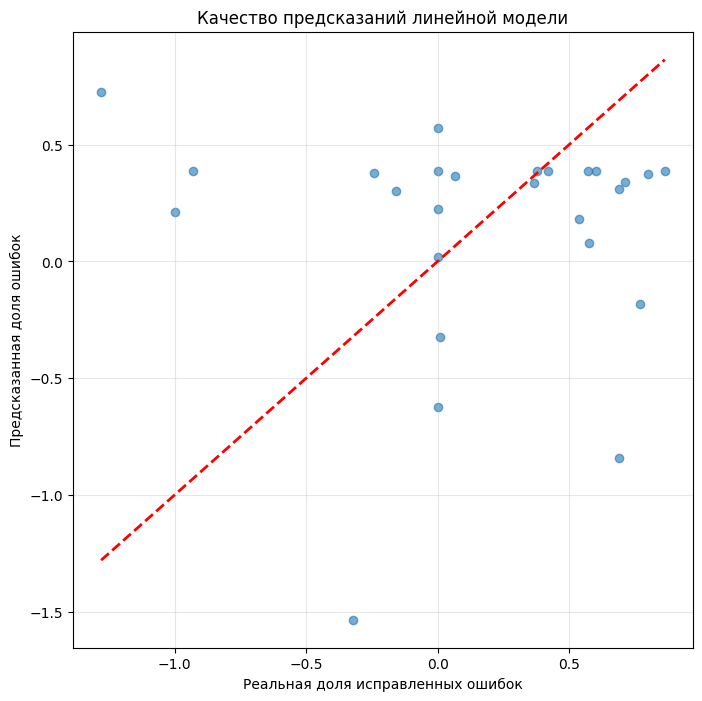

In [15]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

PREF1: -0.317
ROOT1: -0.045
ROOT2: -0.4
LINK: -0.4
SUFF1: -0.084
SUFF2: -0.134
SUFF3: 0.014
END: -0.019
POSTFIX: 0.047


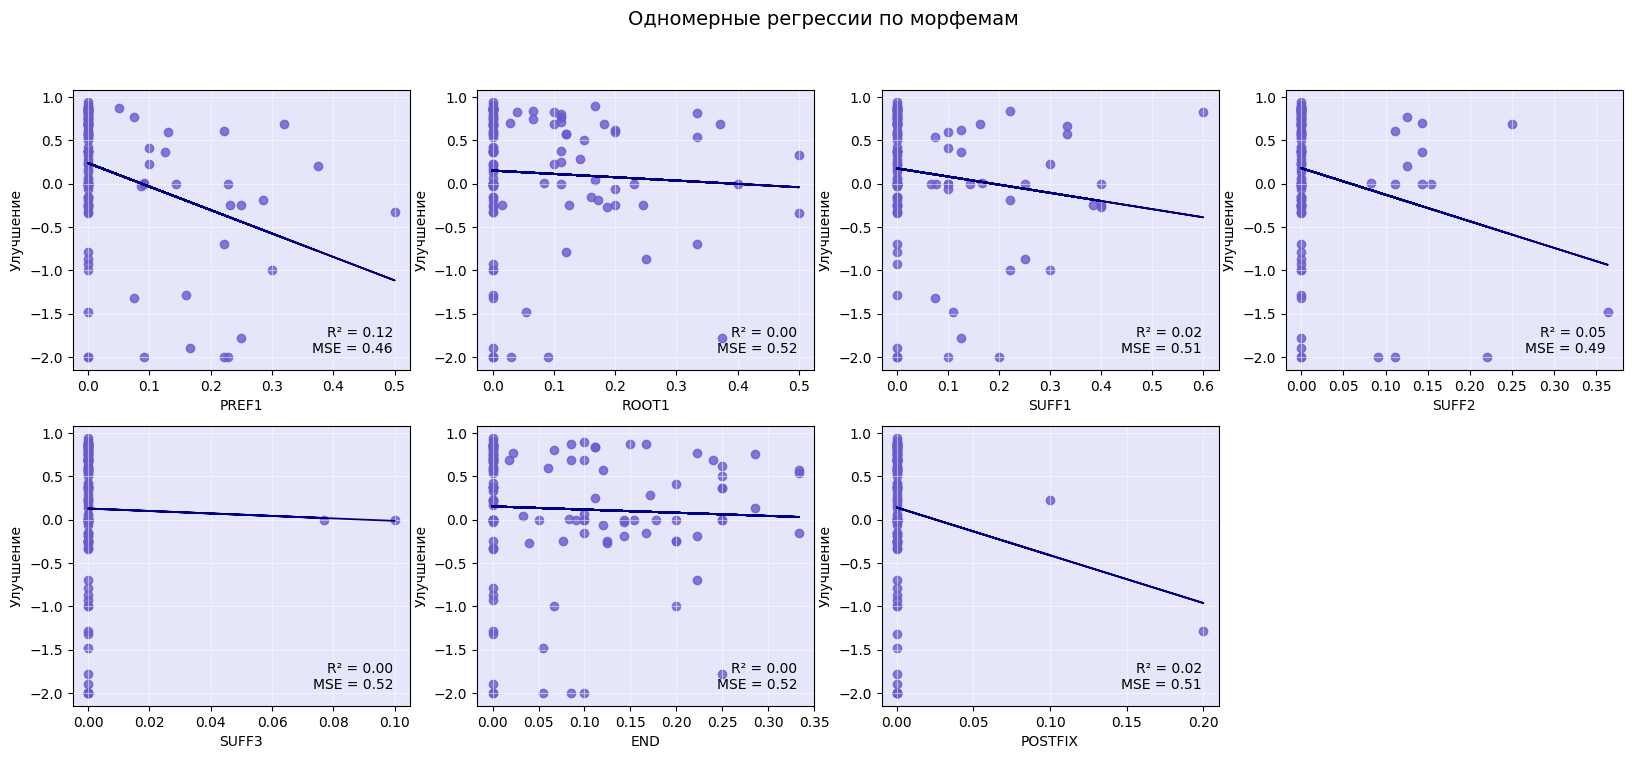

In [17]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()

good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [21]:
results = regression_results('for_regression/part/ukr_part1.csv', 'ukr', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.03074032336449406, 0.6626575072698113)

In [22]:
df.to_csv(
    'linreg_ana/part_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

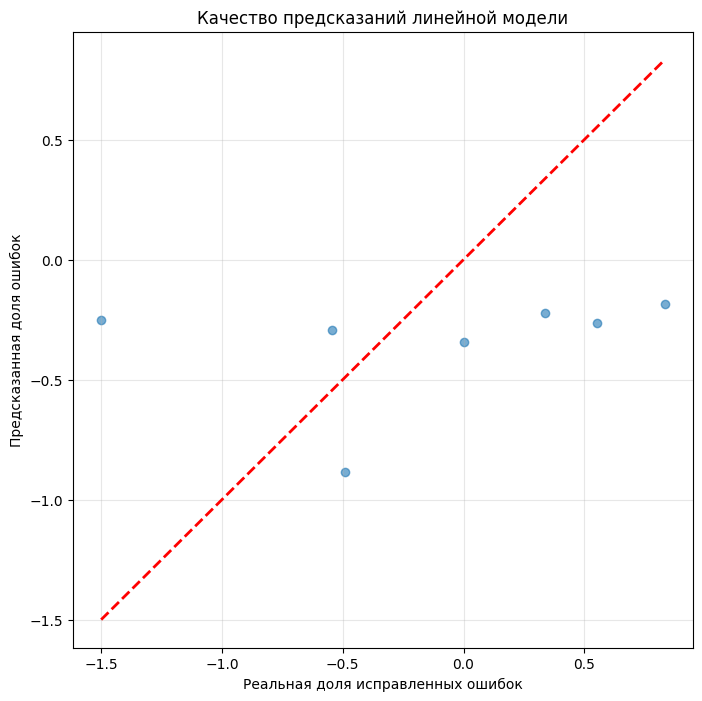

In [23]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: 0.137
PREF1: -0.295
PREF2: -0.045
ROOT1: 0.048
LINK: -0.844
SUFF1: -0.019
SUFF2: 0.077
END: -0.036
POSTFIX: 0.0


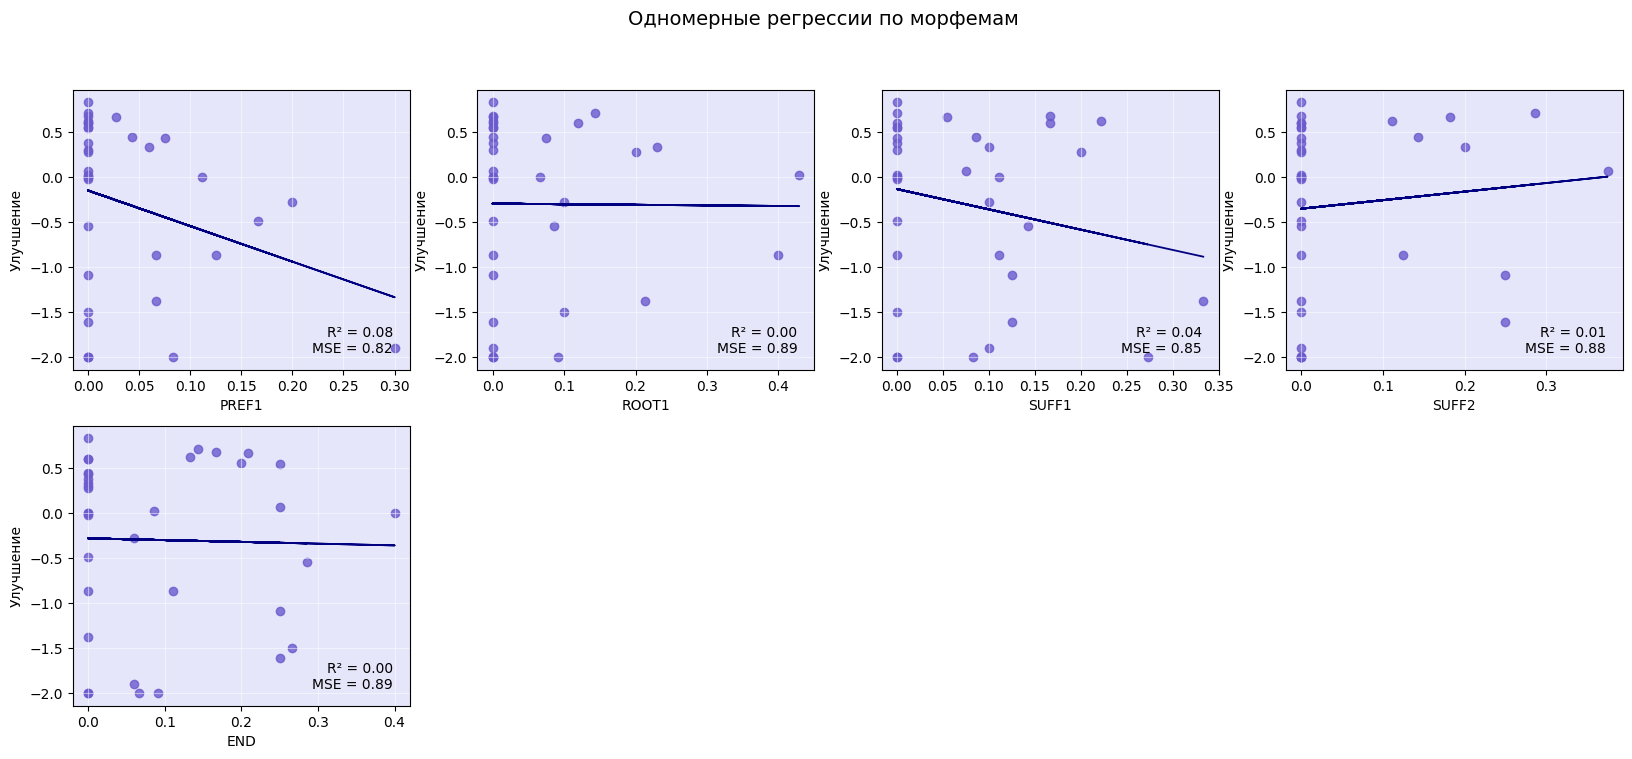

In [25]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [29]:
results = regression_results(df_both_n, 'ukr', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(0.012885200647047013, 0.5794483734257878)

In [30]:
df.to_csv(
    'linreg_ana/both_norm/ukr_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

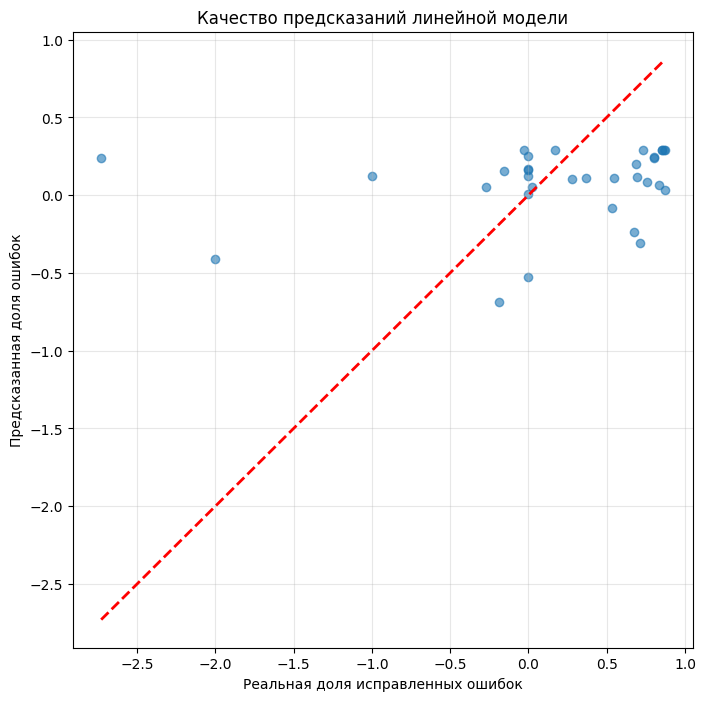

In [31]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: 0.032
PREF1: -0.254
PREF2: -0.054
ROOT1: -0.044
ROOT2: -0.243
LINK: -0.63
SUFF1: -0.057
SUFF2: -0.109
SUFF3: -0.01
END: -0.067
POSTFIX: -0.041


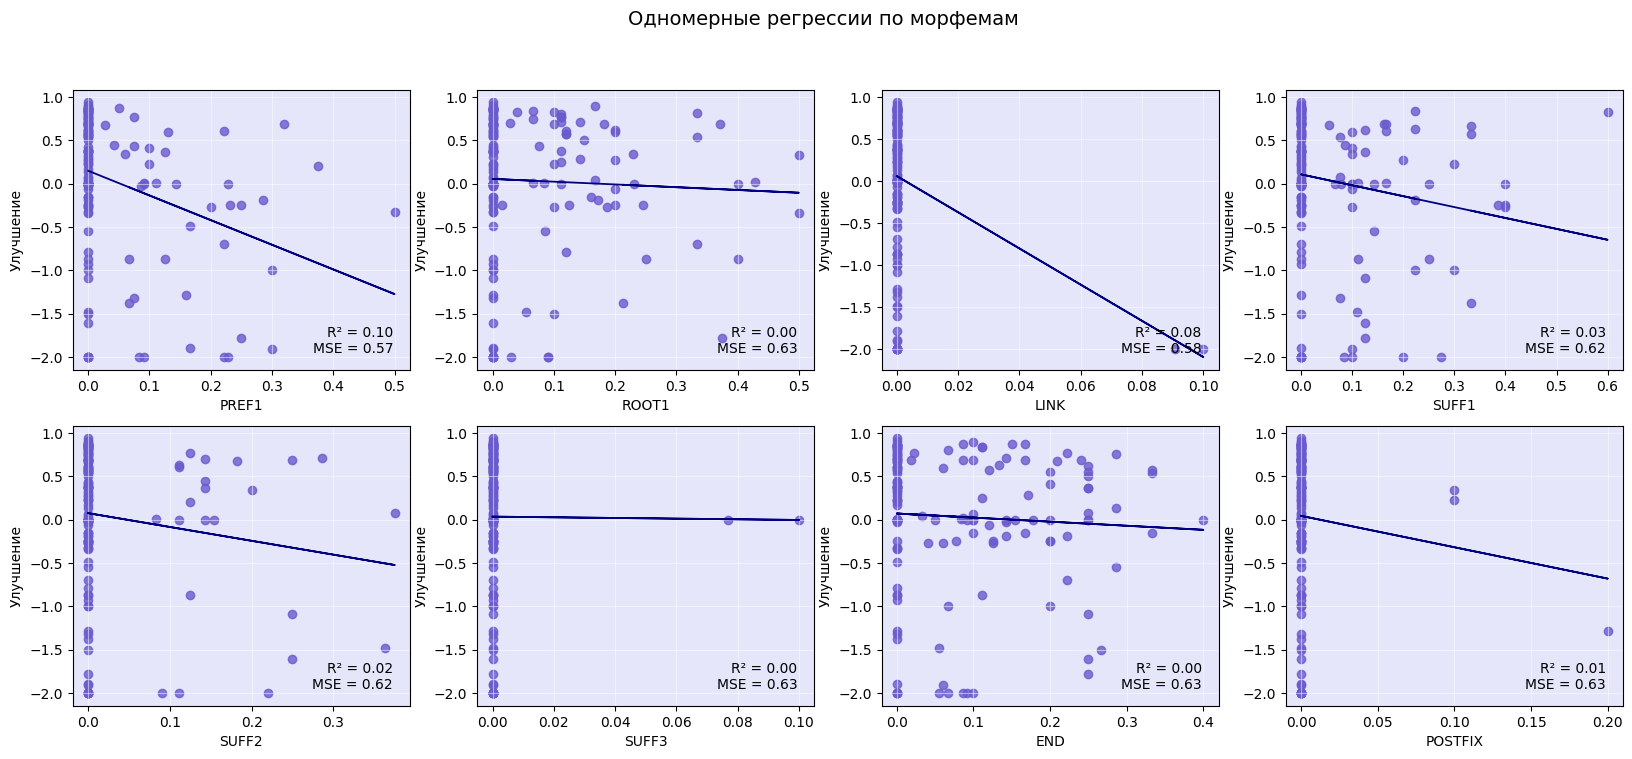

In [33]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Белорусский

### True norm

In [37]:
results = regression_results('for_regression/true/bel_true.csv', 'bel', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.8443374174349181, 0.6310944274086101)

In [38]:
df.to_csv(
    'linreg_ana/true_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

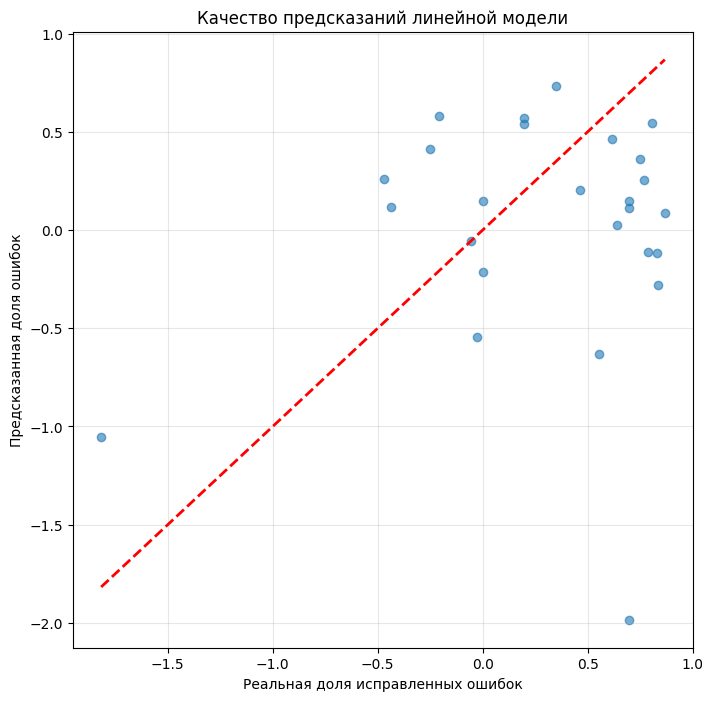

In [39]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

PREF1: -0.373
PREF2: 0.106
ROOT1: -0.123
LINK: -0.203
SUFF1: -0.259
SUFF2: 0.052
SUFF3: 0.193
END: 0.222
POSTFIX: -0.041


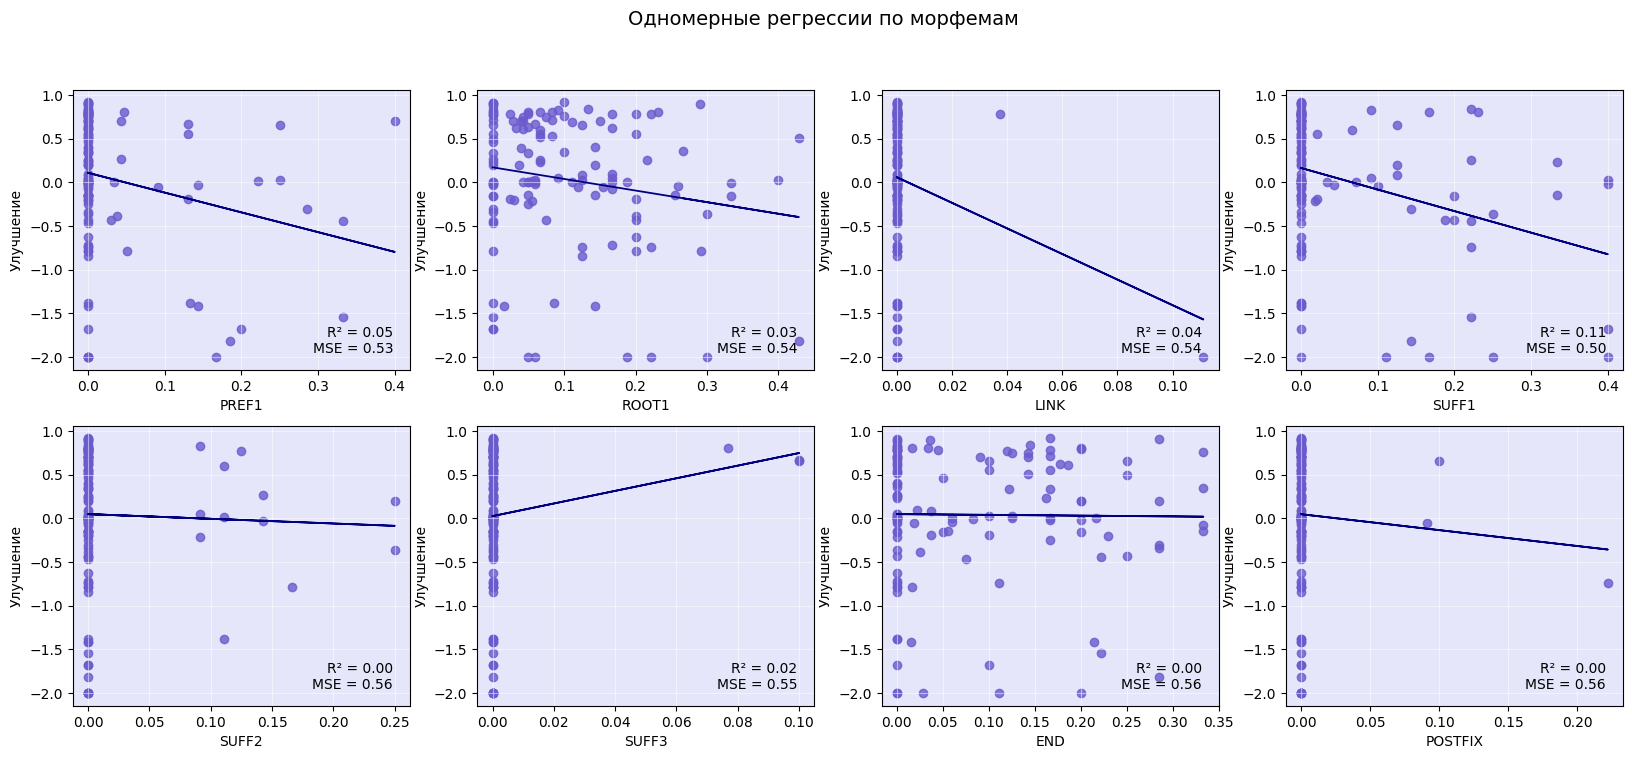

In [41]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [45]:
results = regression_results('for_regression/part/bel_part1.csv', 'bel', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.25632392458420505, 0.922538167480151)

In [46]:
df.to_csv(
    'linreg_ana/part_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

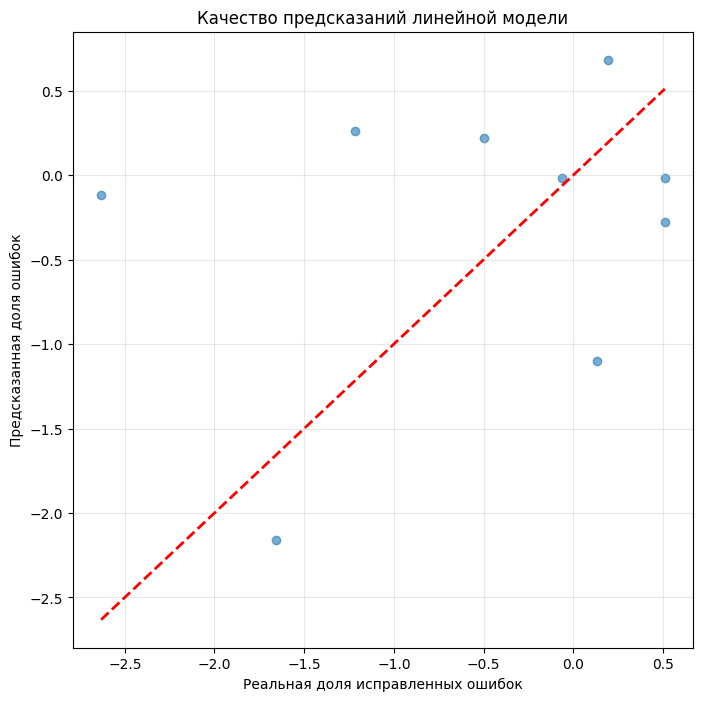

In [47]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: -0.394
PREF1: -0.316
PREF2: 0.039
ROOT1: -0.178
SUFF1: -0.538
SUFF2: -0.185
END: -0.094
POSTFIX: 0.096


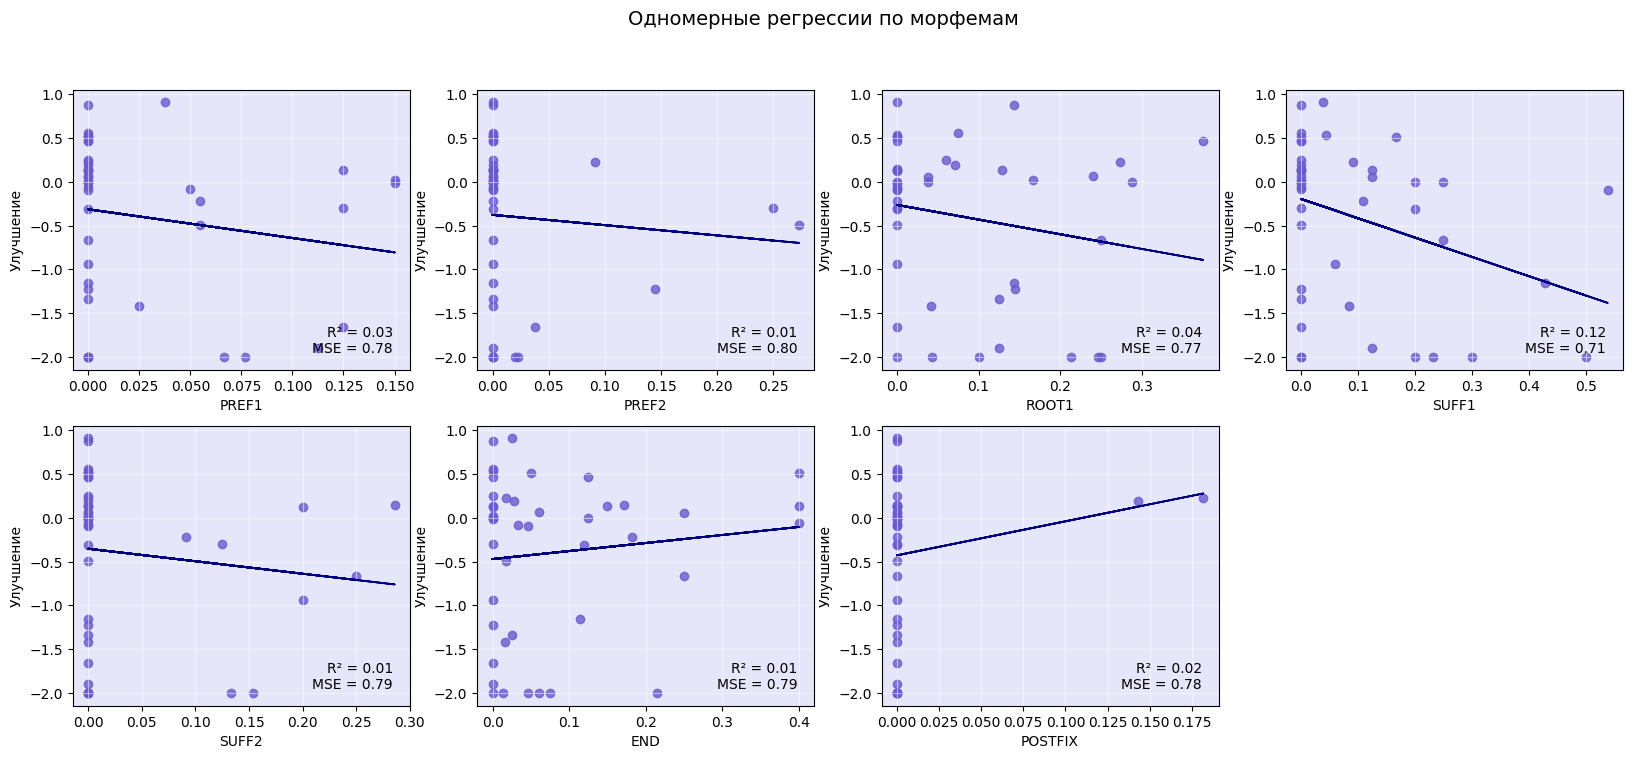

In [49]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [53]:
results = regression_results(df_both_n, 'bel', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.23935417924326763, 0.9587051020968921)

In [54]:
df.to_csv(
    'linreg_ana/both_norm/bel_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

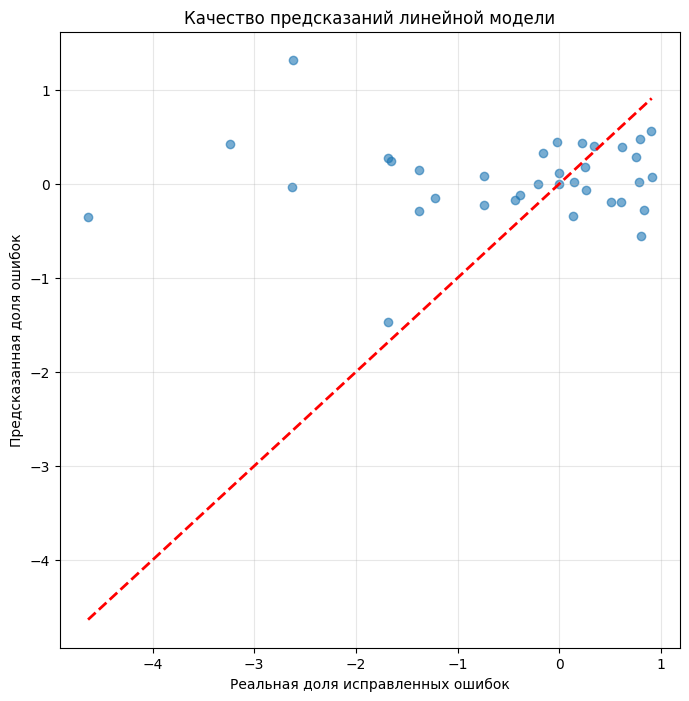

In [55]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: 0.034
PREF1: -0.227
PREF2: -0.046
ROOT1: -0.162
LINK: 0.047
SUFF1: -0.357
SUFF2: -0.078
SUFF3: 0.058
END: 0.108
POSTFIX: 0.042


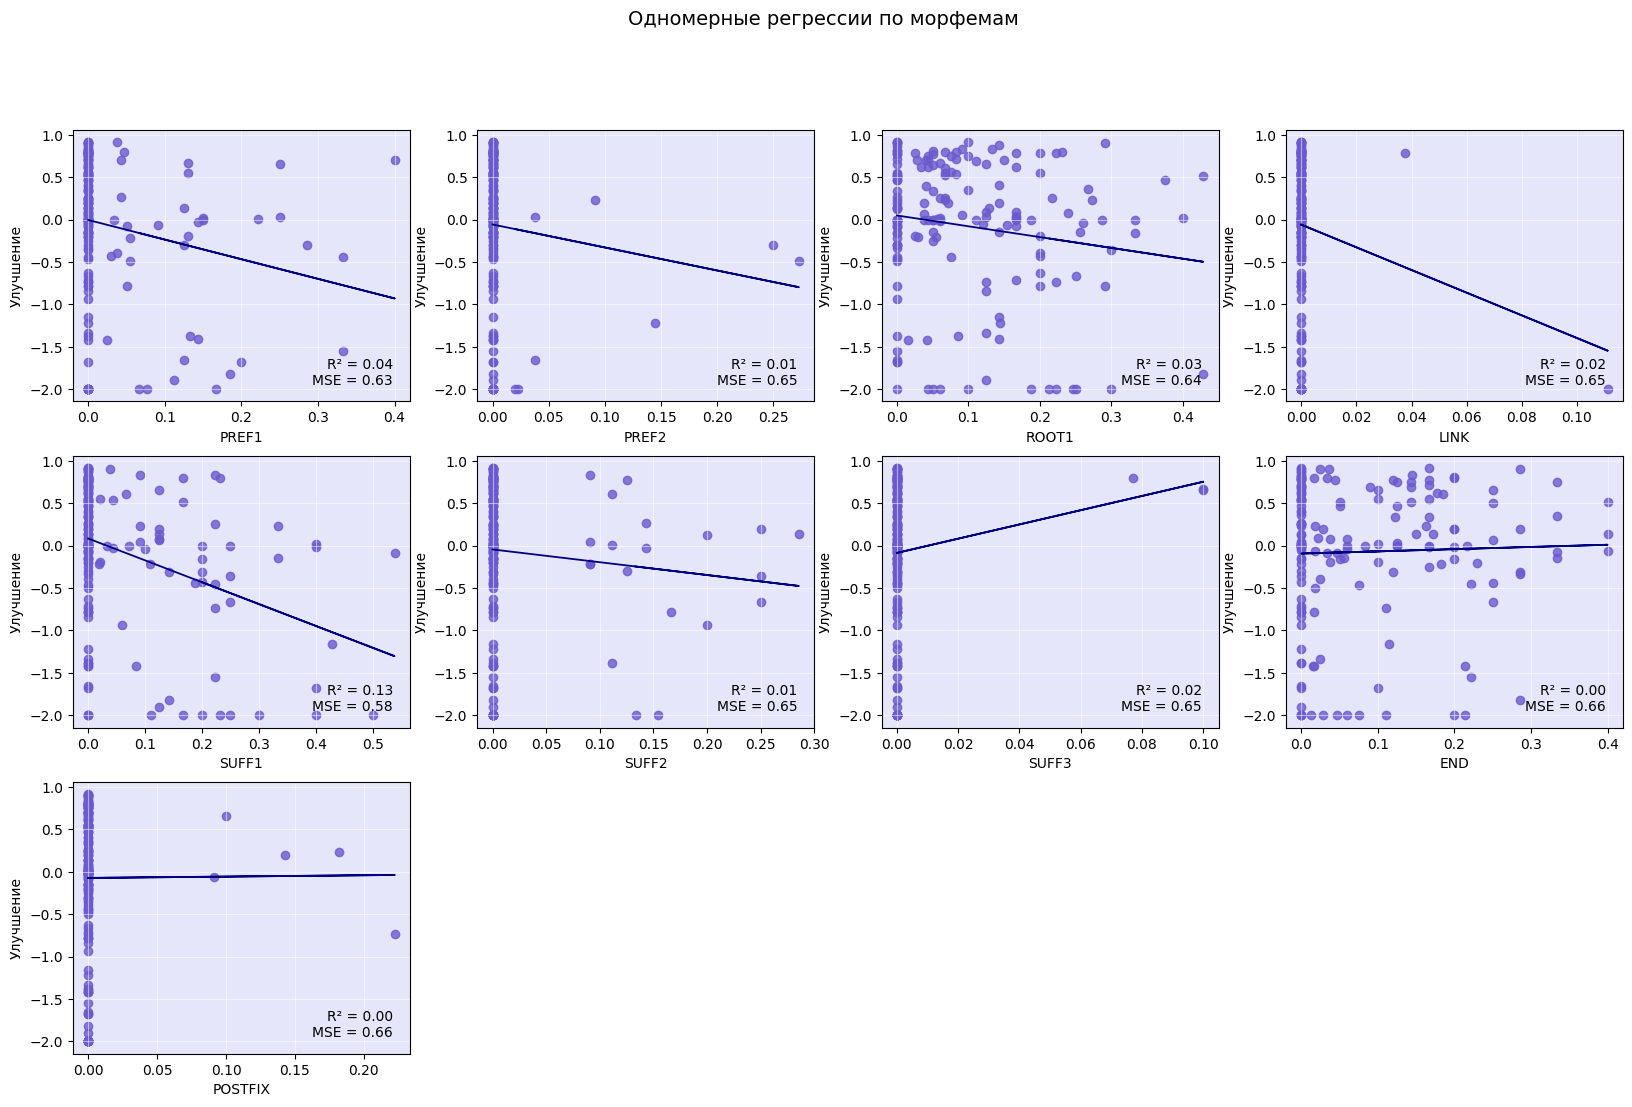

In [57]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Болгарский

### True norm

In [61]:
results = regression_results('for_regression/true/bg_true.csv', 'bg', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.14670723954395792, 0.8335775894703765)

In [62]:
df.to_csv(
    'linreg_ana/true_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

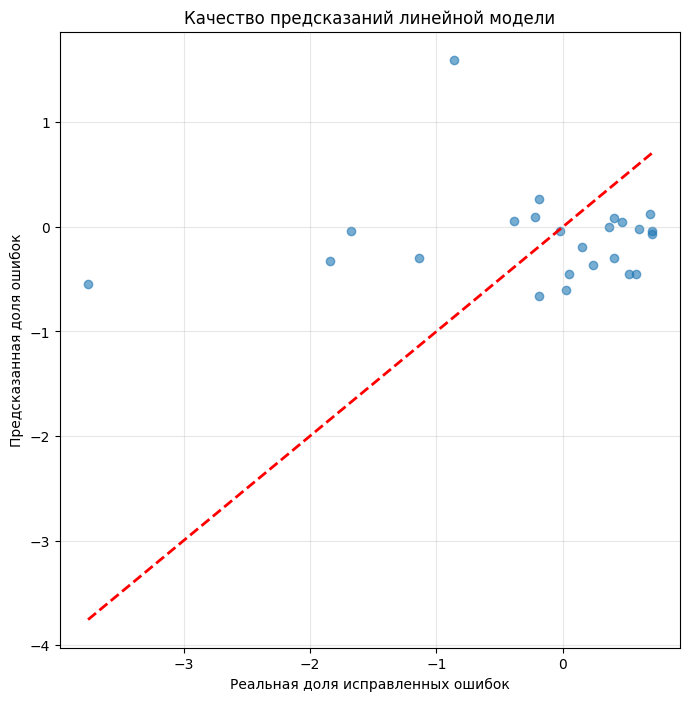

In [63]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [64]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 2.244
PREF1: -0.153
ROOT1: -0.195
ROOT2: -0.0
SUFF1: -0.042
SUFF2: 0.124
SUFF3: 0.054
END: 0.08
POSTFIX: -2.428


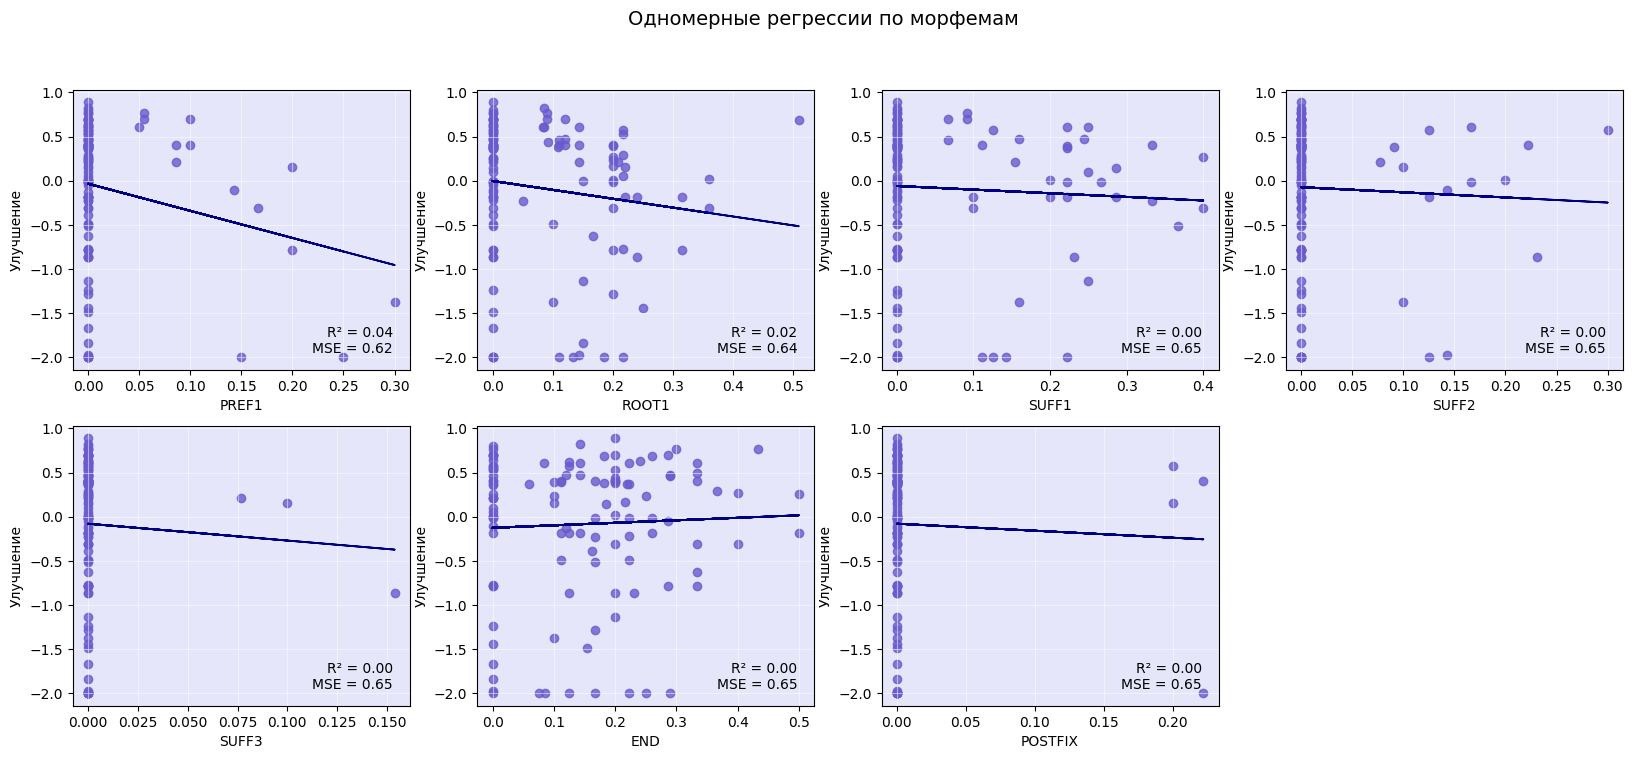

In [65]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [69]:
results = regression_results('for_regression/part/bg_part1.csv', 'bg', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.24356280069199032, 0.6611150722584491)

In [70]:
df.to_csv(
    'linreg_ana/part_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

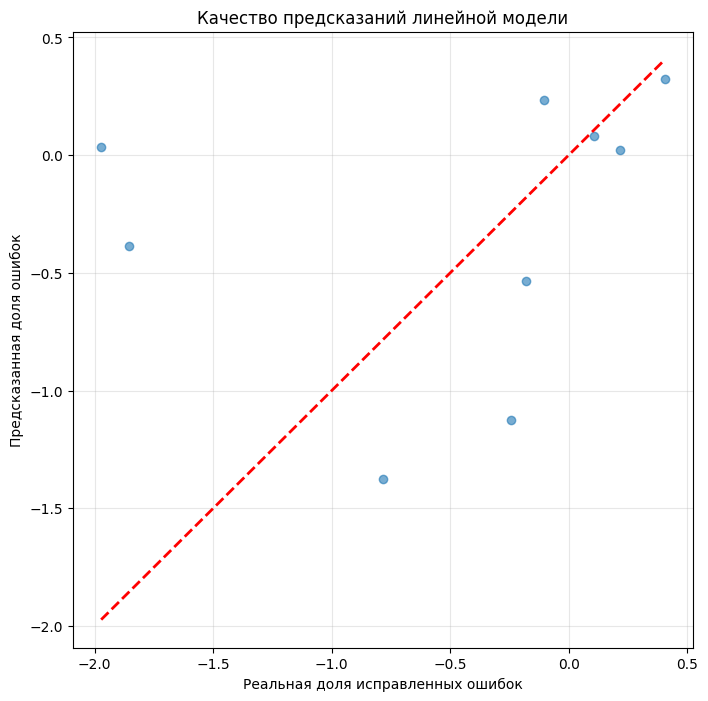

In [71]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: 0.059
PREF1: 0.078
PREF2: 0.0
ROOT1: 0.051
SUFF1: -0.208
SUFF2: -0.482
SUFF3: 0.205
END: 0.098
POSTFIX: 0.089


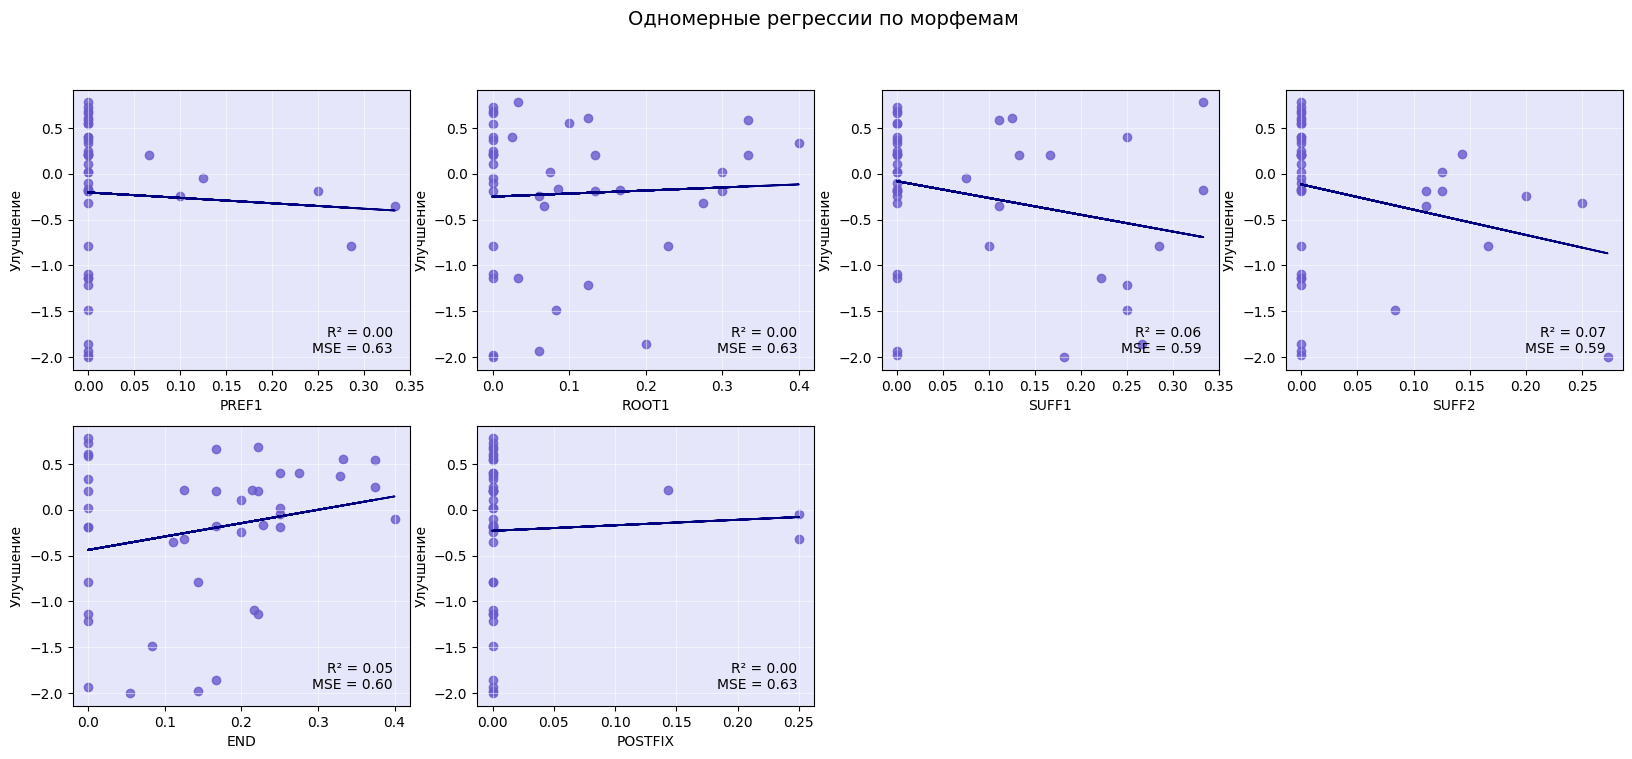

In [73]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [77]:
results = regression_results(df_both_n, 'bg', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.17008117436575443, 0.9432880748460356)

In [78]:
df.to_csv(
    'linreg_ana/both_norm/bg_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

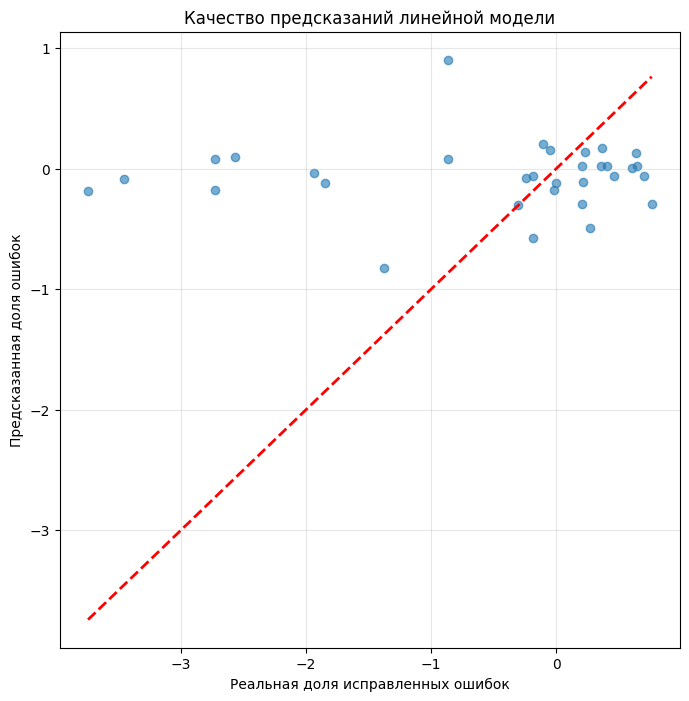

In [79]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [80]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.022
different_agreement: 0.071
PREF1: -0.122
PREF2: -0.0
ROOT1: -0.106
ROOT2: 0.028
SUFF1: -0.138
SUFF2: 0.02
SUFF3: 0.121
END: 0.057
POSTFIX: -0.094


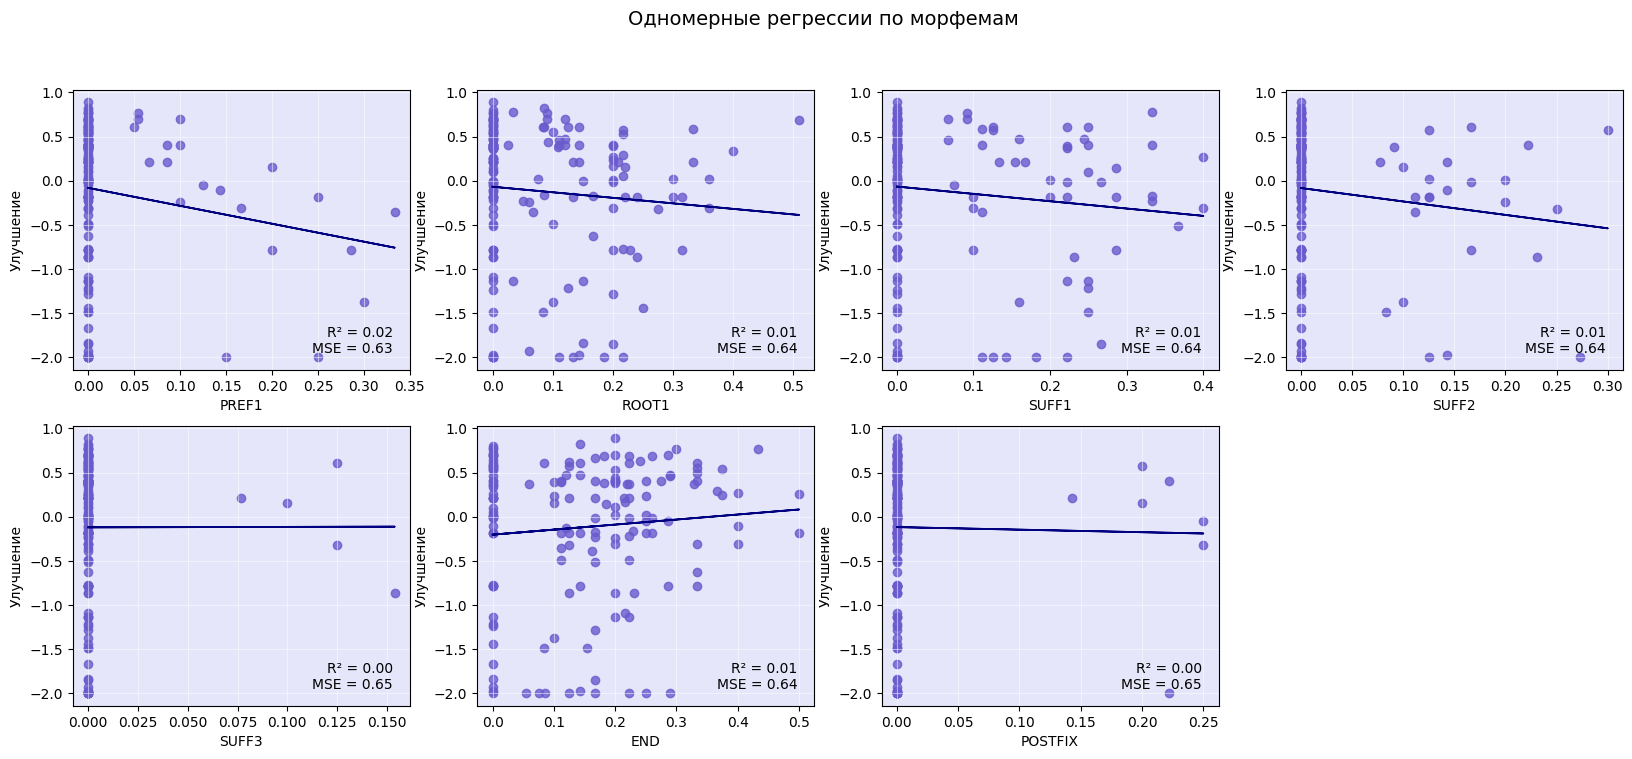

In [81]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Сербский

### True norm

In [85]:
results = regression_results('for_regression/true/sb_true.csv', 'sb', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(0.07343468641238815, 1.1566429920814507)

In [86]:
df.to_csv(
    'linreg_ana/true_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

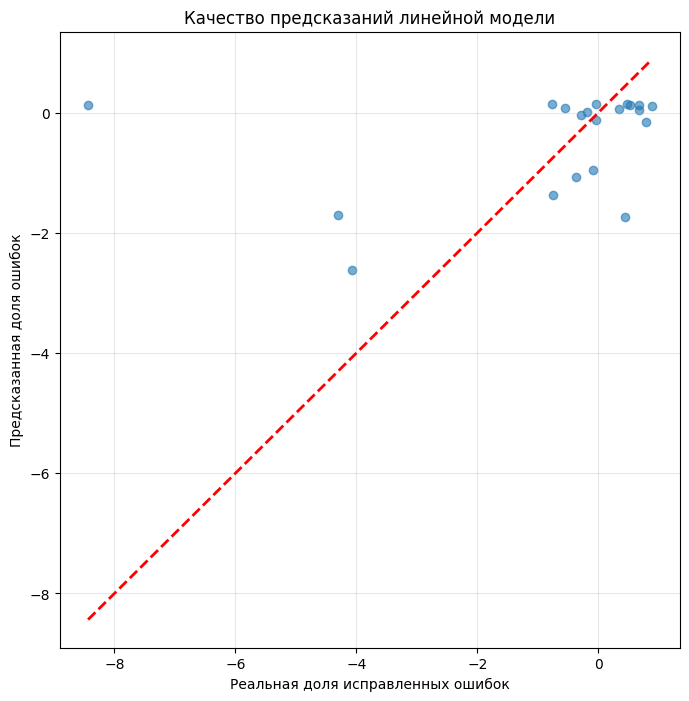

In [87]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [88]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

PREF1: -0.362
PREF2: -0.089
ROOT1: -0.032
ROOT2: -0.211
LINK: -0.211
SUFF1: -0.155
SUFF2: -0.346
SUFF3: -0.0
END: -0.007
POSTFIX: 0.14


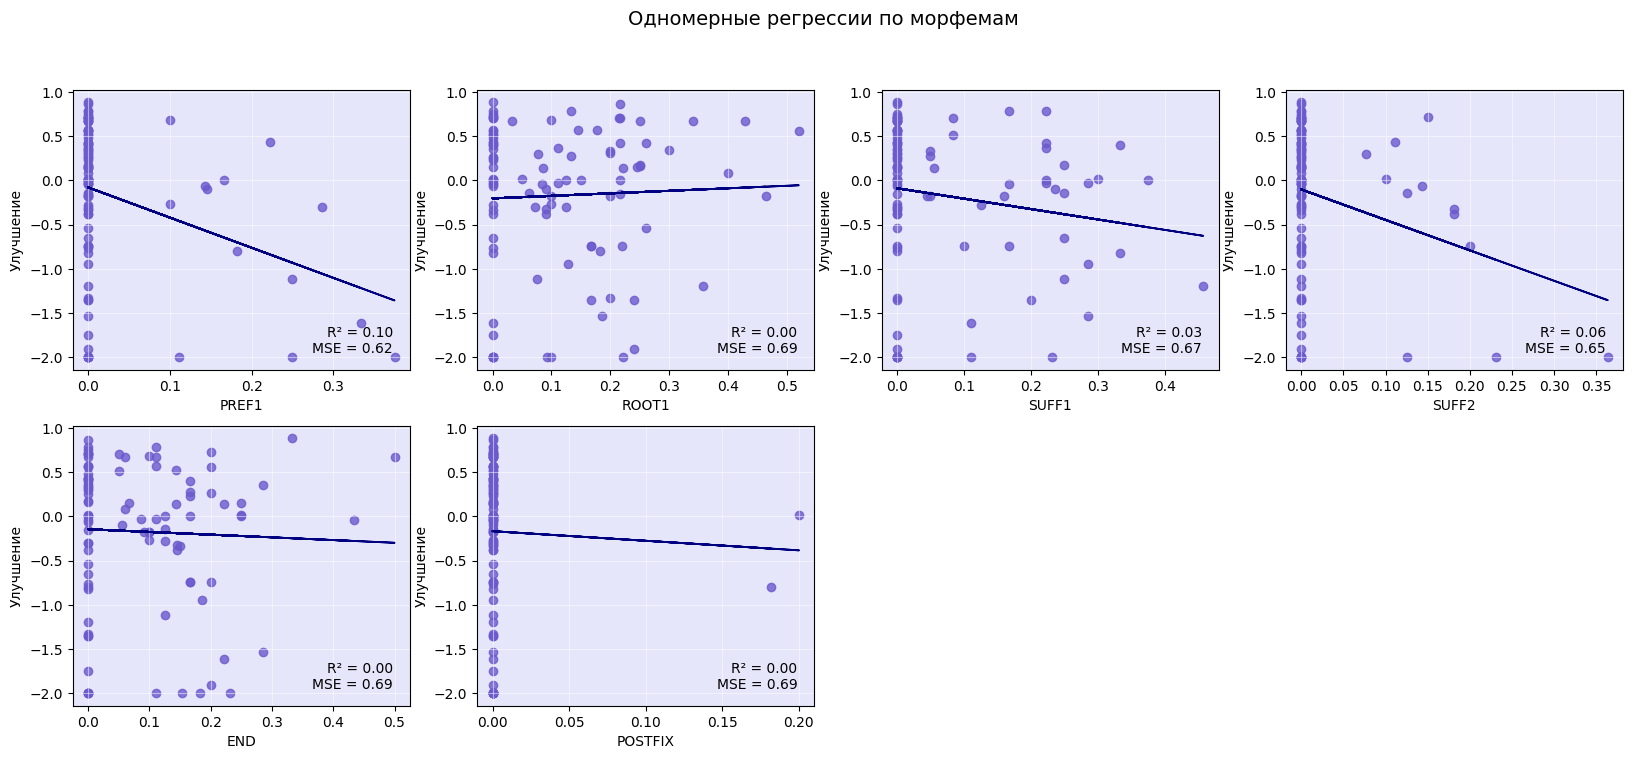

In [89]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [93]:
results = regression_results('for_regression/part/sb_part1.csv', 'sb', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.3180580446648549, 0.9675981080299833)

In [94]:
df.to_csv(
    'linreg_ana/part_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

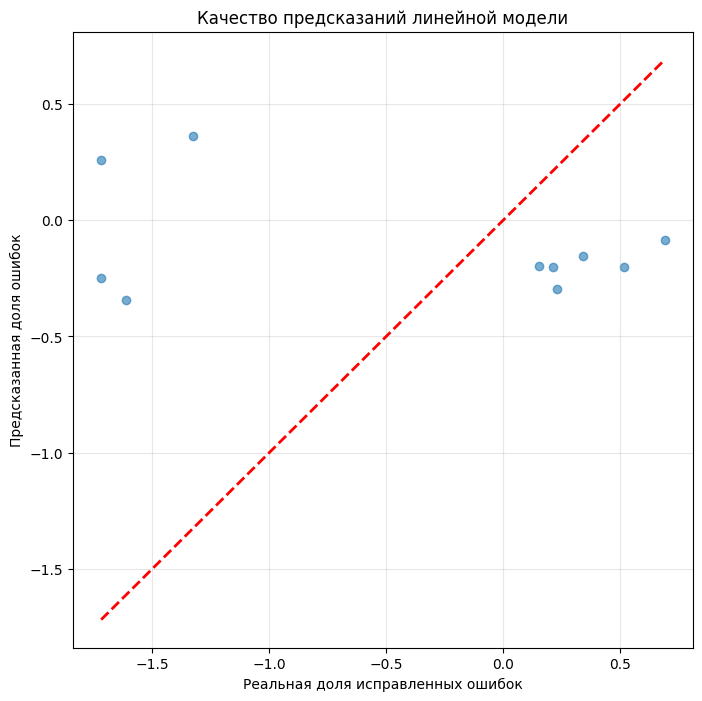

In [95]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [96]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.055
PREF1: -0.053
PREF2: 0.012
ROOT1: -0.086
LINK: 0.174
SUFF1: 0.063
SUFF2: 0.005
END: 0.061
POSTFIX: 0.138


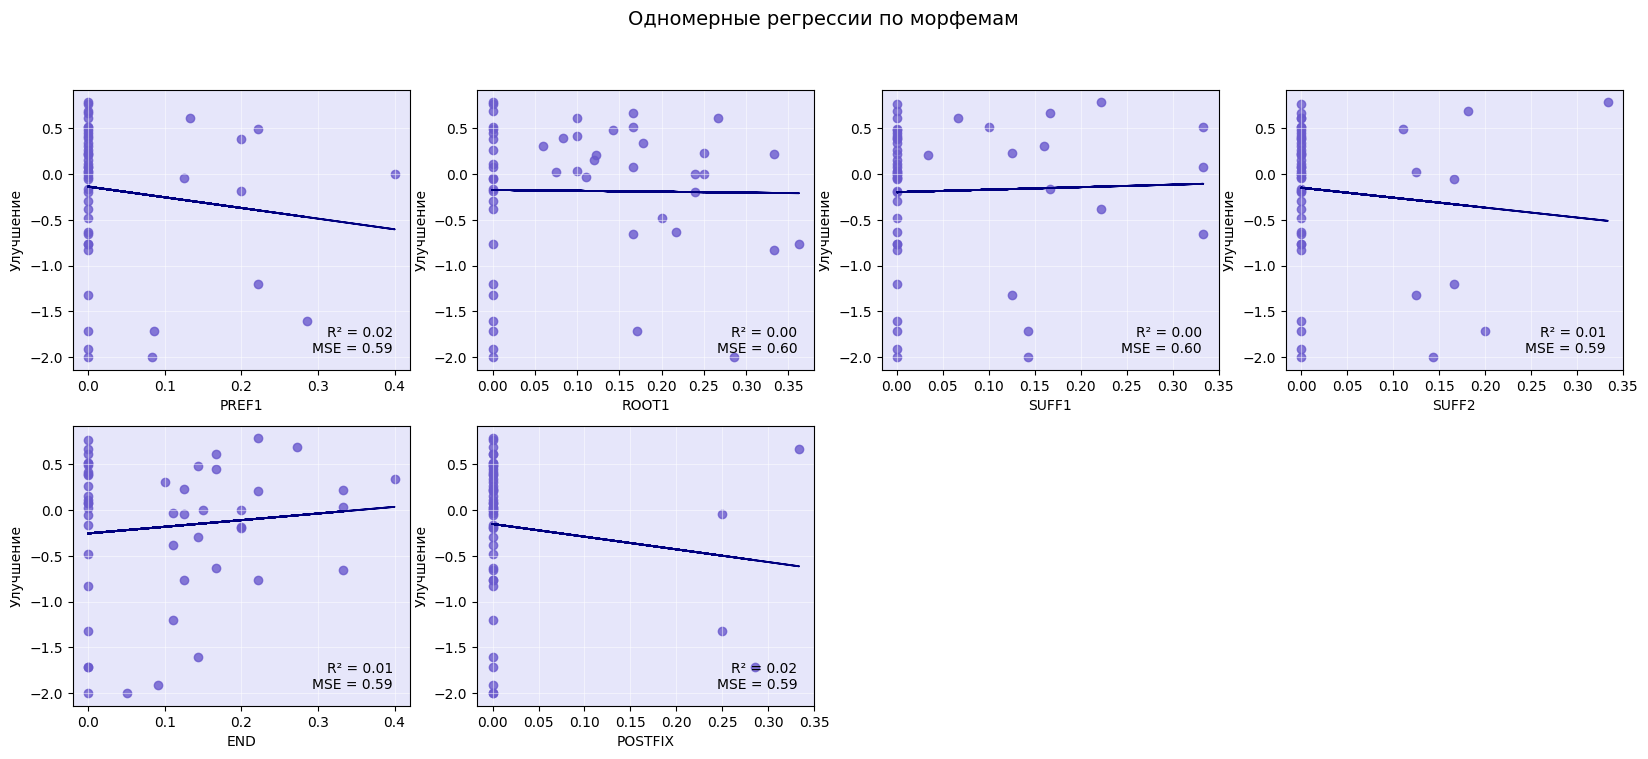

In [97]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [101]:
results = regression_results(df_both_n, 'sb', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.04574549077449097, 1.0849632156215834)

In [102]:
df.to_csv(
    'linreg_ana/both_norm/sb_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

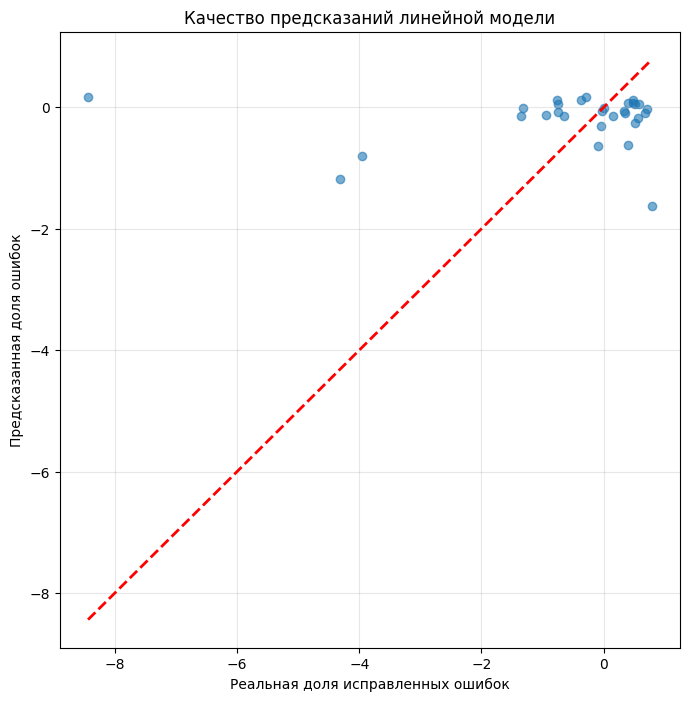

In [103]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [104]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.066
different_agreement: -0.039
PREF1: -0.311
PREF2: 0.03
ROOT1: -0.083
ROOT2: -0.53
LINK: 0.216
SUFF1: -0.08
SUFF2: -0.306
SUFF3: 0.0
END: 0.035
POSTFIX: -0.003


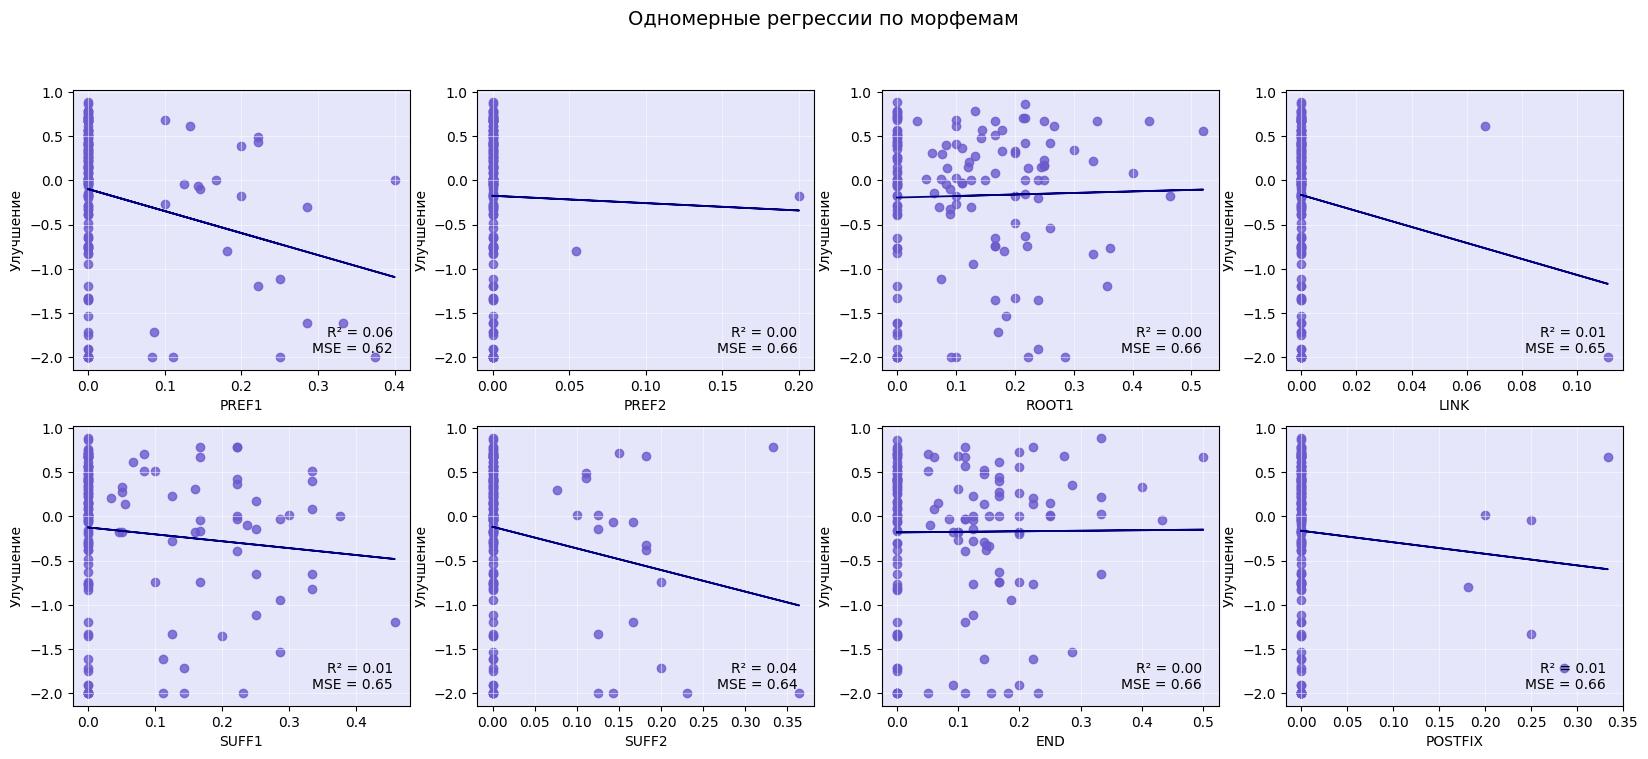

In [105]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Польский

### True norm

In [109]:
results = regression_results('for_regression/true/pol_true.csv', 'pol', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.03484980295072204, 1.1706147768063329)

In [110]:
df.to_csv(
    'linreg_ana/true_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

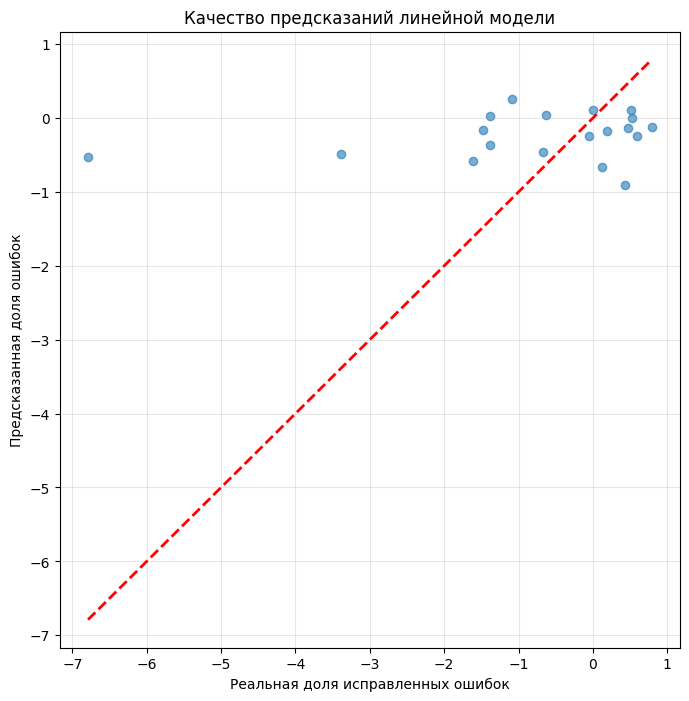

In [111]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [112]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.018
PREF1: -0.261
ROOT1: -0.252
ROOT2: 0.391
LINK: -0.576
SUFF1: 0.1
SUFF2: 0.006
END: -0.017
POSTFIX: 0.034


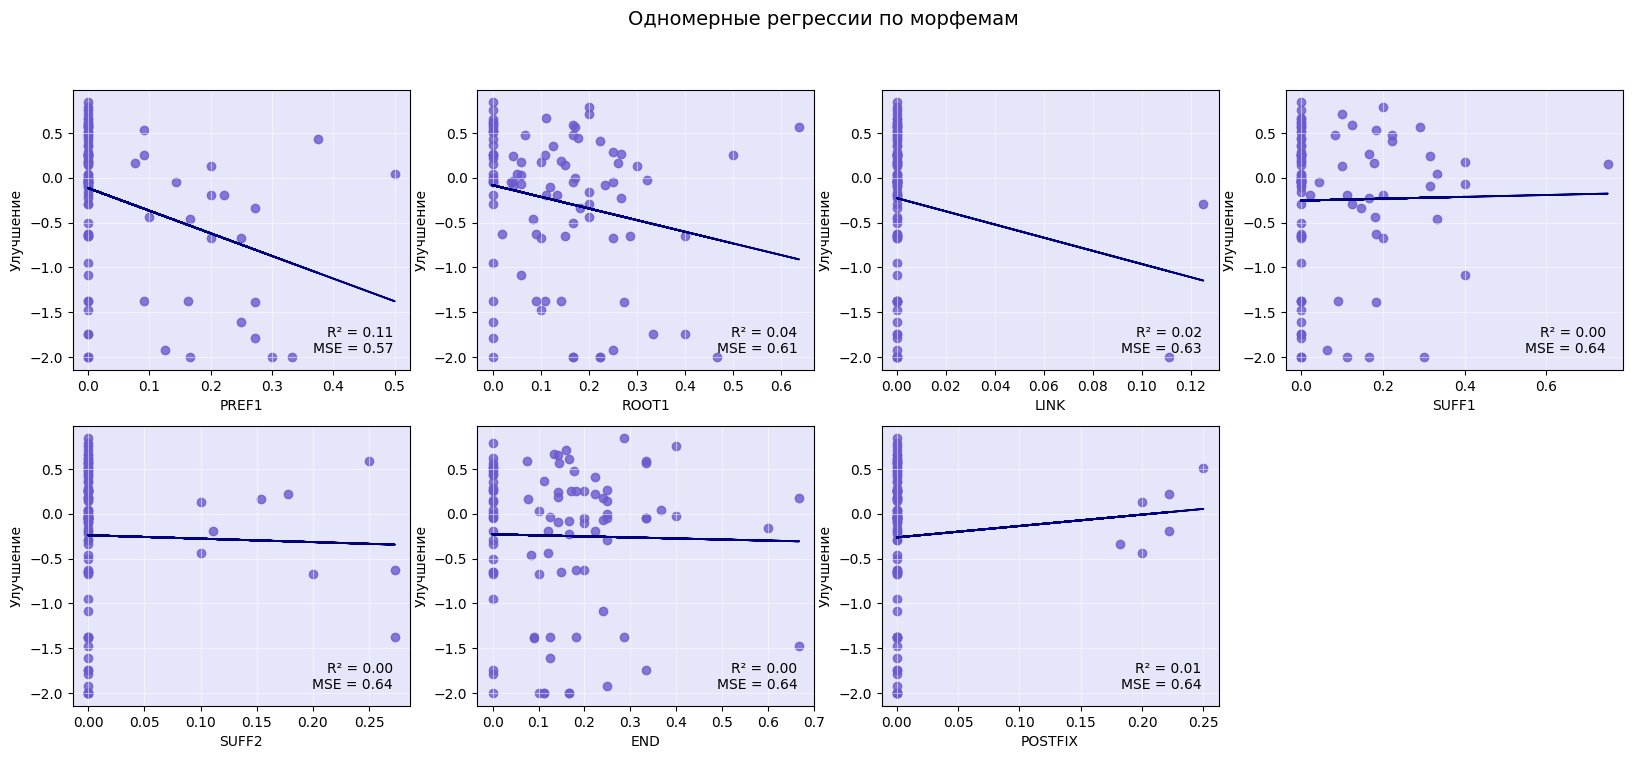

In [113]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [117]:
results = regression_results('for_regression/part/pol_part1.csv', 'pol', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-7.20053725344075, 0.8282358965827648)

In [118]:
df.to_csv(
    'linreg_ana/part_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

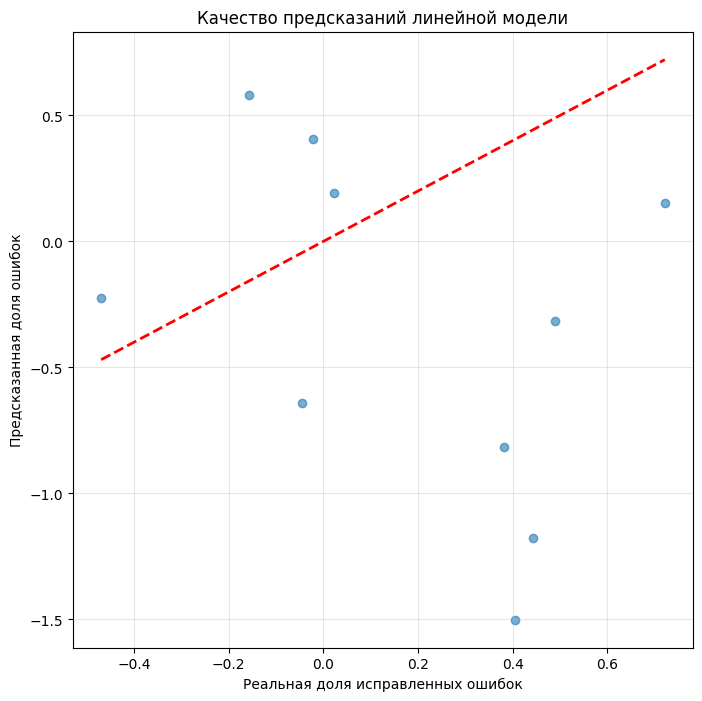

In [119]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [120]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.756
PREF1: 0.277
ROOT1: 0.237
SUFF1: -0.053
SUFF2: -0.194
END: 0.445
POSTFIX: -0.613


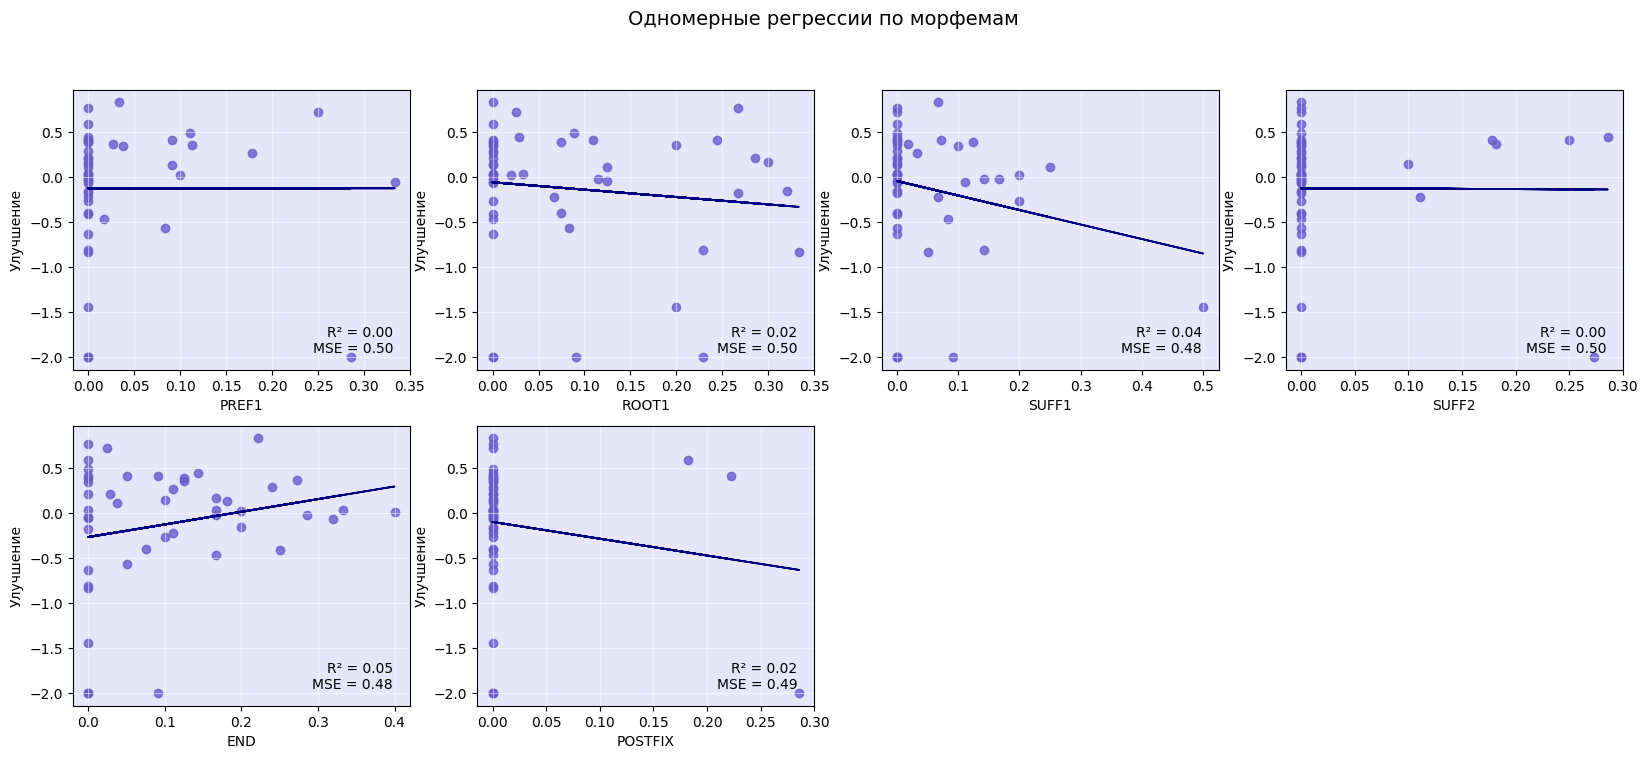

In [121]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [125]:
results = regression_results(df_both_n, 'pol', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.5784224028461344, 0.696453695113263)

In [126]:
df.to_csv(
    'linreg_ana/both_norm/pol_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

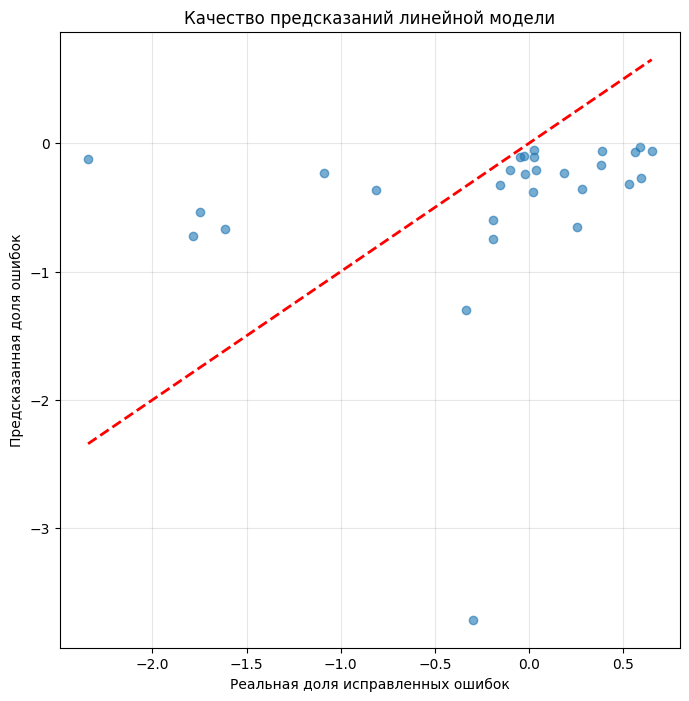

In [127]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [128]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.209
PREF1: -0.238
ROOT1: -0.15
ROOT2: 0.0
LINK: -0.304
SUFF1: -0.029
SUFF2: 0.014
END: -0.007
POSTFIX: -0.102


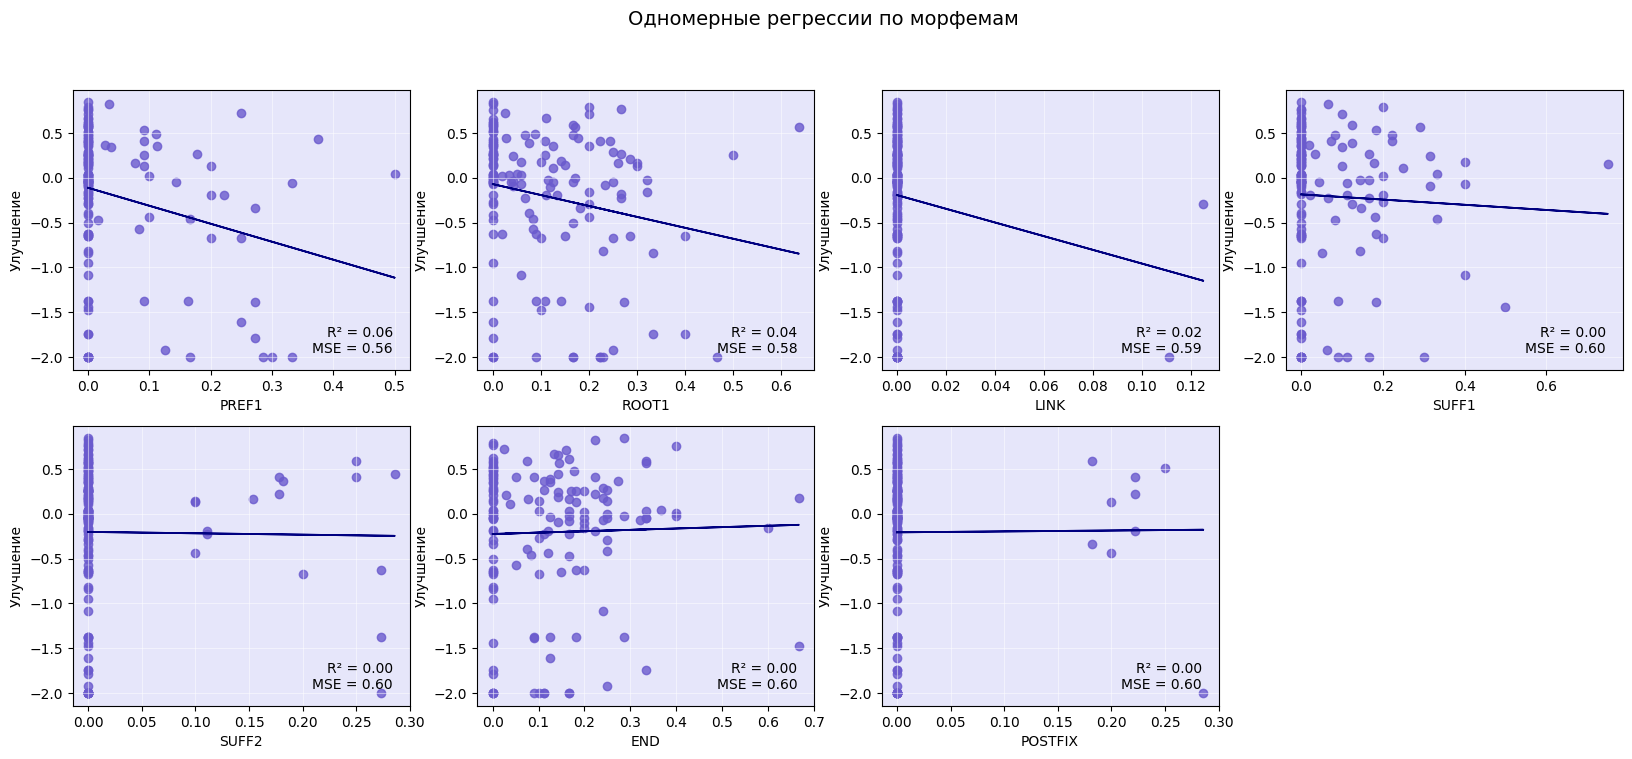

In [129]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Чешский

### True norm

In [133]:
results = regression_results('for_regression/true/cz_true.csv', 'cz', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.14964850193873525, 0.7338514683629157)

In [134]:
df.to_csv(
    'linreg_ana/true_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

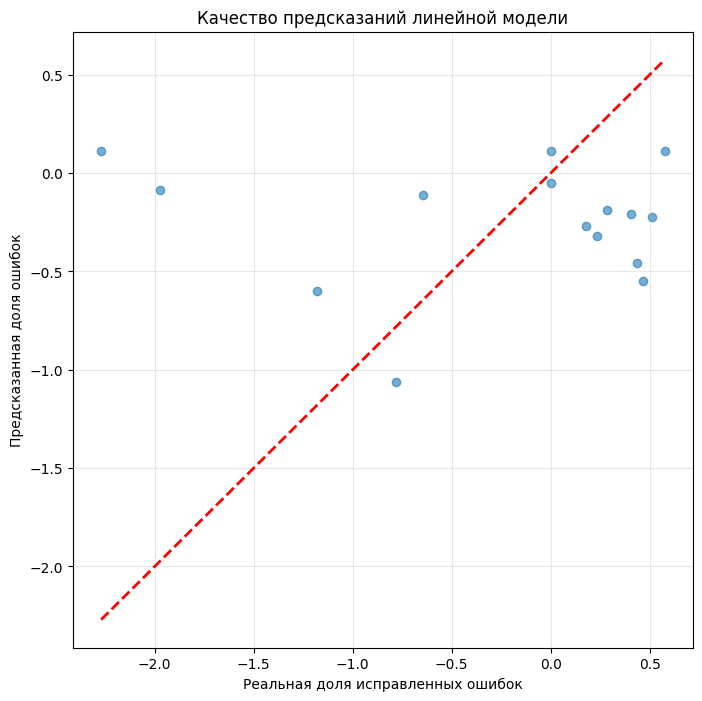

In [135]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [136]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: -0.047
PREF1: -0.324
ROOT1: -0.112
LINK: -0.492
SUFF1: -0.163
SUFF2: 0.122
END: -0.101
POSTFIX: 0.052


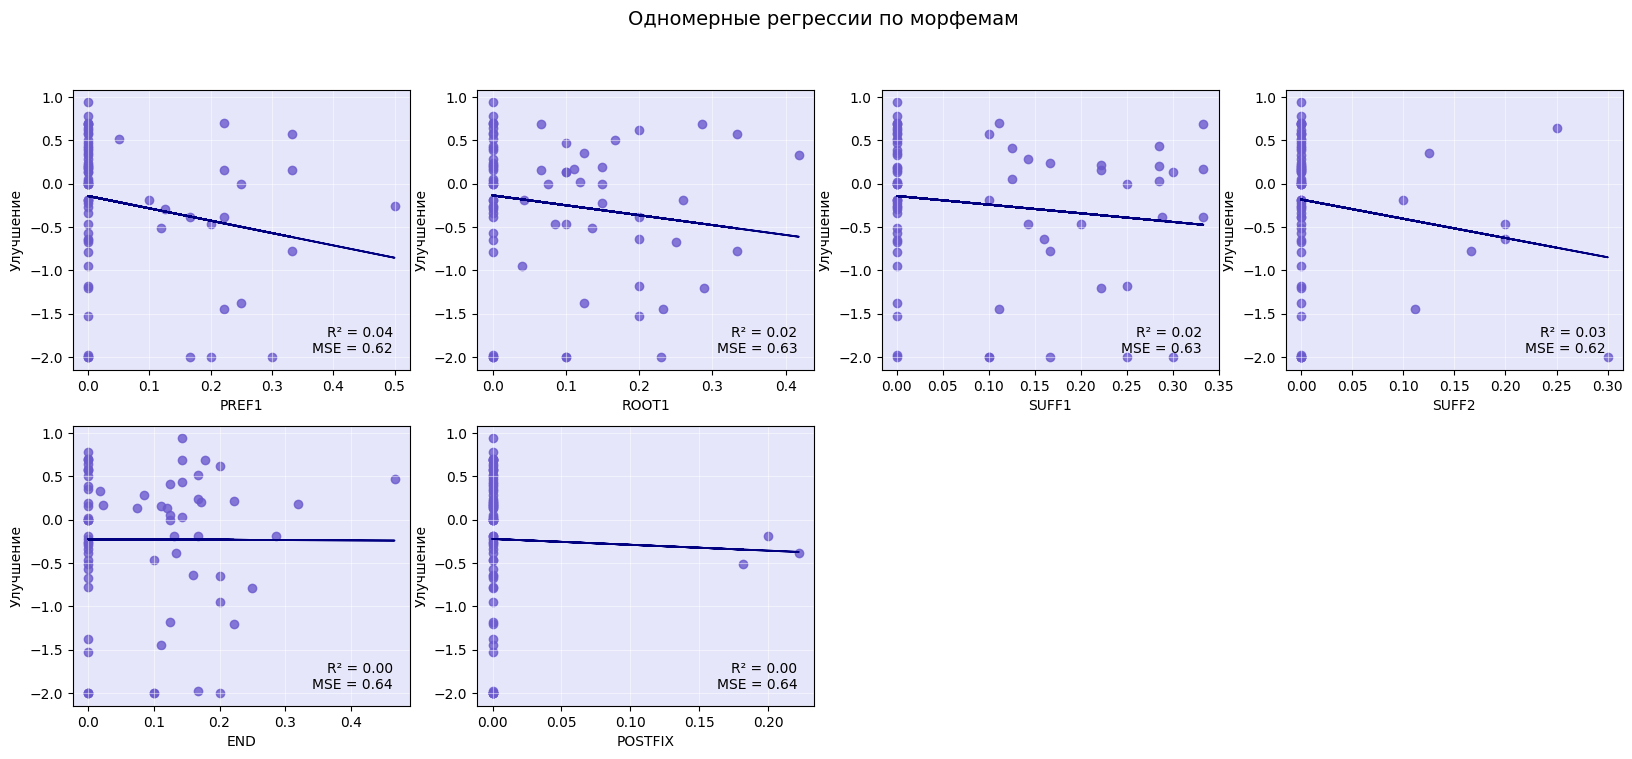

In [137]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [141]:
results = regression_results('for_regression/part/cz_part1.csv', 'cz', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-23.115910829763013, 1.5672106571899544)

In [142]:
df.to_csv(
    'linreg_ana/part_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

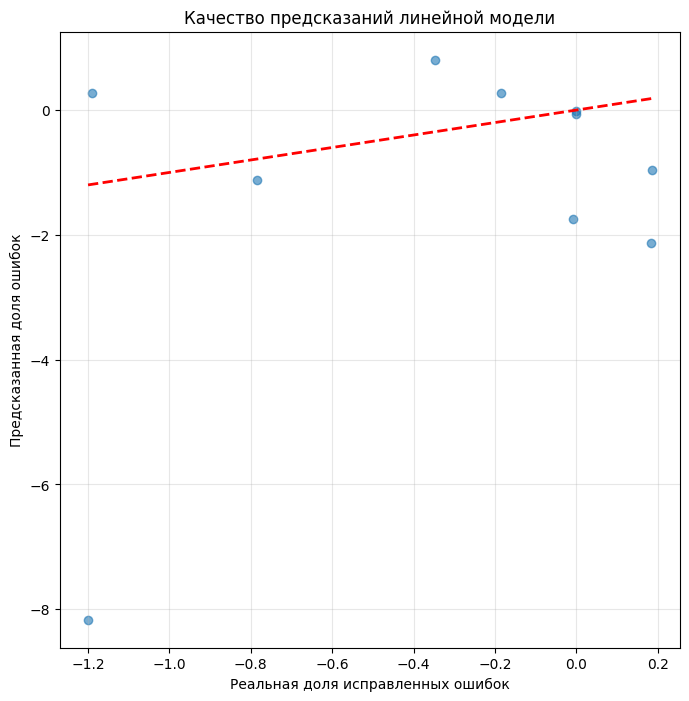

In [143]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [144]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: 0.043
PREF1: -0.293
PREF2: -0.674
ROOT1: -0.692
SUFF1: -0.4
SUFF2: 0.283
END: -0.161
POSTFIX: -0.075


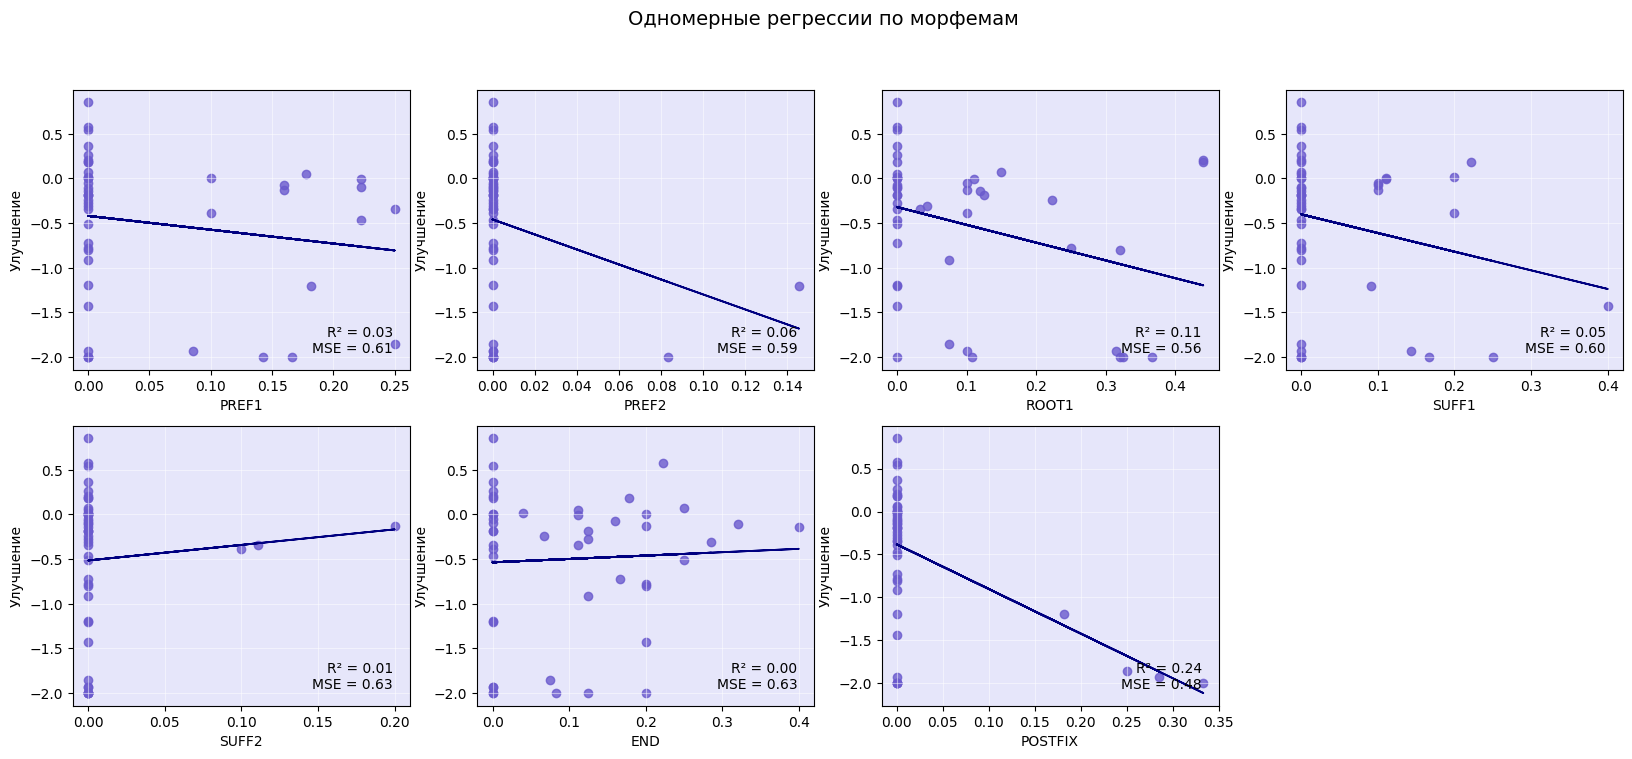

In [145]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [149]:
results = regression_results(df_both_n, 'cz', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(0.0636549577501393, 0.9103509342821999)

In [150]:
df.to_csv(
    'linreg_ana/both_norm/cz_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

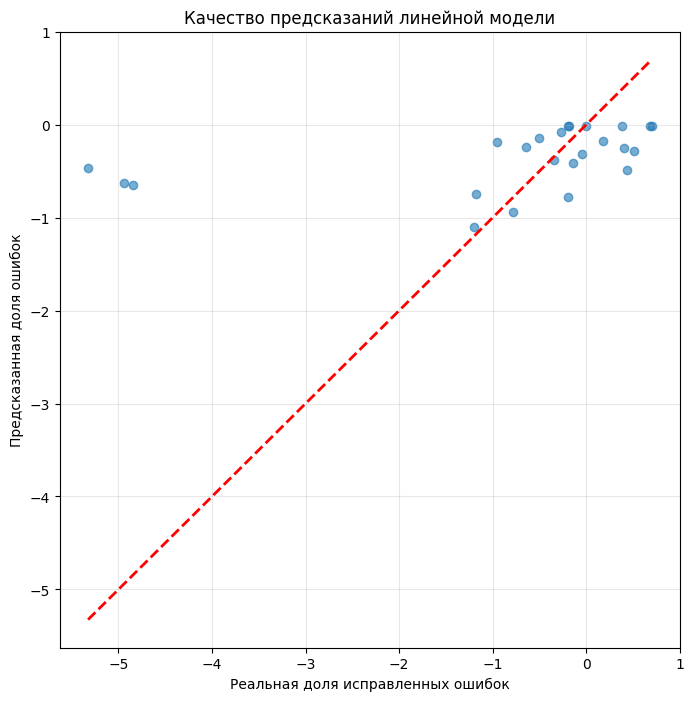

In [151]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [152]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.06
different_agreement: 0.021
PREF1: -0.152
PREF2: -0.0
ROOT1: -0.189
LINK: -0.37
SUFF1: -0.151
SUFF2: 0.105
END: -0.049
POSTFIX: -0.22


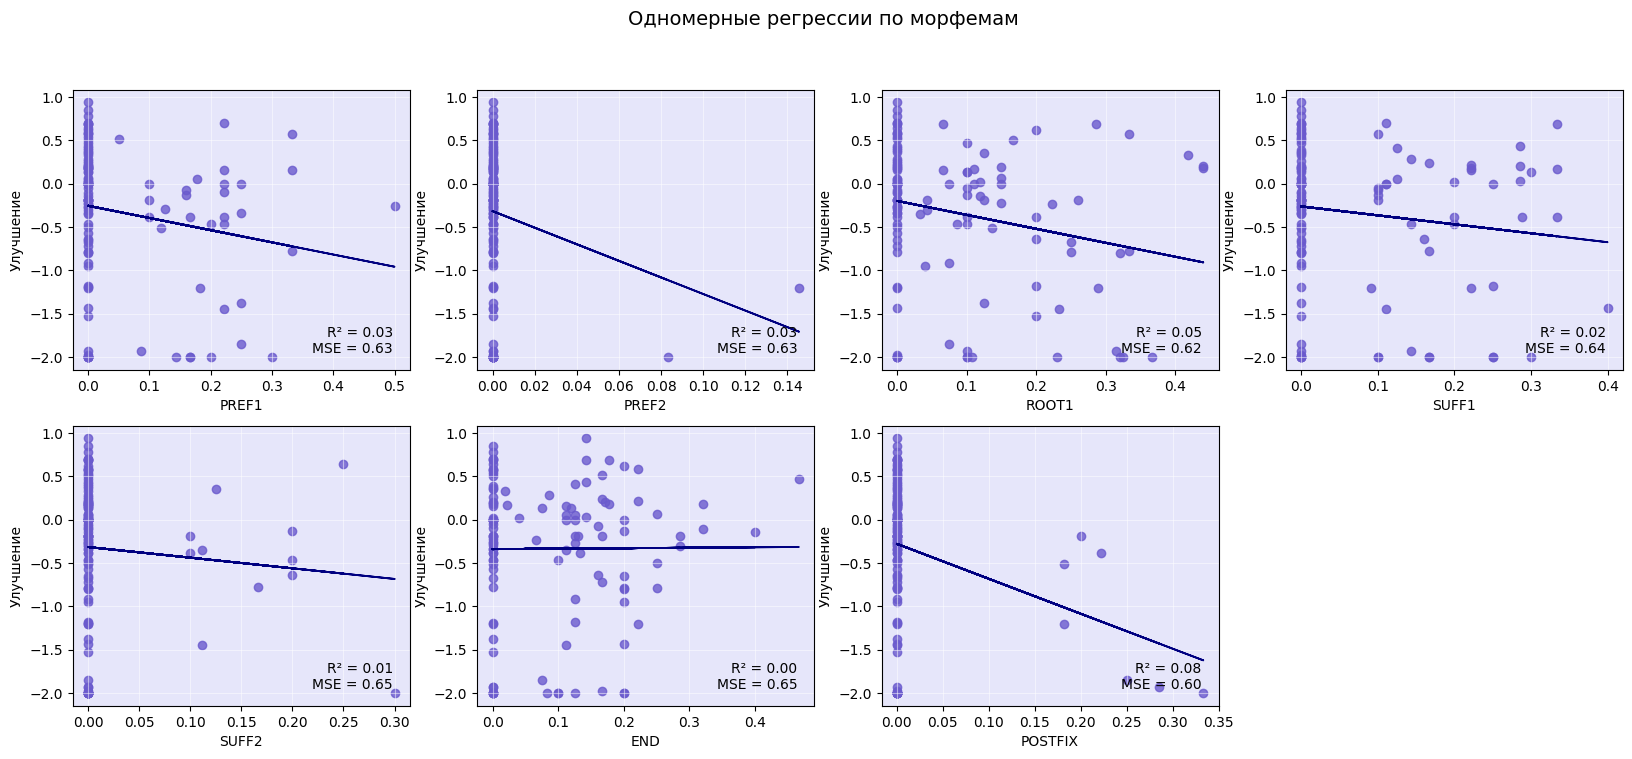

In [153]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Словацкий

### True norm

In [157]:
results = regression_results('for_regression/true/sk_true.csv', 'sk', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-2.517481618658697, 0.9146172309551265)

In [158]:
df.to_csv(
    'linreg_ana/true_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

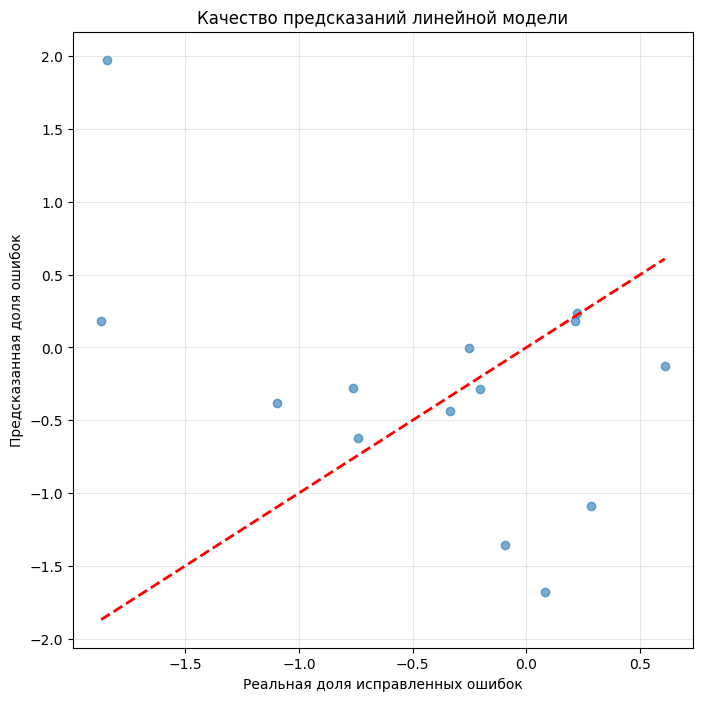

In [159]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [160]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
PREF1: -0.376
ROOT1: -0.366
ROOT2: 1.345
LINK: -1.741
SUFF1: -0.042
SUFF2: 0.08
END: 0.041
POSTFIX: 0.0


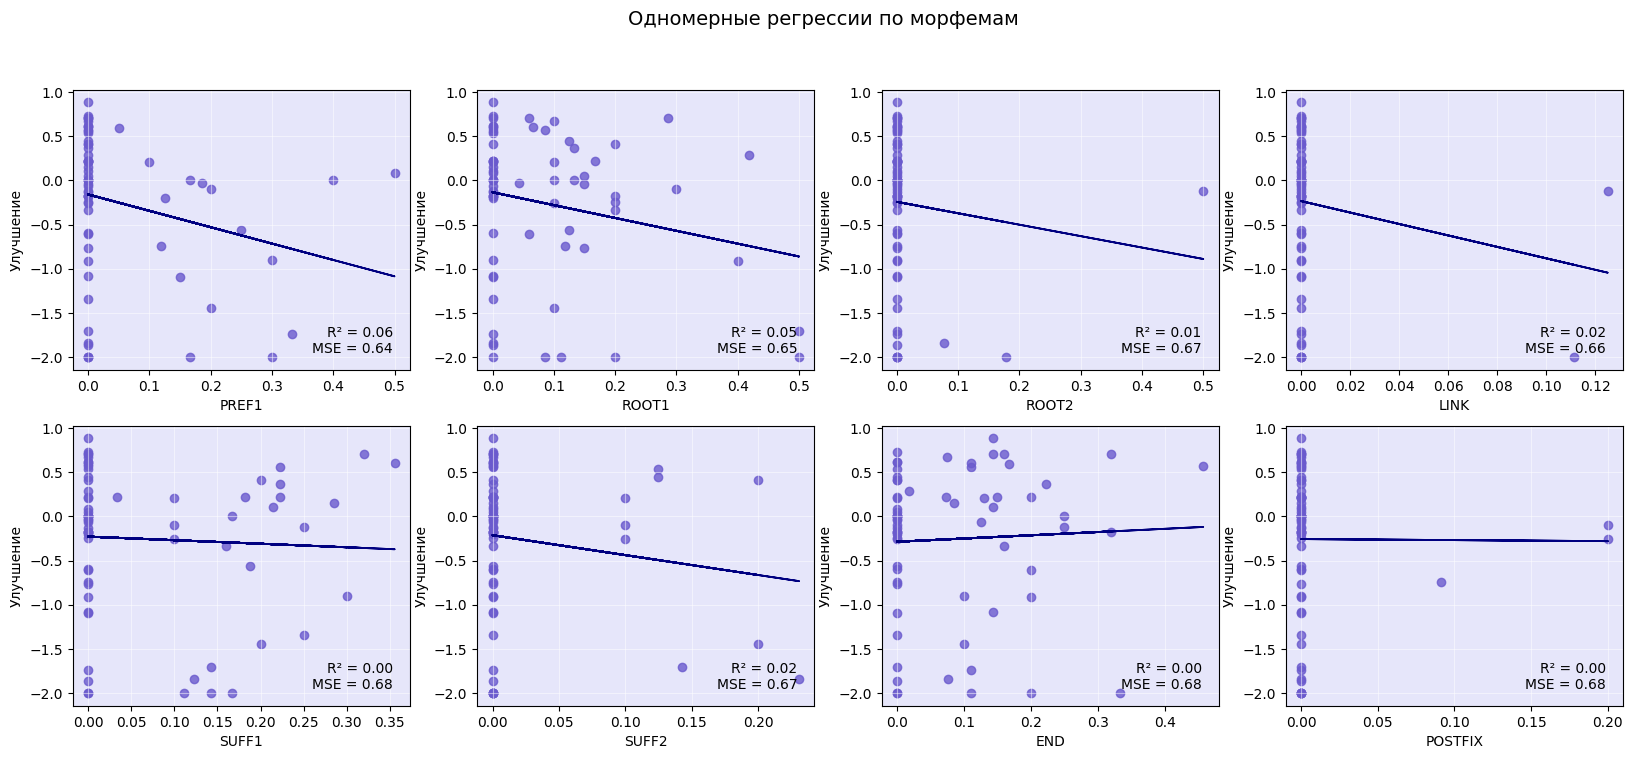

In [161]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [165]:
results = regression_results('for_regression/part/sk_part1.csv', 'sk', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-1.896148466133686, 0.5524344437325731)

In [166]:
df.to_csv(
    'linreg_ana/part_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

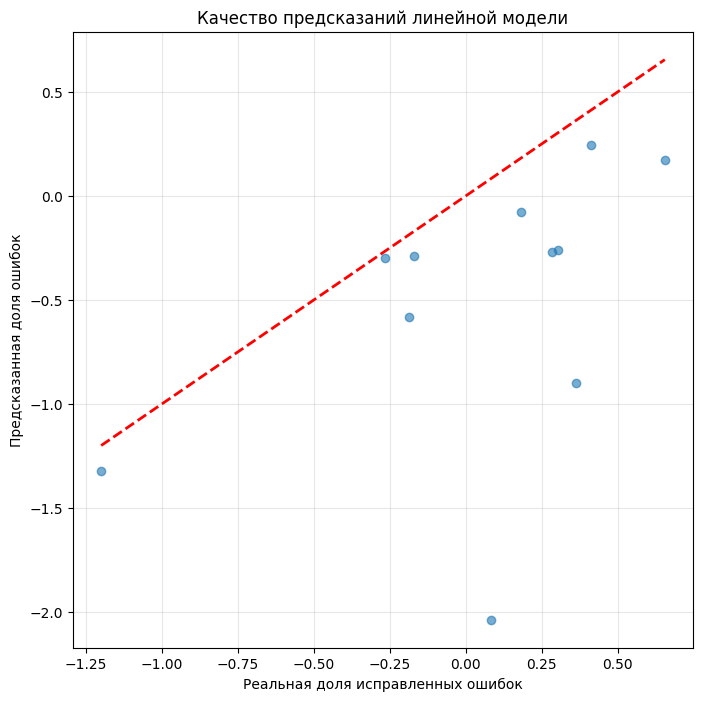

In [167]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [168]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: -0.412
PREF1: 0.065
PREF2: -0.044
ROOT1: 0.084
SUFF1: -0.172
SUFF2: -0.242
END: 0.315
POSTFIX: -0.373


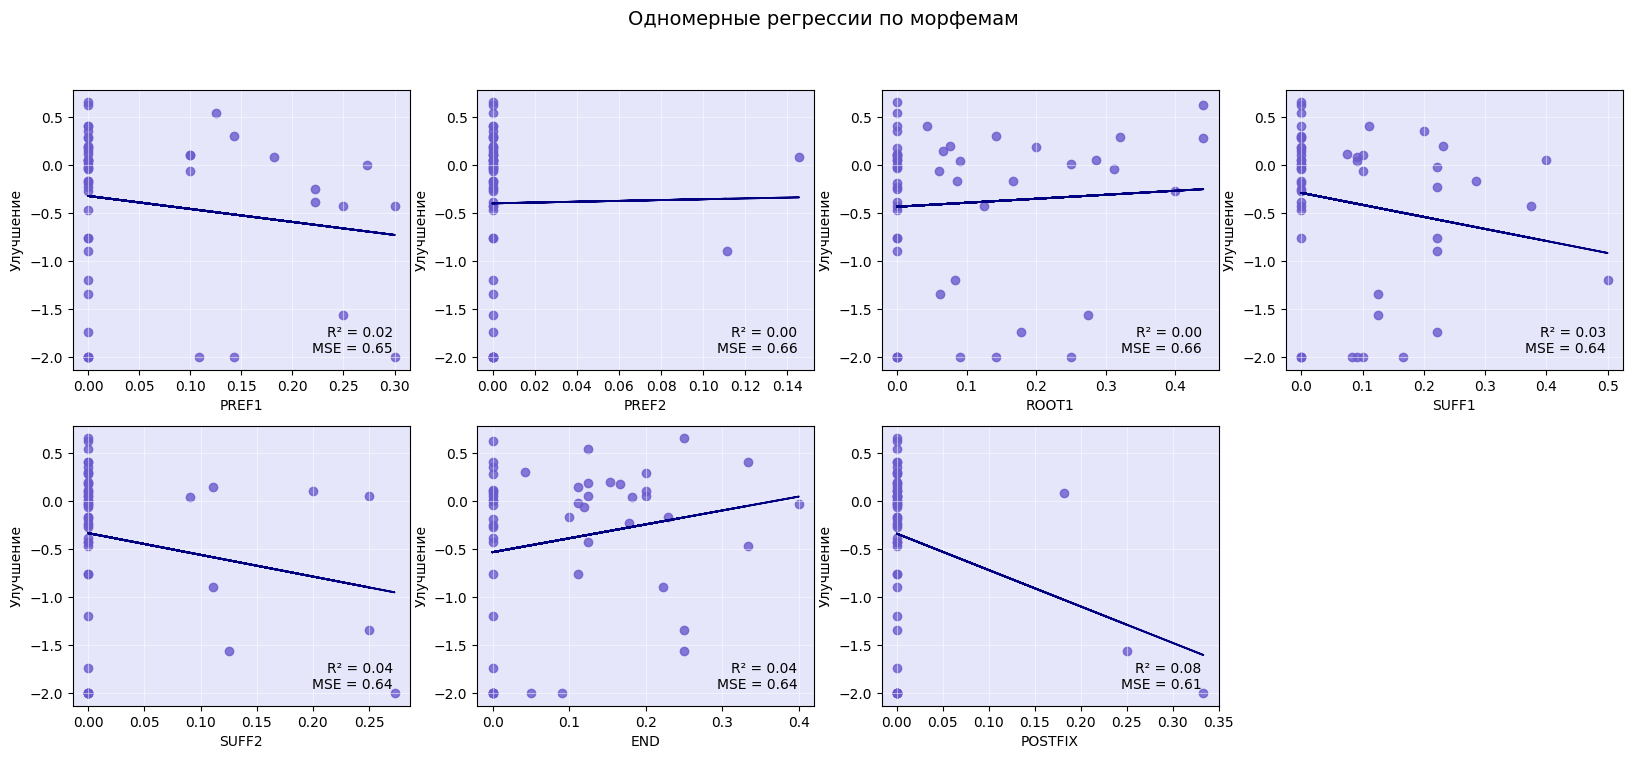

In [169]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [173]:
results = regression_results(df_both_n, 'sk', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.14153167958153468, 0.8112886944400585)

In [174]:
df.to_csv(
    'linreg_ana/both_norm/sk_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

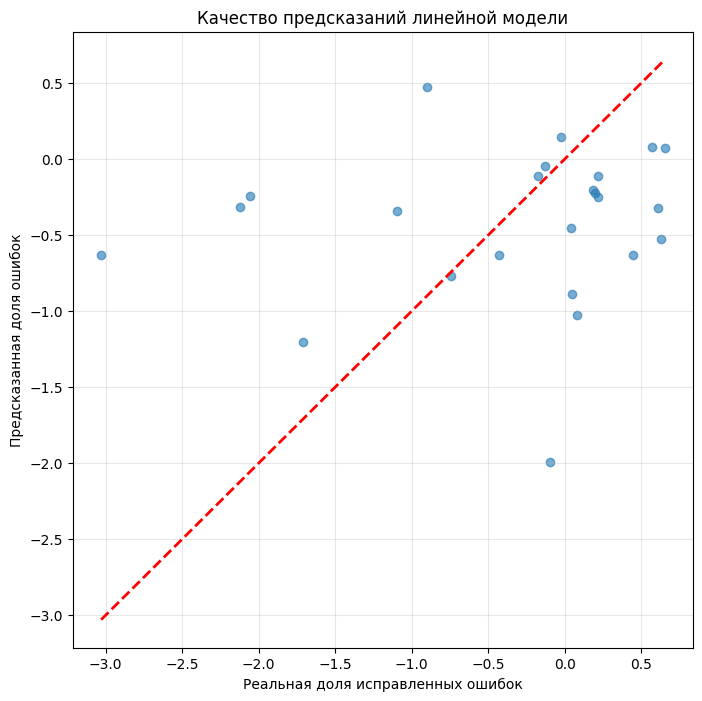

In [175]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [176]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.0
different_agreement: 0.0
PREF1: -0.187
PREF2: 0.131
ROOT1: -0.131
ROOT2: 0.847
LINK: -1.132
SUFF1: -0.083
SUFF2: -0.215
END: 0.046
POSTFIX: -0.2


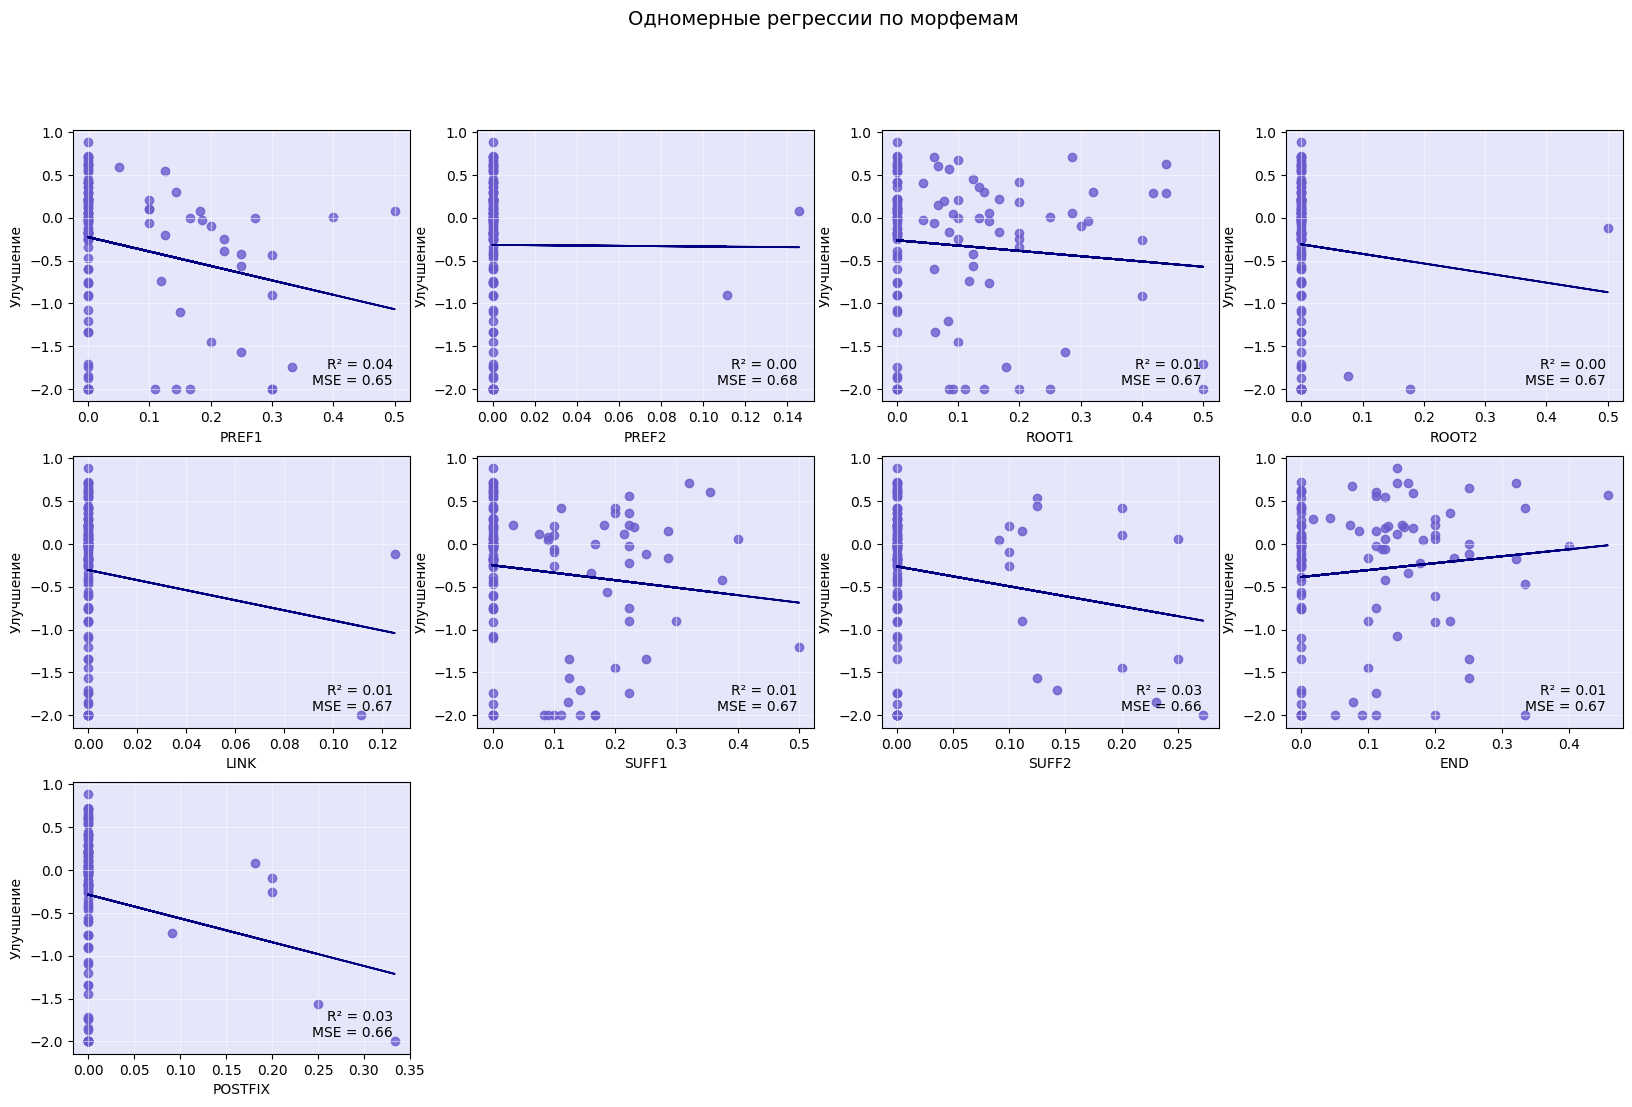

In [177]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Словенский

### True norm

In [181]:
results = regression_results('for_regression/true/sn_true.csv', 'sn', 't', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.09882116157555143, 1.0181491687810535)

In [182]:
df.to_csv(
    'linreg_ana/true_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

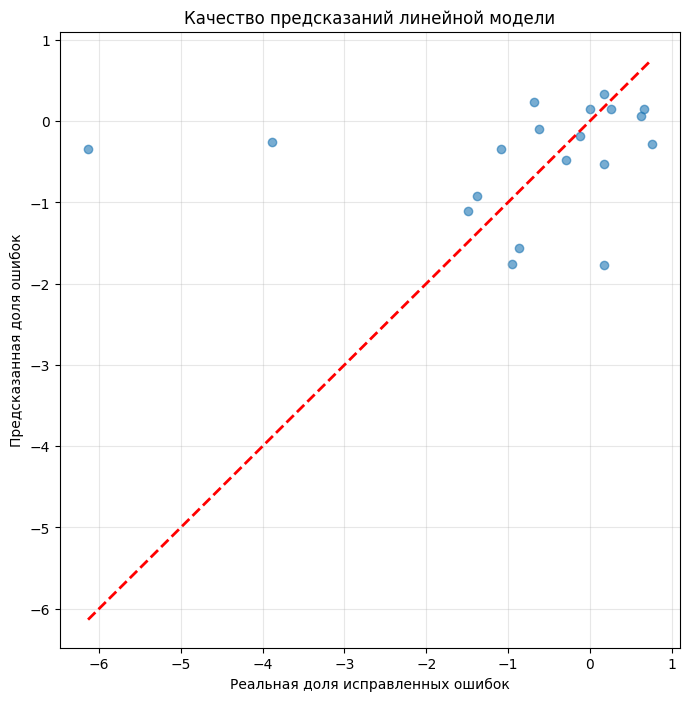

In [183]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [184]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

PREF1: -0.355
PREF2: 0.089
ROOT1: 0.046
ROOT2: 0.034
LINK: 0.034
SUFF1: -0.215
SUFF2: -0.135
SUFF3: 0.0
END: -0.037
POSTFIX: -0.043


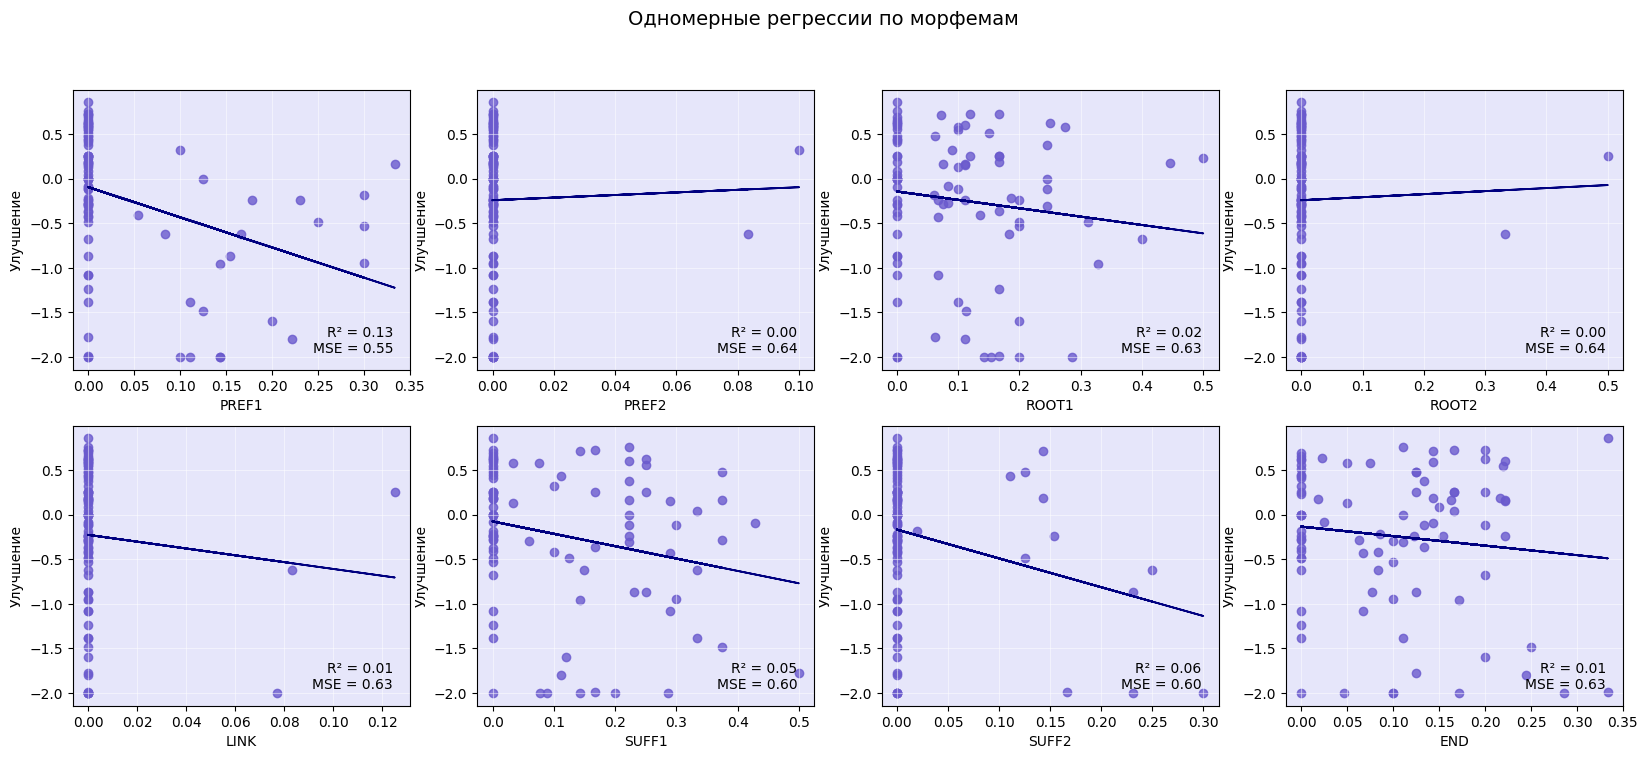

In [185]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Part norm

In [189]:
results = regression_results('for_regression/part/sn_part1.csv', 'sn', 'p', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-1.279414878826806, 0.8567740792564731)

In [190]:
df.to_csv(
    'linreg_ana/part_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

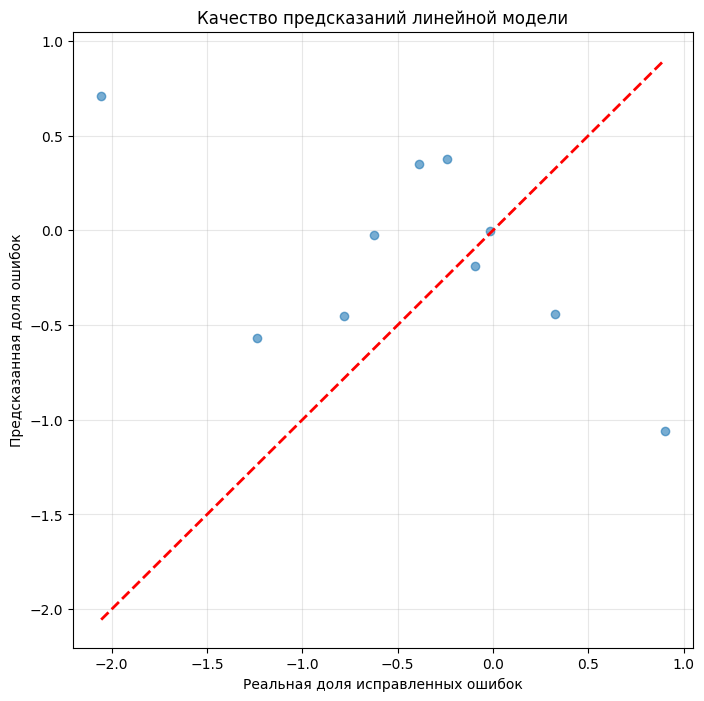

In [191]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [192]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: -0.383
PREF1: -0.329
ROOT1: 0.152
SUFF1: -0.227
SUFF2: 0.008
END: 0.297
POSTFIX: 0.094


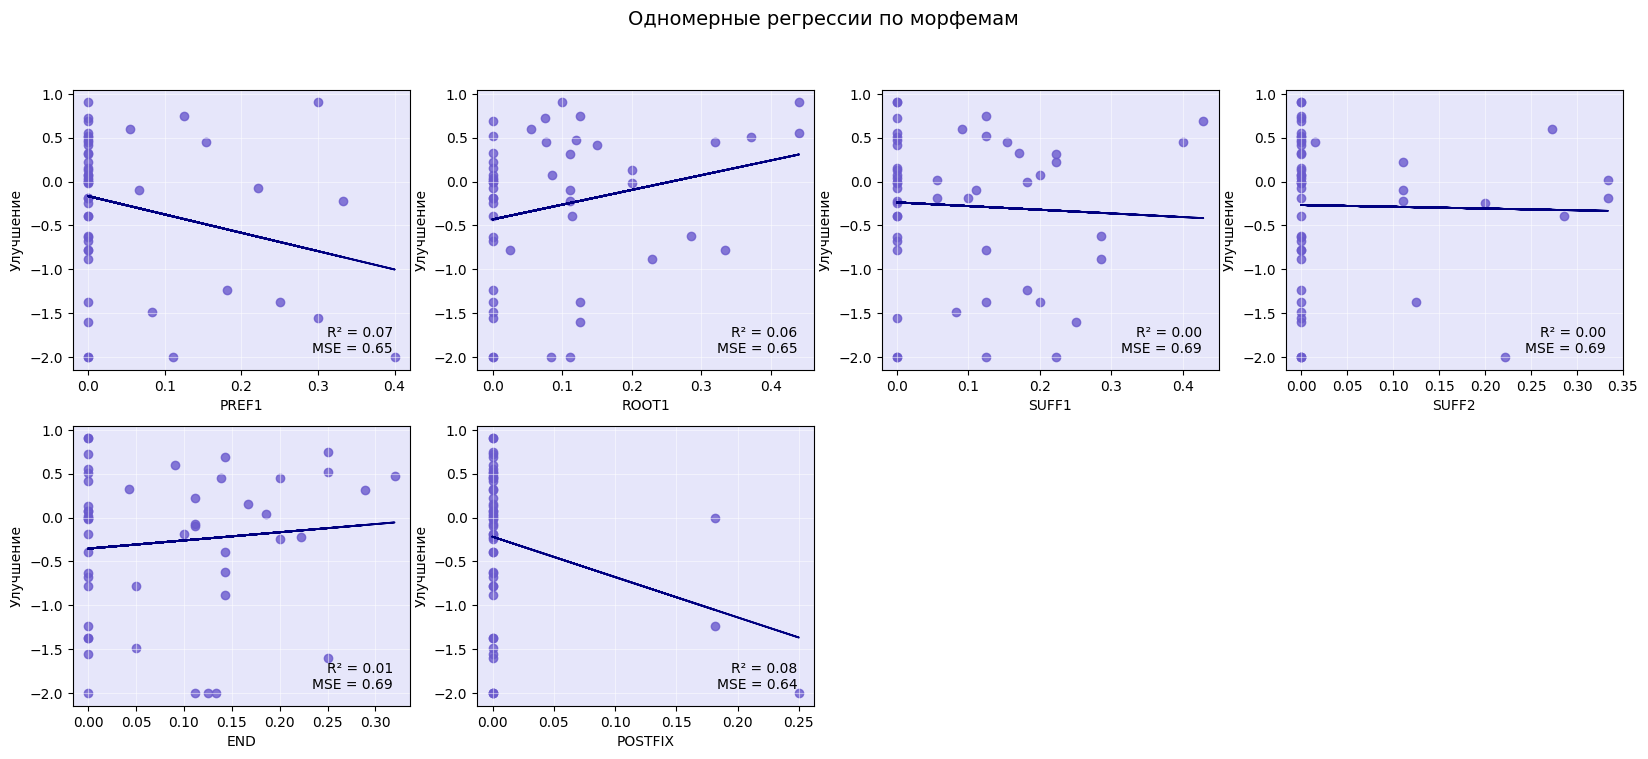

In [193]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

### Both norm

In [197]:
results = regression_results(df_both_n, 'sn', 'b', True)
df = results[2]
dff = results[4]
coef = results[3]
results[:2]

(-0.11258189218566117, 0.6899856771561055)

In [198]:
df.to_csv(
    'linreg_ana/both_norm/sn_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

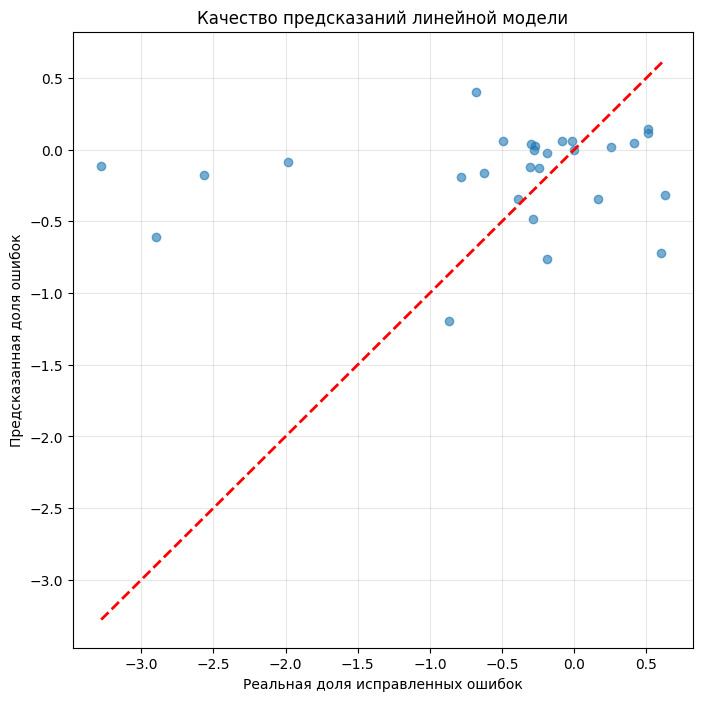

In [199]:
plt.figure(figsize=(8, 8))
plt.scatter(df['explained_mistakes'], df['pred'], alpha=0.6)
opop = df['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [200]:
for col, coef in zip(df.columns[1:-2], coef):
    print(f'{col}: {round(coef, 3)}')

different_agreement: -0.042
PREF1: -0.303
PREF2: 0.065
ROOT1: 0.037
ROOT2: 1.069
LINK: -1.158
SUFF1: -0.203
SUFF2: -0.13
SUFF3: -0.0
END: 0.124
POSTFIX: -0.133


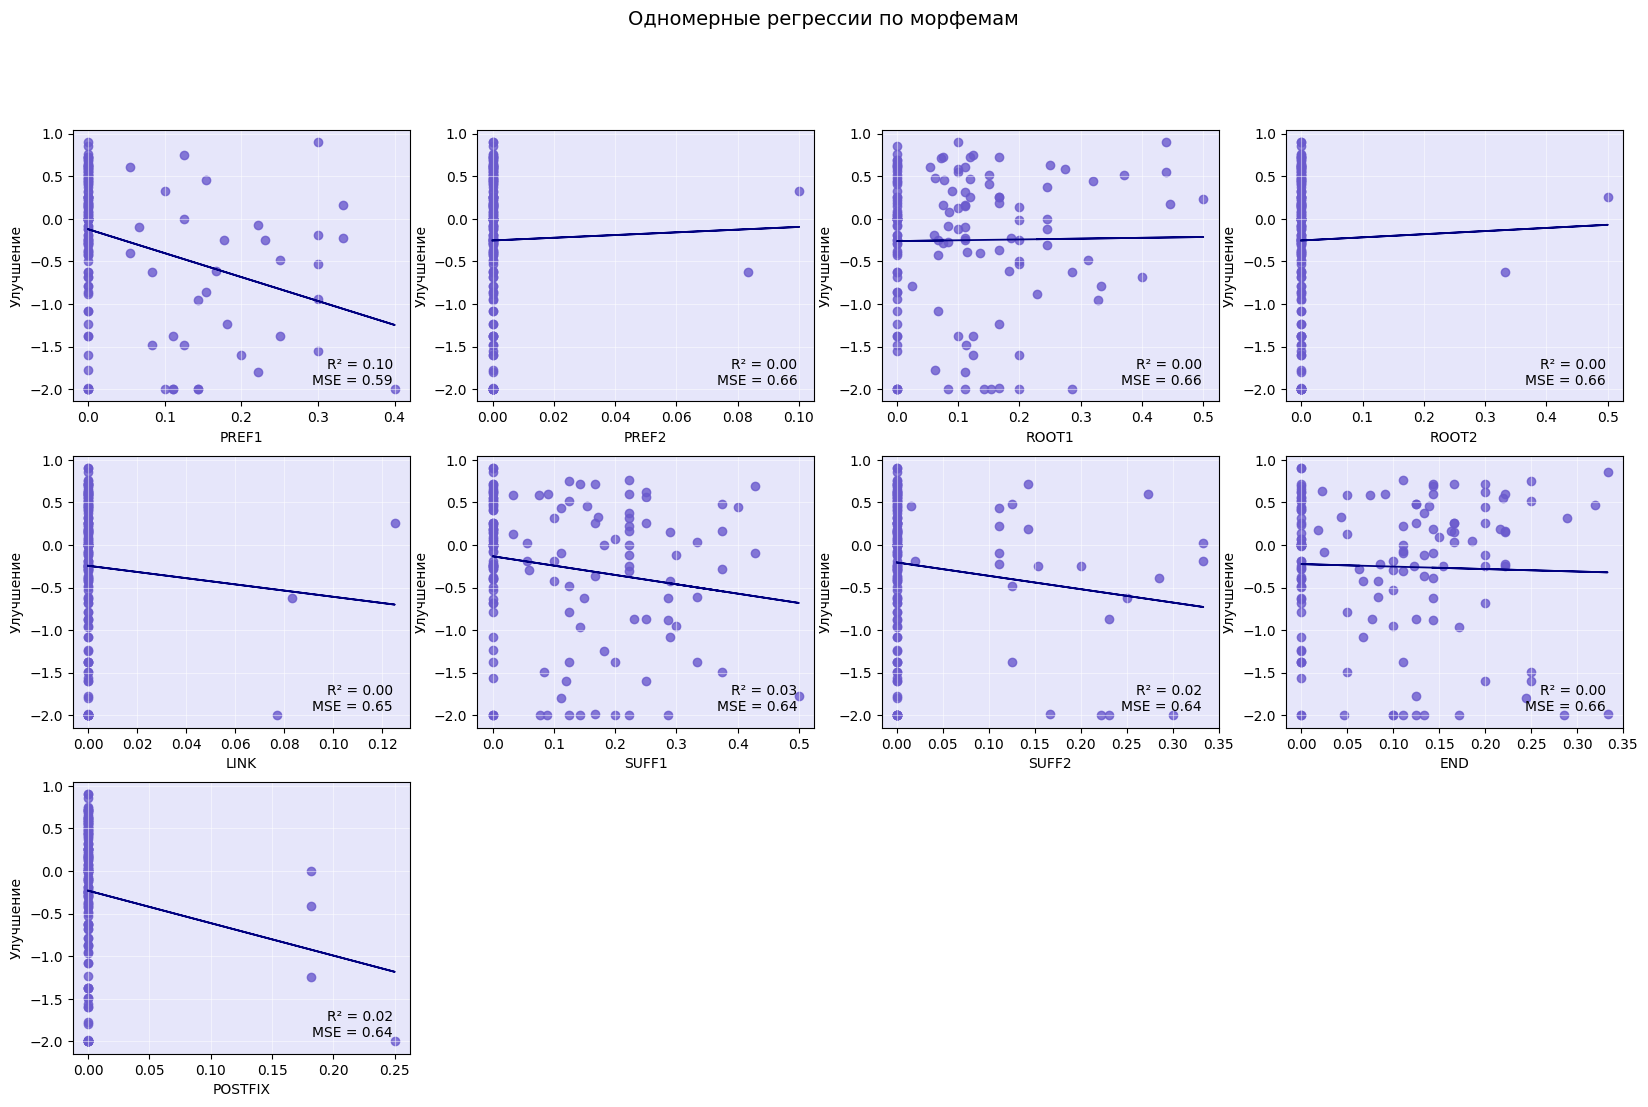

In [201]:
cols_for_plot = morpheme_cols + ['explained_mistakes']

df_combined = pd.concat([df, dff], ignore_index=True)
plot_df = df_combined[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col)
    ax.set_ylabel('Улучшение')
    

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Одномерные регрессии по морфемам', fontsize=14)
plt.show()

## Все языки true norm

In [205]:
df = df_all_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all_n = df_all_n.copy()
dff_all_n = dff_all_n.drop(test_indices)

df_all_n['pred'] = np.nan
df_all_n.loc[test_indices, 'pred'] = pred
df_all_n = df_all_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all_n

(0.6163522012578616,
 0.5555555555555556,
 0.704225352112676,
 0.6211180124223602,
 0.672730051387429,
 0.28960397577582375,
                                         pair  postfix_position  \
 2                     13, 'спиною', 'спиною'               0.0   
 7            113, 'осужденных', 'засуджених'               0.0   
 10                   117, 'весело', 'весело'               0.0   
 23                   140, 'морща', 'морщачи'               0.0   
 29                    29, 'столик', 'столик'               0.0   
 ..                                       ...               ...   
 781           532, 'мысли', 'misli', 'мисли'               0.0   
 782          533, 'вернет', 'vrnil', 'врнил'               0.0   
 789           612, 'вечер', 'večer', 'вечер'               0.0   
 790  619, 'написано', 'zapisano', 'записано'               0.0   
 791   623, 'подтвердить', 'trditi', 'трдити'               0.0   
 
      different_agreement  PREF1  PREF2     ROOT1  ROOT2  LINK     SU

In [206]:
df_all_n.to_csv(
    'linreg_ana/true_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

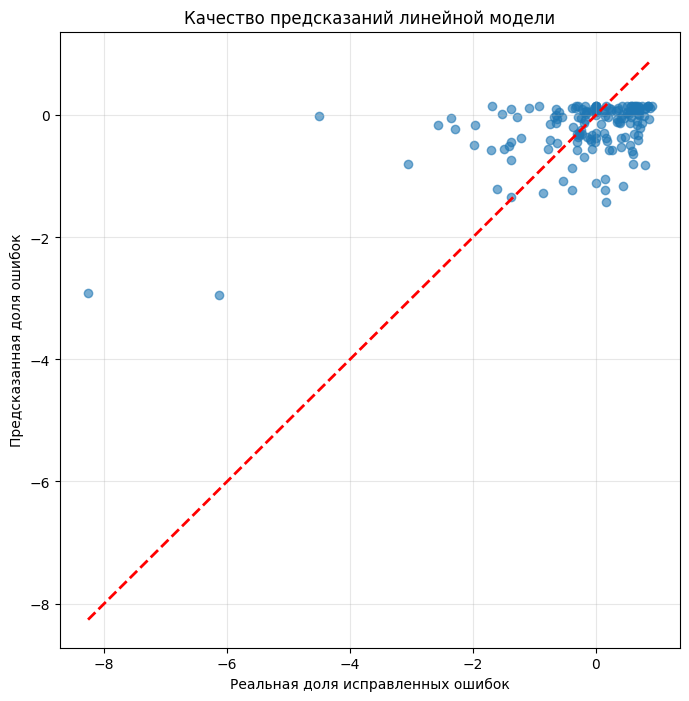

In [207]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all_n['explained_mistakes'], df_all_n['pred'], alpha=0.6)
opop = df_all_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [208]:
for col, coef in zip(df_all_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.041
different_agreement: 0.0
PREF1: -0.32
PREF2: 0.032
ROOT1: -0.083
ROOT2: 0.213
LINK: -0.382
SUFF1: -0.133
SUFF2: -0.078
SUFF3: -0.052
END: -0.031
POSTFIX: -0.018


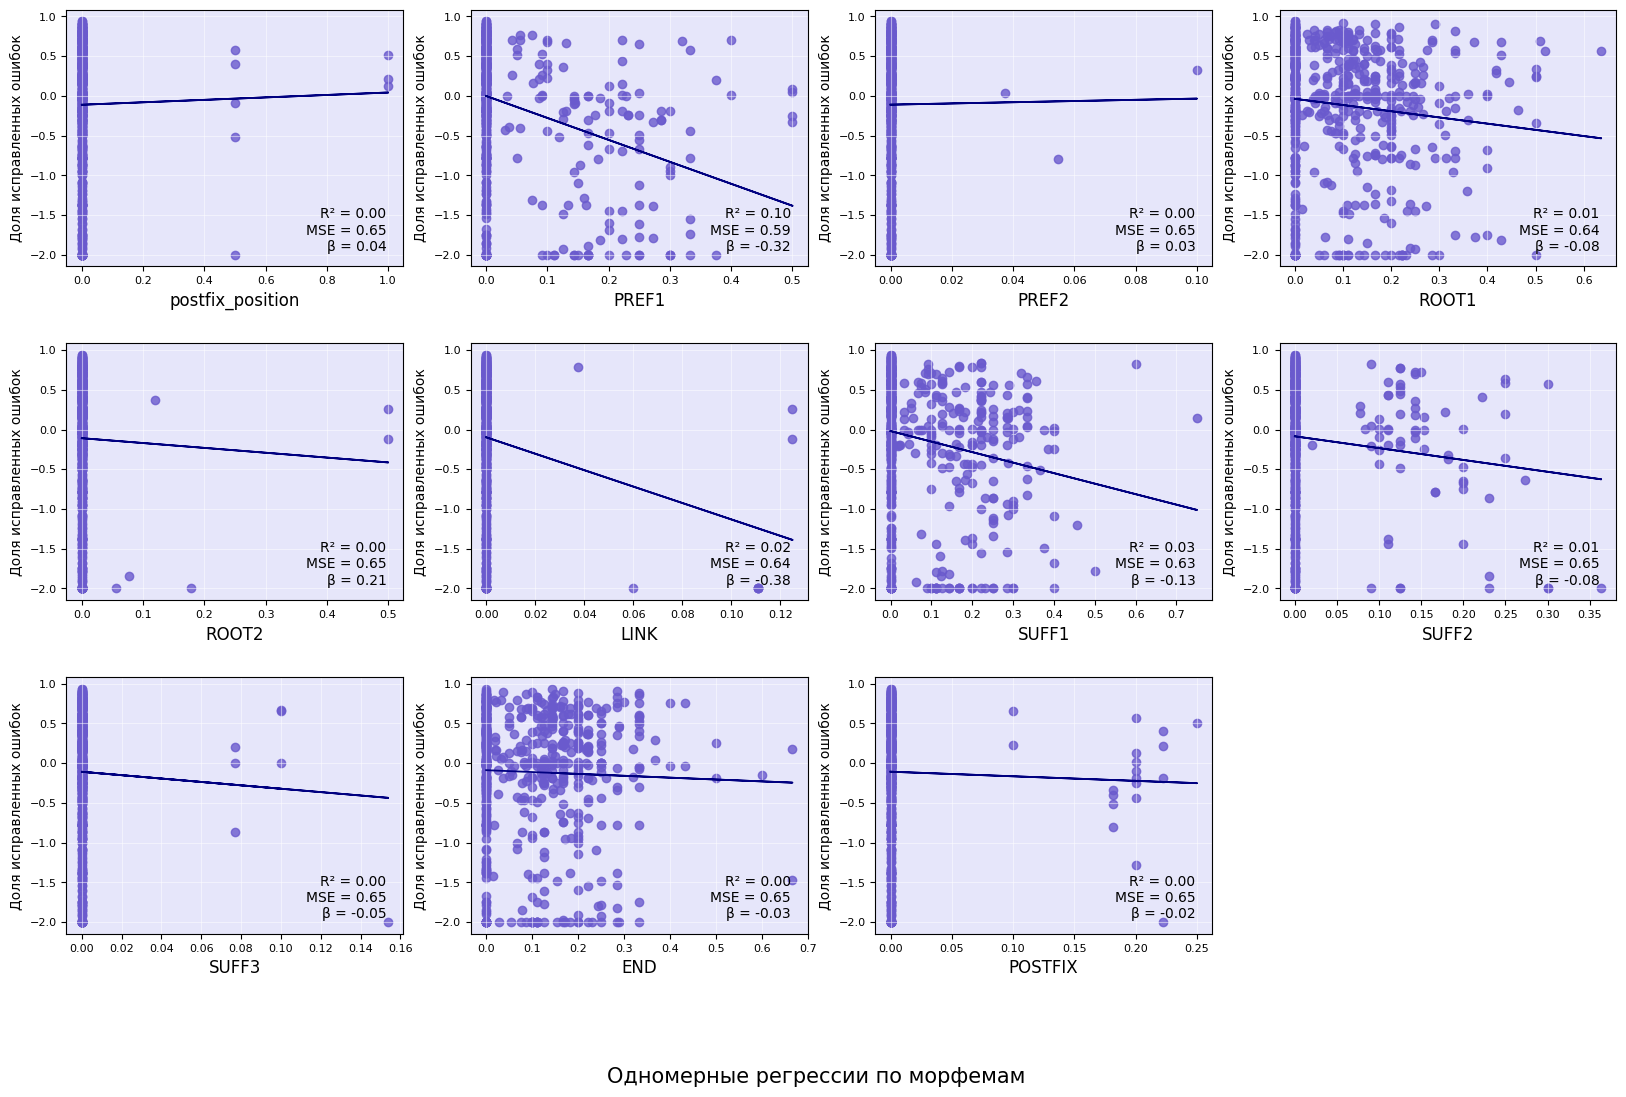

In [209]:
morpheme_cols = ['postfix_position', 'different_agreement', 'PREF1', 'PREF2', 'ROOT1', 'ROOT2', 'LINK', 
                 'SUFF1', 'SUFF2', 'SUFF3', 'END', 'POSTFIX']

coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

## Все языки part norm

In [213]:
df = df_all1_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all1_n = df_all1_n.copy()
dff_all1_n = dff_all1_n.drop(test_indices)

df_all1_n['pred'] = np.nan
df_all1_n.loc[test_indices, 'pred'] = pred
df_all1_n = df_all1_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all1_n

(0.5,
 0.5373134328358209,
 0.8571428571428571,
 0.6605504587155964,
 1.0087856261446717,
 -0.12545187981515205,
                                           pair  postfix_position  \
 0                    11, 'сходням', 'сходинок'               0.0   
 3                   111, 'сходням', 'сходинок'               0.0   
 5                    126, 'хлопчик', 'хлопчик'               0.0   
 9                  222, 'сделать', 'здійснити'               0.0   
 15                   318, 'сильною', 'сильною'               0.0   
 ..                                         ...               ...   
 353                525, 'пути', 'poti', 'поти'               0.0   
 355  62, 'потемнела', 'potemnela', 'потемнела'               0.0   
 360    624, 'поведали', 'povedali', 'поведали'               0.0   
 362       629, 'показывался', 'kazal', 'казал'               0.0   
 364                   631, 'был', 'bil', 'бил'               0.0   
 
      different_agreement     PREF1  PREF2  ROOT1  ROOT2 

In [214]:
df_all1_n.to_csv(
    'linreg_ana/part_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

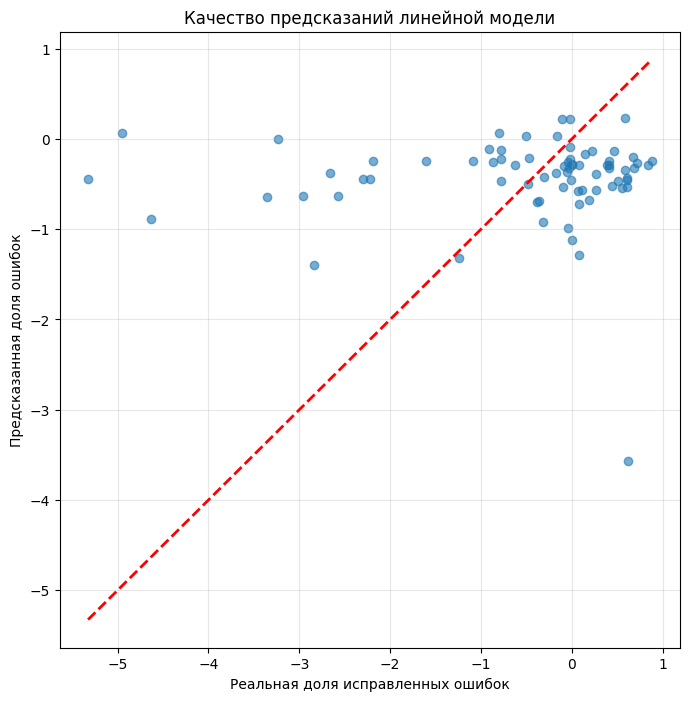

In [215]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all1_n['explained_mistakes'], df_all1_n['pred'], alpha=0.6)
opop = df_all1_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [216]:
for col, coef in zip(df_all1_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.071
different_agreement: -0.06
PREF1: -0.094
PREF2: -0.023
ROOT1: 0.038
ROOT2: 0.0
LINK: -0.248
SUFF1: -0.162
SUFF2: -0.029
SUFF3: 0.0
END: 0.145
POSTFIX: -0.171


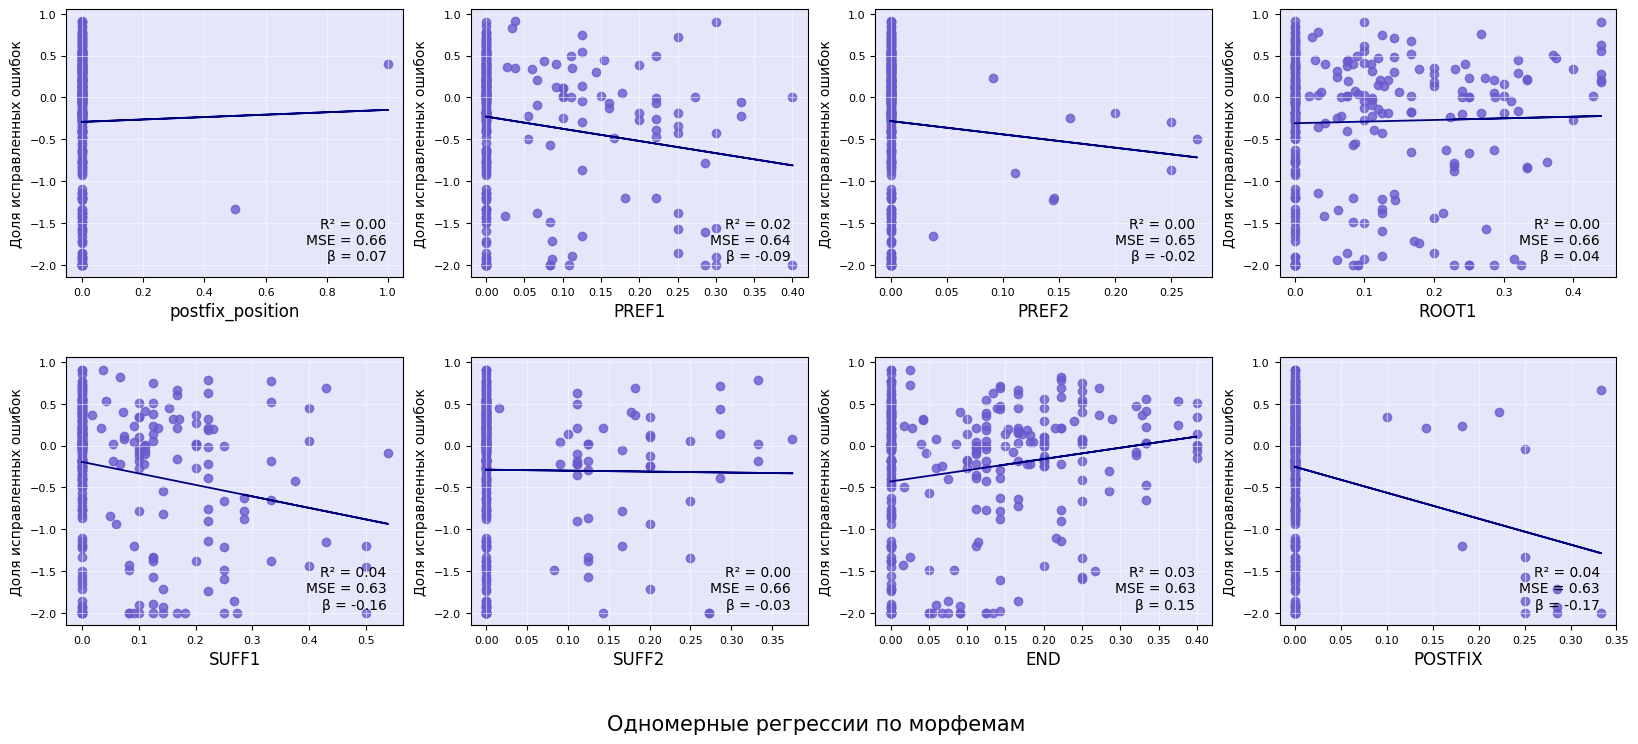

In [217]:
coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all1_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

## Все языки all norm

In [221]:
df = df_all2_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all2_n = df_all2_n.copy()
dff_all2_n = dff_all2_n.drop(test_indices)

df_all2_n['pred'] = np.nan
df_all2_n.loc[test_indices, 'pred'] = pred
df_all2_n = df_all2_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all2_n

(0.5622317596566524,
 0.5235294117647059,
 0.8090909090909091,
 0.6357142857142857,
 0.7417856601277527,
 0.16149997262649984,
                                       pair  postfix_position  \
 3                   14, 'финики', 'фініки'               0.0   
 10                 117, 'весело', 'весело'               0.0   
 23                 140, 'морща', 'морщачи'               0.0   
 30         210, 'обдумывать', 'обдумувати'               0.0   
 31      214, 'сегодняшний', 'сьогоднішній'               0.0   
 ...                                    ...               ...   
 1138   420, 'ранено', 'ranjema', 'ранйема'               0.0   
 1146    514, 'грозной', 'grozna', 'грозна'               0.0   
 1152        66, 'люди', 'ljudje', 'лйудйе'               0.0   
 1153  618, 'ответил', 'odvrnil', 'одврнил'               0.0   
 1160  633, 'скрытно', 'skrivaj', 'скривай'               0.0   
 
       different_agreement  PREF1  PREF2     ROOT1  ROOT2  LINK     SUFF1  \
 3            

In [222]:
df_all2_n.to_csv(
    'linreg_ana/both_norm/all_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

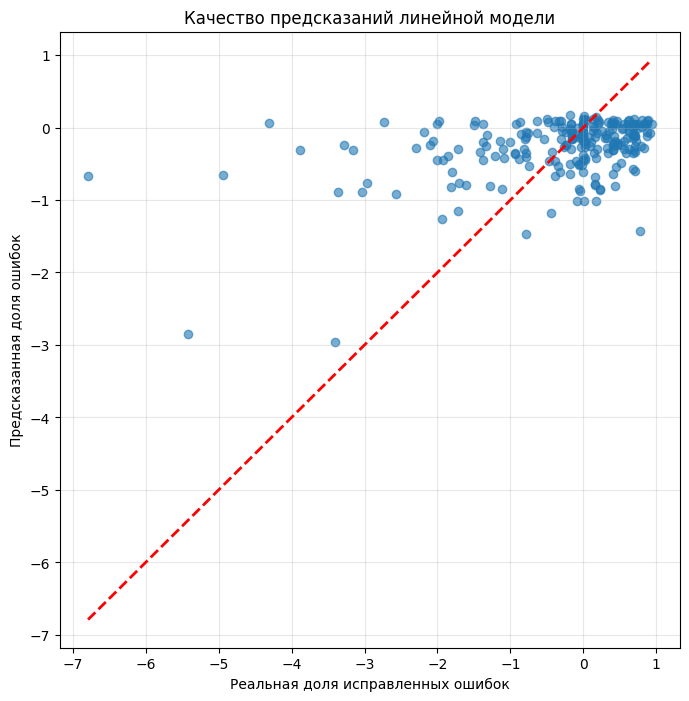

In [223]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all2_n['explained_mistakes'], df_all2_n['pred'], alpha=0.6)
opop = df_all2_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [224]:
for col, coef in zip(df_all2_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

postfix_position: 0.068
different_agreement: -0.034
PREF1: -0.203
PREF2: -0.03
ROOT1: -0.088
ROOT2: 0.279
LINK: -0.437
SUFF1: -0.139
SUFF2: -0.111
SUFF3: 0.045
END: 0.029
POSTFIX: -0.099


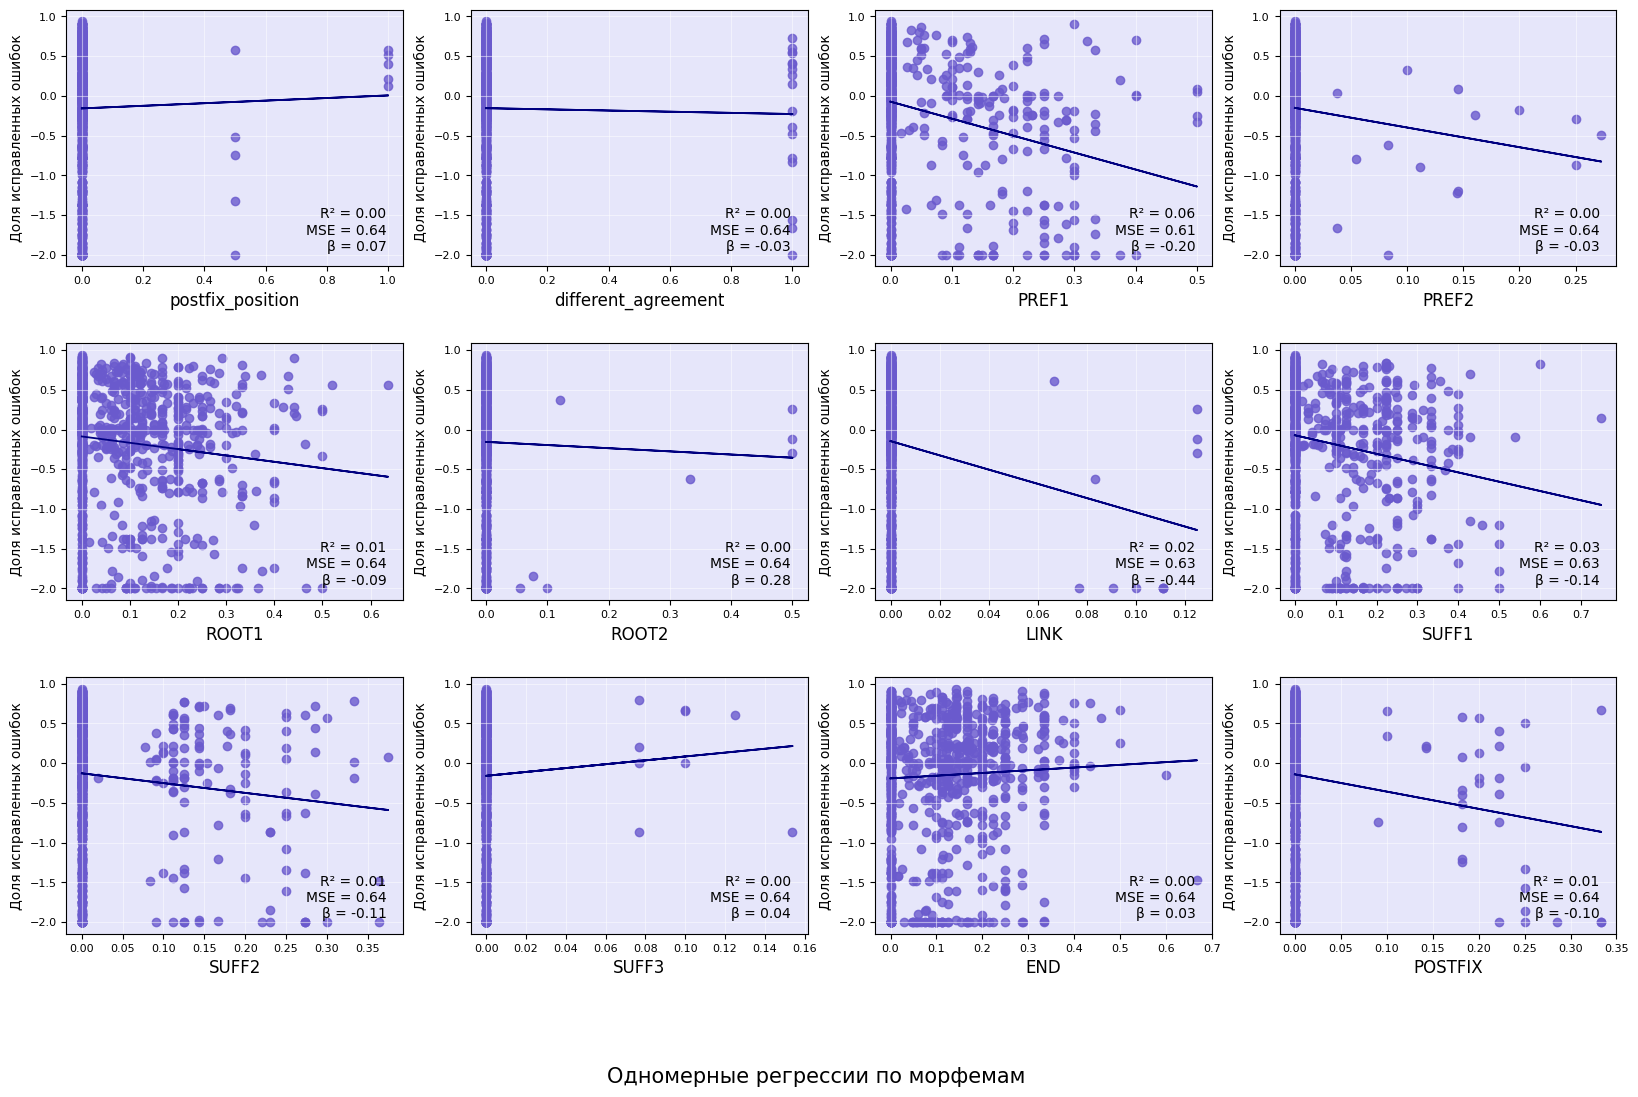

In [225]:
coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all2_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2 or col == 'different_agreement':
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

## Все языки true norm + 1.0 на язык

In [229]:
langs = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_colors = {
    'ukr': '#1f77b4',  # синий
    'bel': '#ff7f0e',  # оранжевый
    'bg':  '#2ca02c',  # зелёный
    'sb':  '#d62728',  # красный
    'pol': '#9467bd',  # фиолетовый
    'cz':  '#8c564b',  # коричневый
    'sk':  '#e377c2',  # розовый
    'sn':  '#7f7f7f',  # серый
}

In [230]:
df = df_all_langs_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all_langs_n = df_all_langs_n.copy()
dff_all_langs_n = dff_all_langs_n.drop(test_indices)

df_all_langs_n['pred'] = np.nan
df_all_langs_n.loc[test_indices, 'pred'] = pred
df_all_langs_n = df_all_langs_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all_langs_n

(0.5849056603773585,
 0.5238095238095238,
 0.7746478873239436,
 0.625,
 0.6868943412726141,
 0.25353960143870113,
                                         pair  ukr  bel   bg   sb  pol   cz  \
 2                     13, 'спиною', 'спиною'  1.0  0.0  0.0  0.0  0.0  0.0   
 7            113, 'осужденных', 'засуджених'  1.0  0.0  0.0  0.0  0.0  0.0   
 10                   117, 'весело', 'весело'  1.0  0.0  0.0  0.0  0.0  0.0   
 23                   140, 'морща', 'морщачи'  1.0  0.0  0.0  0.0  0.0  0.0   
 29                    29, 'столик', 'столик'  1.0  0.0  0.0  0.0  0.0  0.0   
 ..                                       ...  ...  ...  ...  ...  ...  ...   
 781           532, 'мысли', 'misli', 'мисли'  0.0  0.0  0.0  0.0  0.0  0.0   
 782          533, 'вернет', 'vrnil', 'врнил'  0.0  0.0  0.0  0.0  0.0  0.0   
 789           612, 'вечер', 'večer', 'вечер'  0.0  0.0  0.0  0.0  0.0  0.0   
 790  619, 'написано', 'zapisano', 'записано'  0.0  0.0  0.0  0.0  0.0  0.0   
 791   623, 'подт

In [231]:
df_all_langs_n.to_csv(
    'linreg_ana/true_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

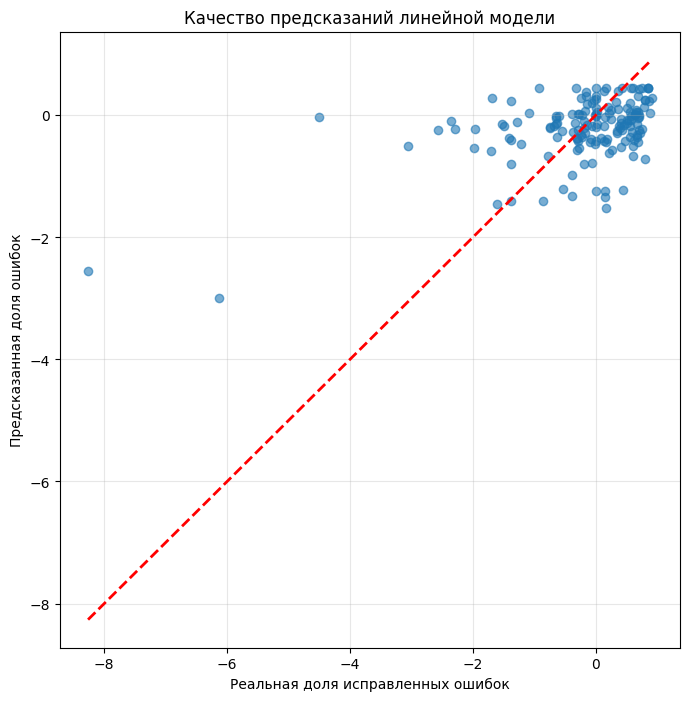

In [232]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all_langs_n['explained_mistakes'], df_all_langs_n['pred'], alpha=0.6)
opop = df_all_langs_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [233]:
for col, coef in zip(df_all_langs_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

ukr: 0.113
bel: 0.058
bg: -0.029
sb: -0.074
pol: -0.004
cz: -0.041
sk: -0.017
sn: -0.032
postfix_position: 0.041
different_agreement: 0.0
PREF1: -0.326
PREF2: 0.039
ROOT1: -0.077
ROOT2: 0.218
LINK: -0.381
SUFF1: -0.118
SUFF2: -0.067
SUFF3: -0.059
END: -0.02
POSTFIX: -0.011


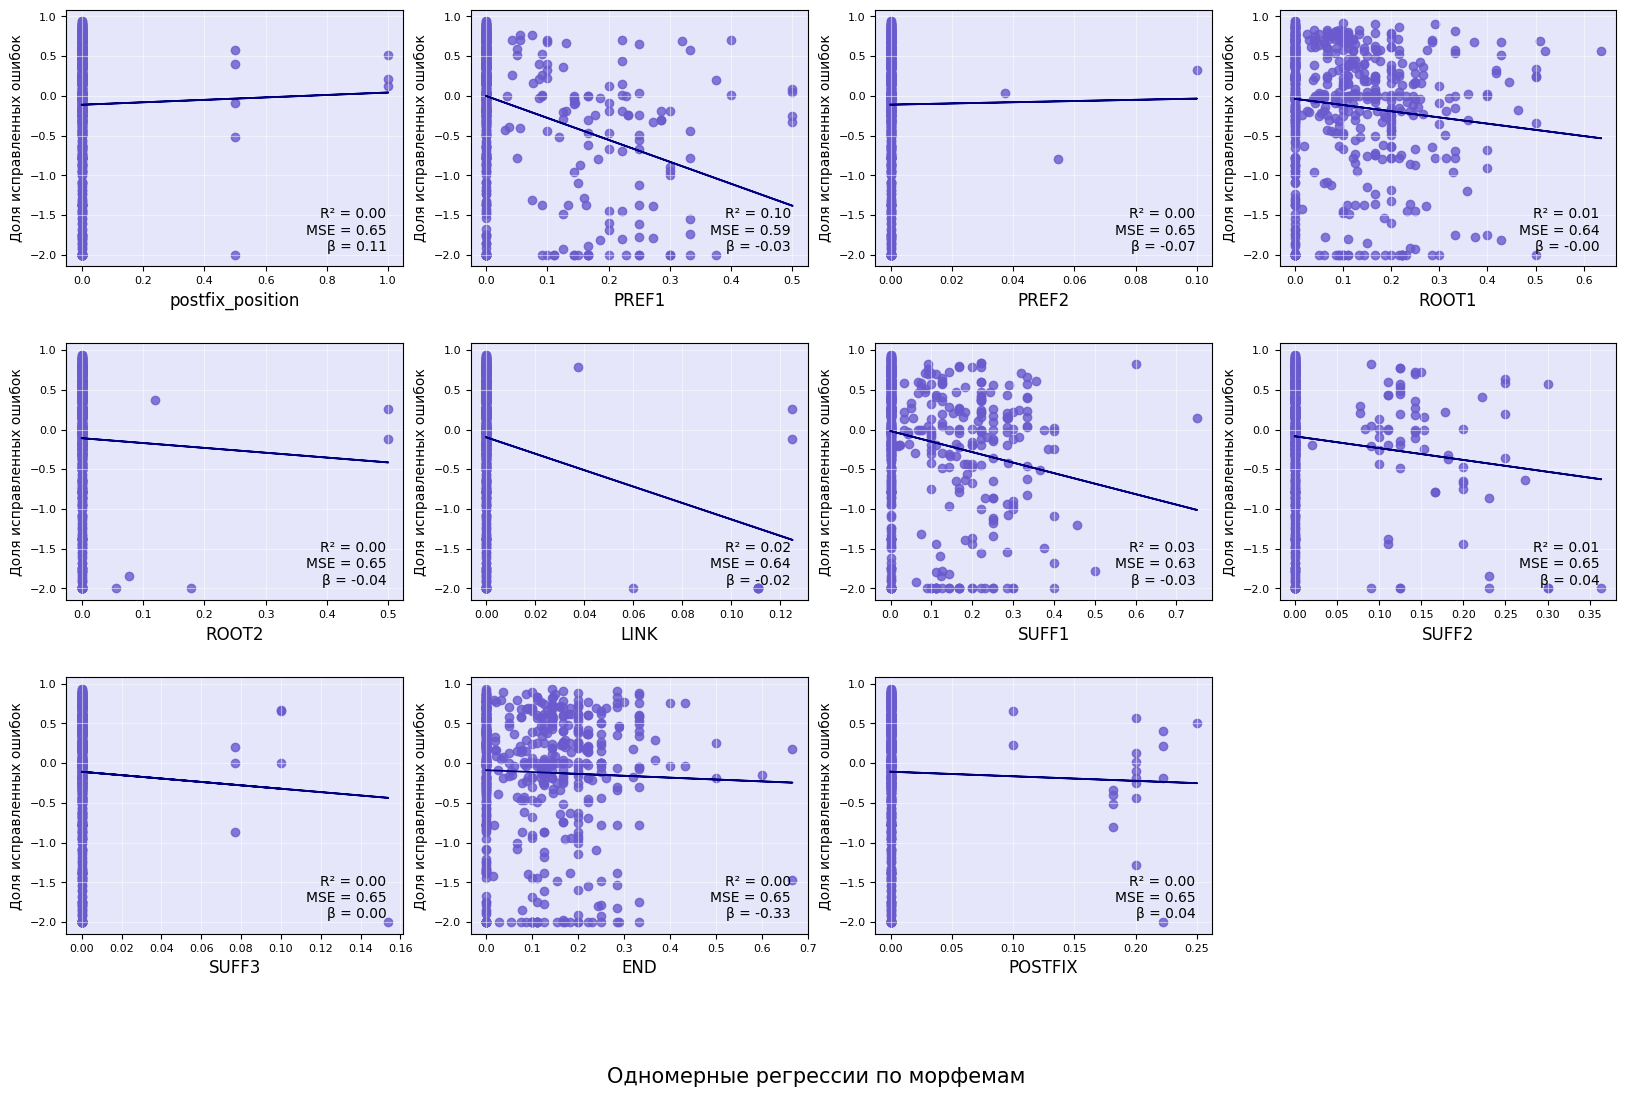

In [234]:
coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all_langs_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

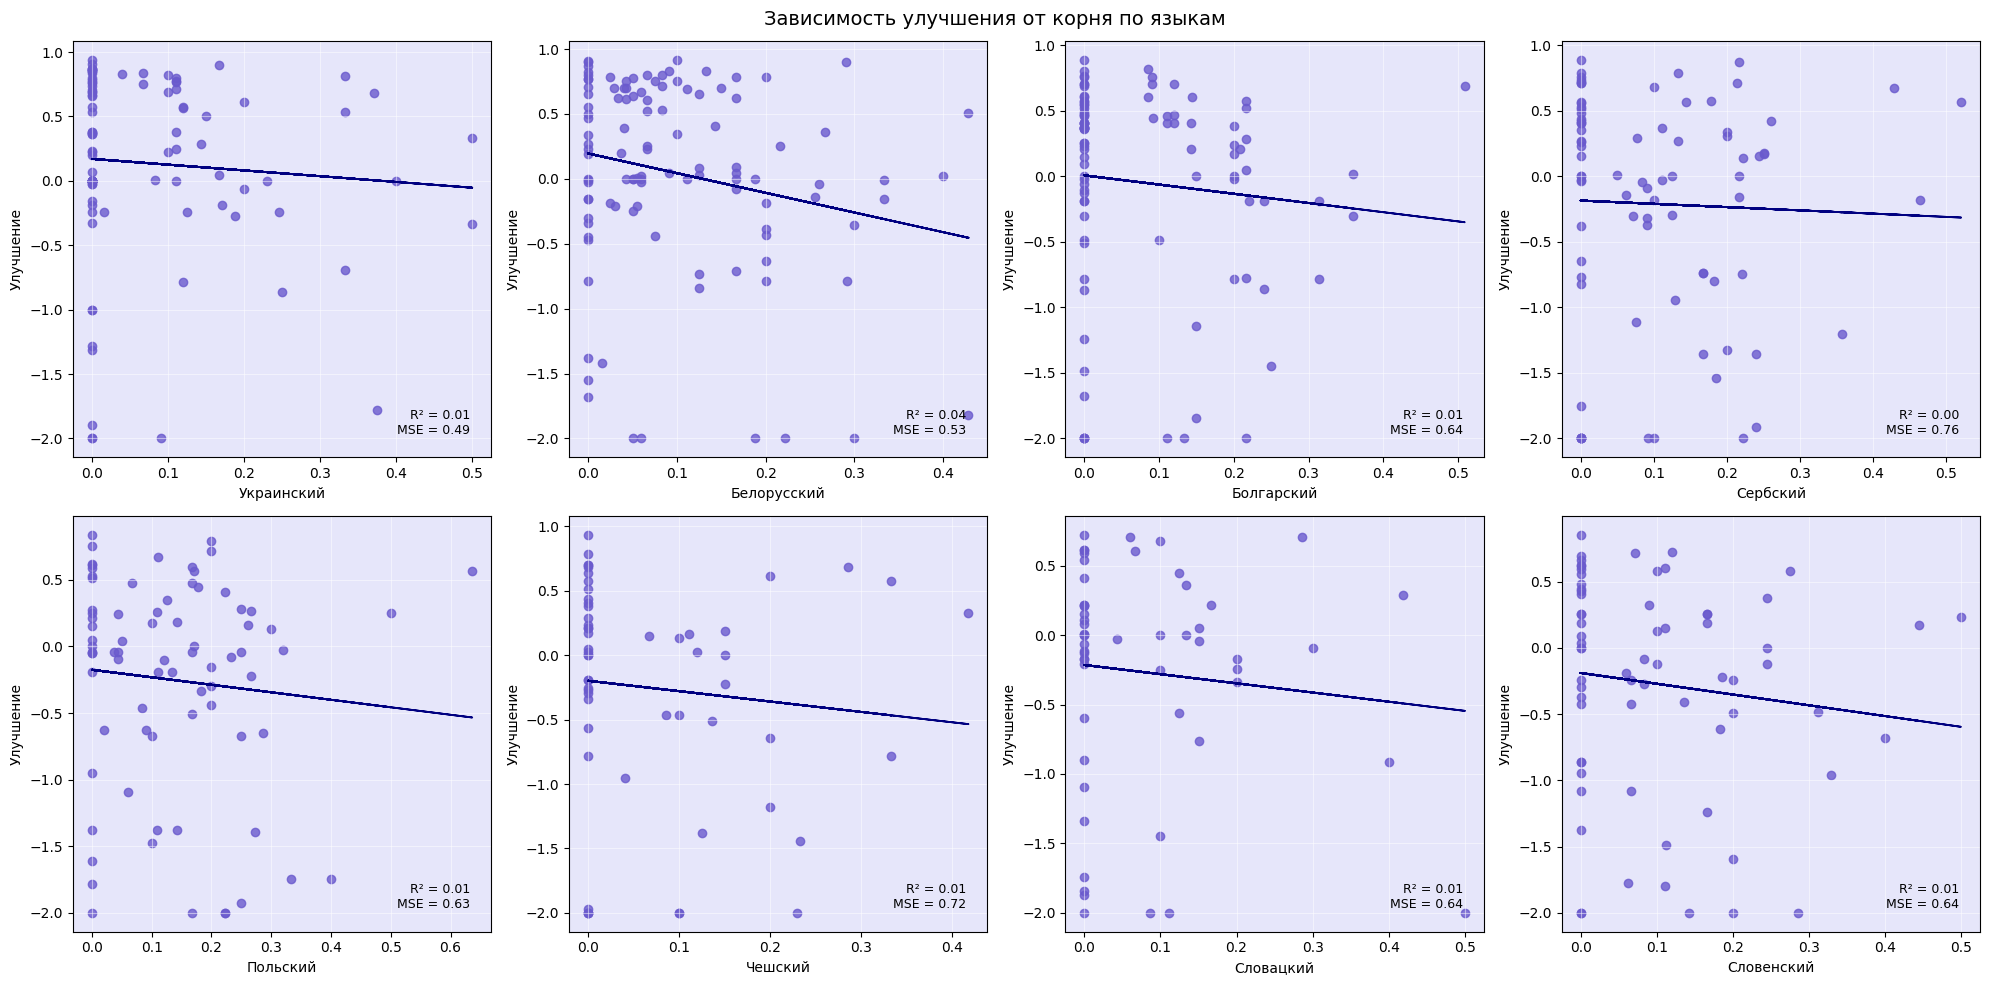

In [235]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'ROOT1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs_n[cols_for_plot].copy()

for i, lang in enumerate(languages):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        mse = np.mean((y - y_pred) ** 2)
        
        ax.scatter(x, y, alpha=0.8, color='slateblue')
        ax.plot(x, y_pred, '-', color='navy', lw=1.3)
        ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
                transform=ax.transAxes, fontsize=9, va='bottom', ha='right')
    
    ax.set_xlabel(f'{lang_dict[lang]}')
    ax.set_ylabel('Улучшение')
    ax.grid(True, alpha=0.5, color='white')

plt.suptitle(f'Зависимость улучшения от корня по языкам', fontsize=14)
plt.tight_layout()
plt.show()

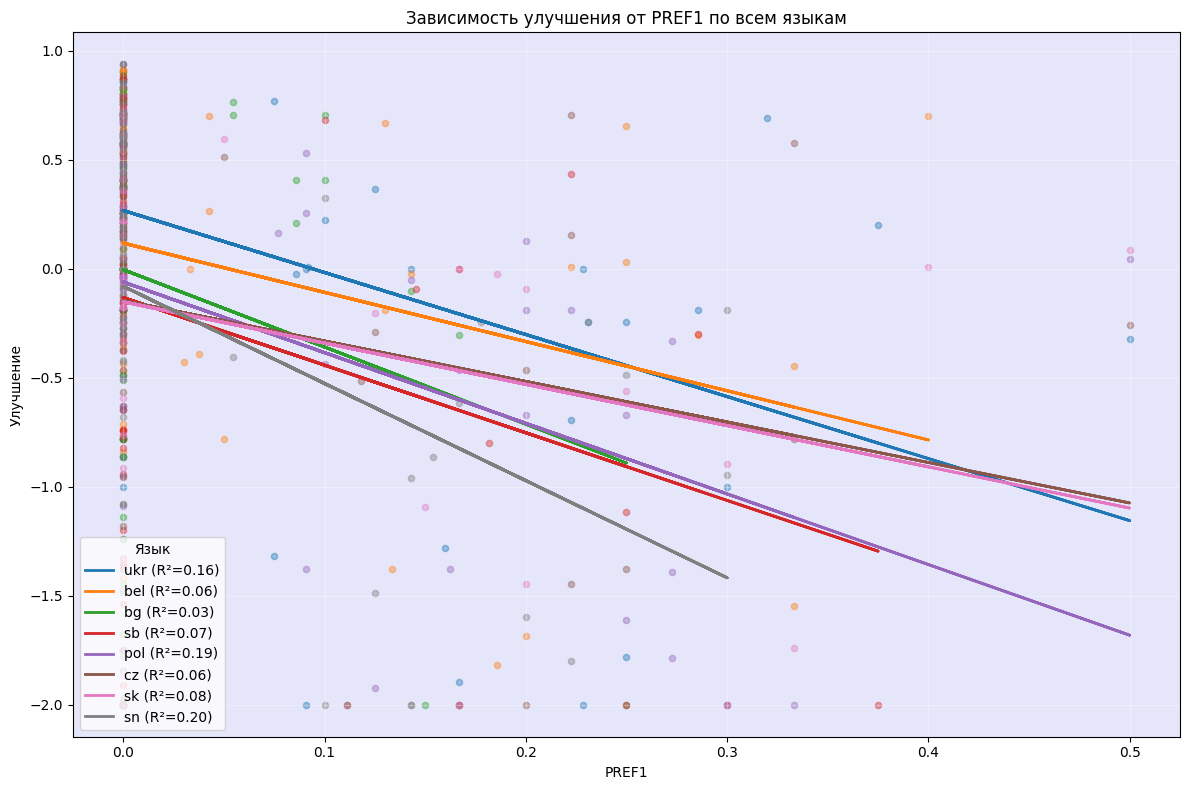

In [236]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('lavender')

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'PREF1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs_n[cols_for_plot].copy()

for lang, color in lang_colors.items():
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        ax.scatter(x, y, alpha=0.4, color=color, s=20)
        ax.plot(x, y_pred, '-', color=color, lw=2, label=f'{lang} (R²={r2:.2f})')

ax.set_xlabel(predictor)
ax.set_ylabel('Улучшение')
ax.legend(title='Язык', loc='lower left')
ax.grid(True, alpha=0.3, color='white')
plt.title(f'Зависимость улучшения от {predictor} по всем языкам')
plt.tight_layout()
plt.show()

## Все языки part norm + 1.0 на язык

In [240]:
df = df_all_langs1_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all_langs1_n = df_all_langs1_n.copy()
dff_all_langs1_n = dff_all_langs1_n.drop(test_indices)

df_all_langs1_n['pred'] = np.nan
df_all_langs1_n.loc[test_indices, 'pred'] = pred
df_all_langs1_n = df_all_langs1_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all_langs1_n

(0.527027027027027,
 0.5507246376811594,
 0.9047619047619048,
 0.6846846846846847,
 1.0035129420650486,
 -0.10596053757681911,
                                           pair  ukr  bel   bg   sb  pol   cz  \
 0                    11, 'сходням', 'сходинок'  1.0  0.0  0.0  0.0  0.0  0.0   
 3                   111, 'сходням', 'сходинок'  1.0  0.0  0.0  0.0  0.0  0.0   
 5                    126, 'хлопчик', 'хлопчик'  1.0  0.0  0.0  0.0  0.0  0.0   
 9                  222, 'сделать', 'здійснити'  1.0  0.0  0.0  0.0  0.0  0.0   
 15                   318, 'сильною', 'сильною'  1.0  0.0  0.0  0.0  0.0  0.0   
 ..                                         ...  ...  ...  ...  ...  ...  ...   
 353                525, 'пути', 'poti', 'поти'  0.0  0.0  0.0  0.0  0.0  0.0   
 355  62, 'потемнела', 'potemnela', 'потемнела'  0.0  0.0  0.0  0.0  0.0  0.0   
 360    624, 'поведали', 'povedali', 'поведали'  0.0  0.0  0.0  0.0  0.0  0.0   
 362       629, 'показывался', 'kazal', 'казал'  0.0  0.0  0.0 

In [241]:
df_all_langs1_n.to_csv(
    'linreg_ana/part_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

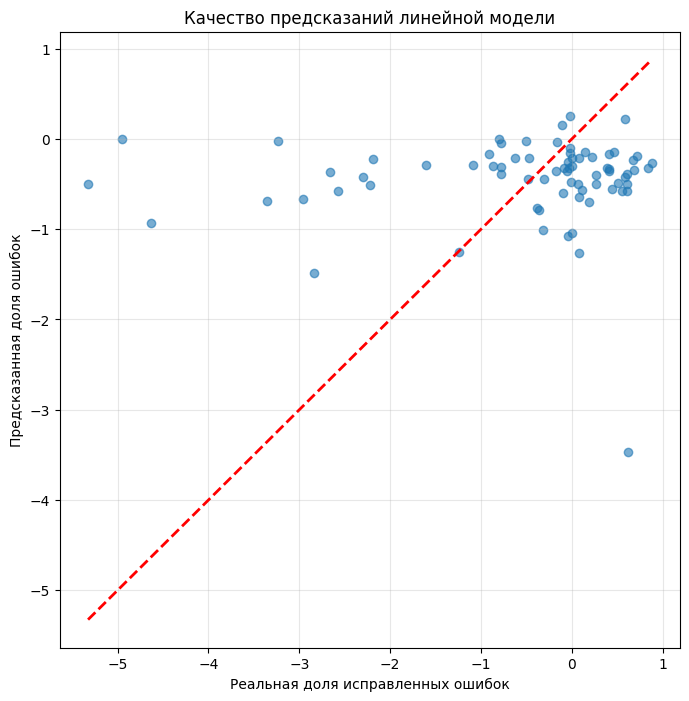

In [242]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all_langs1_n['explained_mistakes'], df_all_langs1_n['pred'], alpha=0.6)
opop = df_all_langs1_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [243]:
for col, coef in zip(df_all_langs1_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

ukr: -0.01
bel: -0.008
bg: -0.023
sb: 0.027
pol: -0.002
cz: -0.022
sk: 0.007
sn: 0.025
postfix_position: 0.071
different_agreement: -0.064
PREF1: -0.099
PREF2: -0.019
ROOT1: 0.034
ROOT2: 0.0
LINK: -0.246
SUFF1: -0.164
SUFF2: -0.033
SUFF3: 0.0
END: 0.145
POSTFIX: -0.173


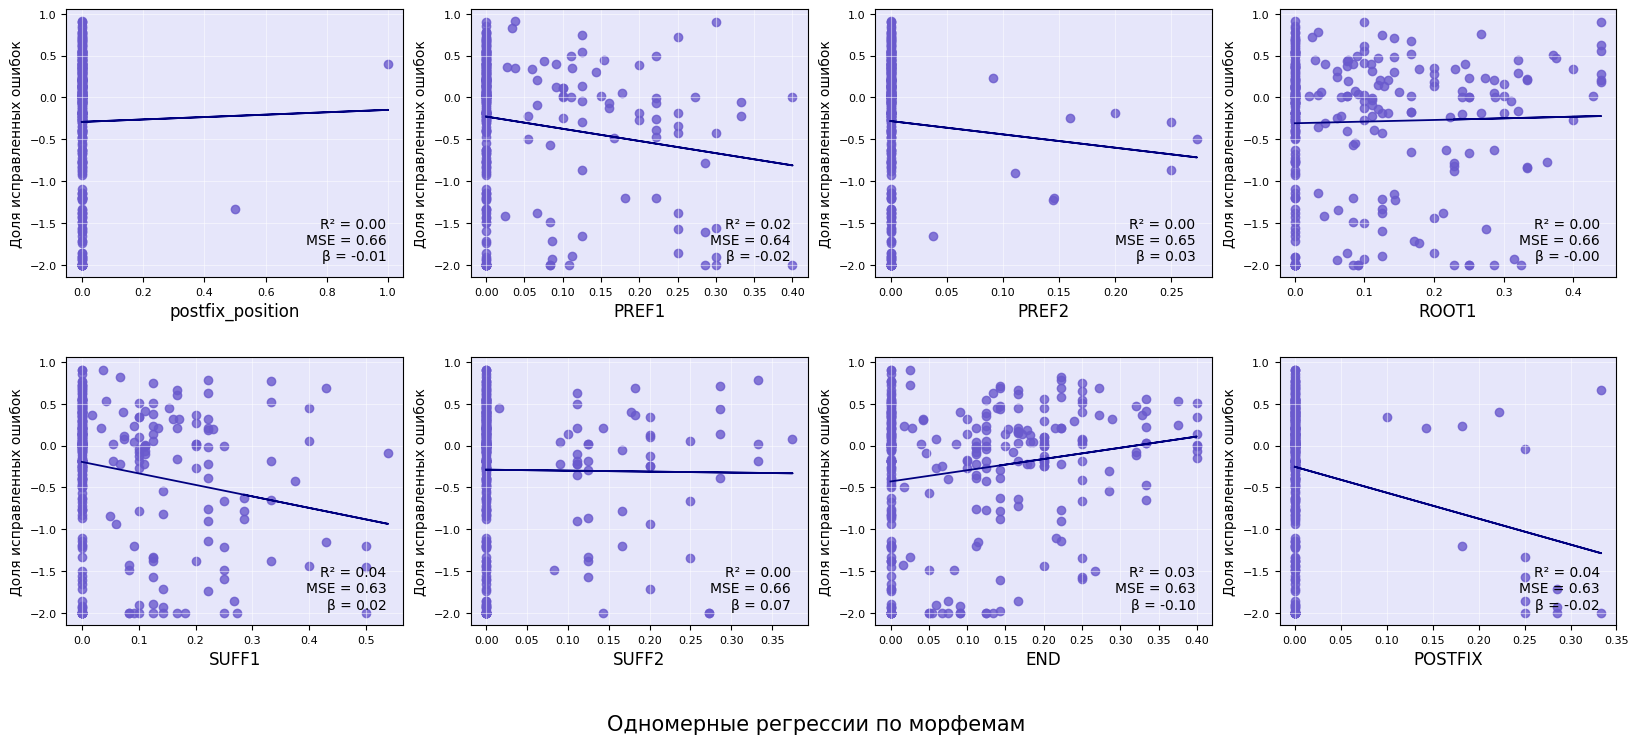

In [244]:
coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all_langs1_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

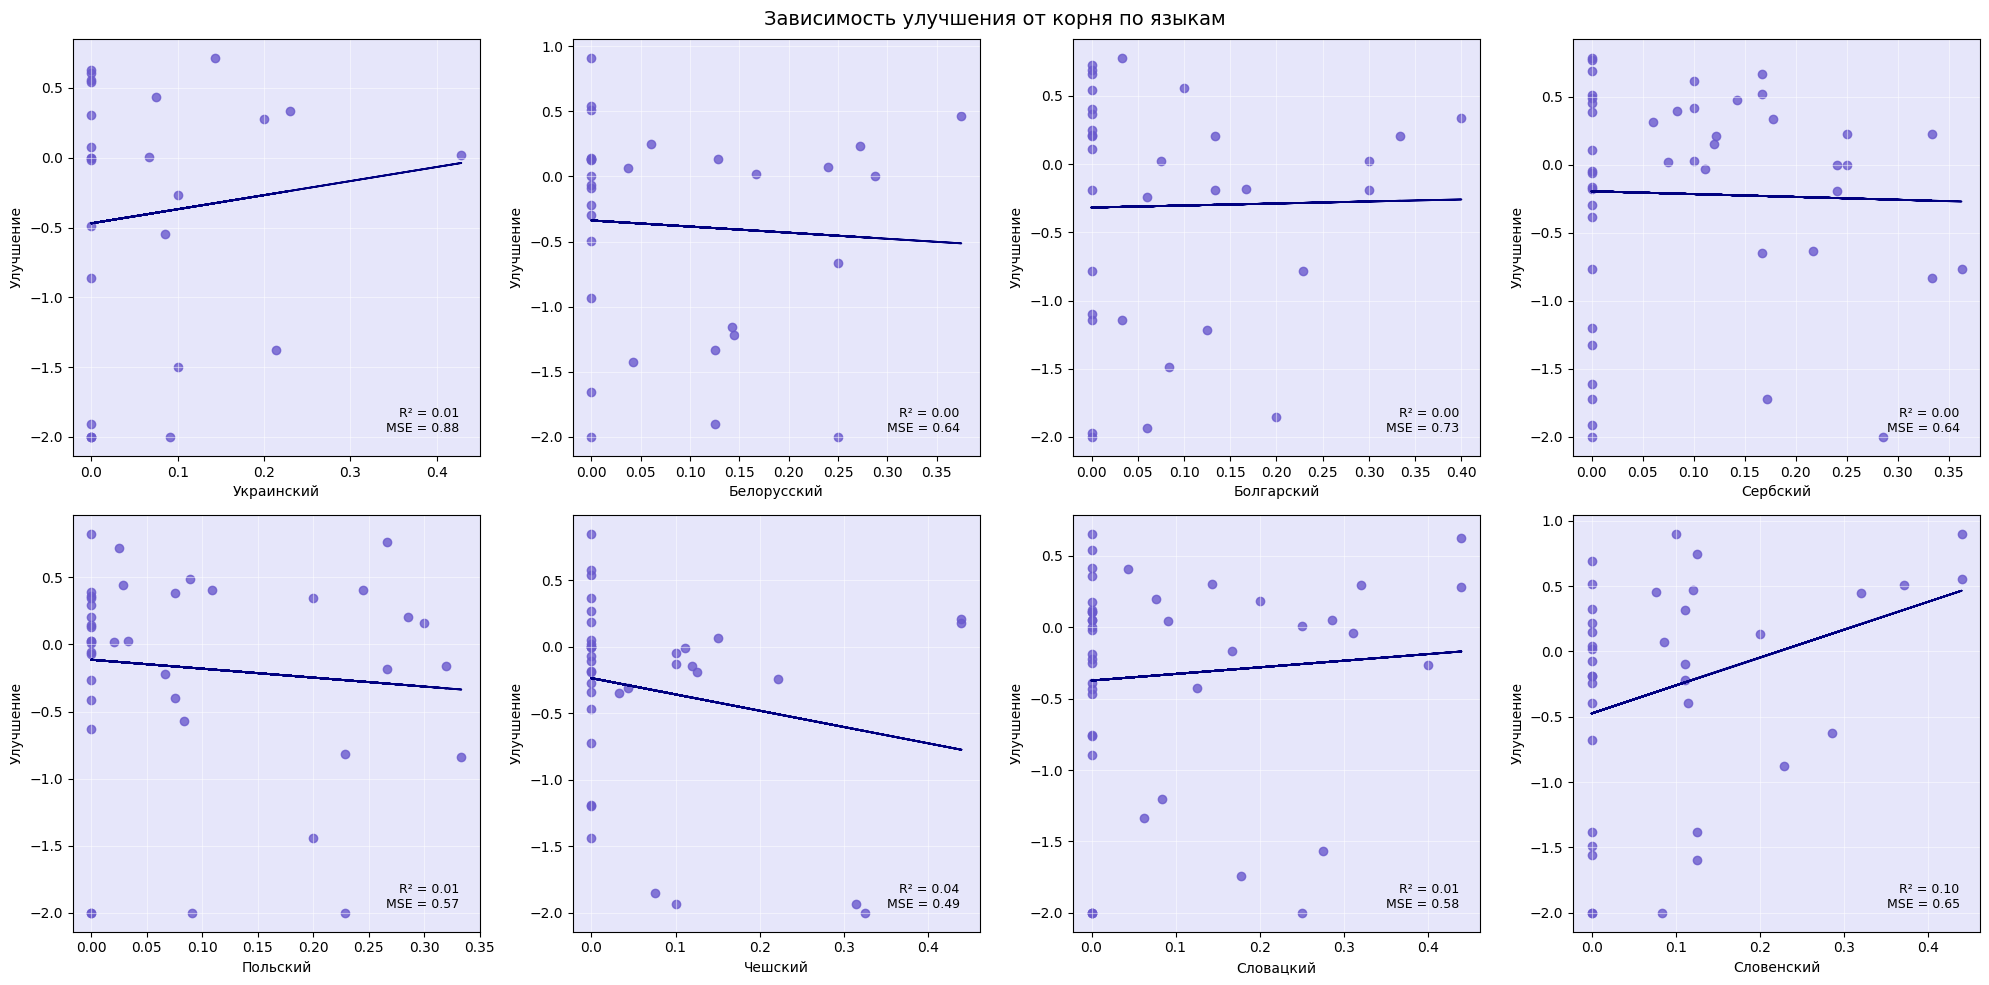

In [245]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'ROOT1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs1_n[cols_for_plot].copy()

for i, lang in enumerate(languages):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        mse = np.mean((y - y_pred) ** 2)
        
        ax.scatter(x, y, alpha=0.8, color='slateblue')
        ax.plot(x, y_pred, '-', color='navy', lw=1.3)
        ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
                transform=ax.transAxes, fontsize=9, va='bottom', ha='right')
    
    ax.set_xlabel(f'{lang_dict[lang]}')
    ax.set_ylabel('Улучшение')
    ax.grid(True, alpha=0.5, color='white')

plt.suptitle(f'Зависимость улучшения от корня по языкам', fontsize=14)
plt.tight_layout()
plt.show()

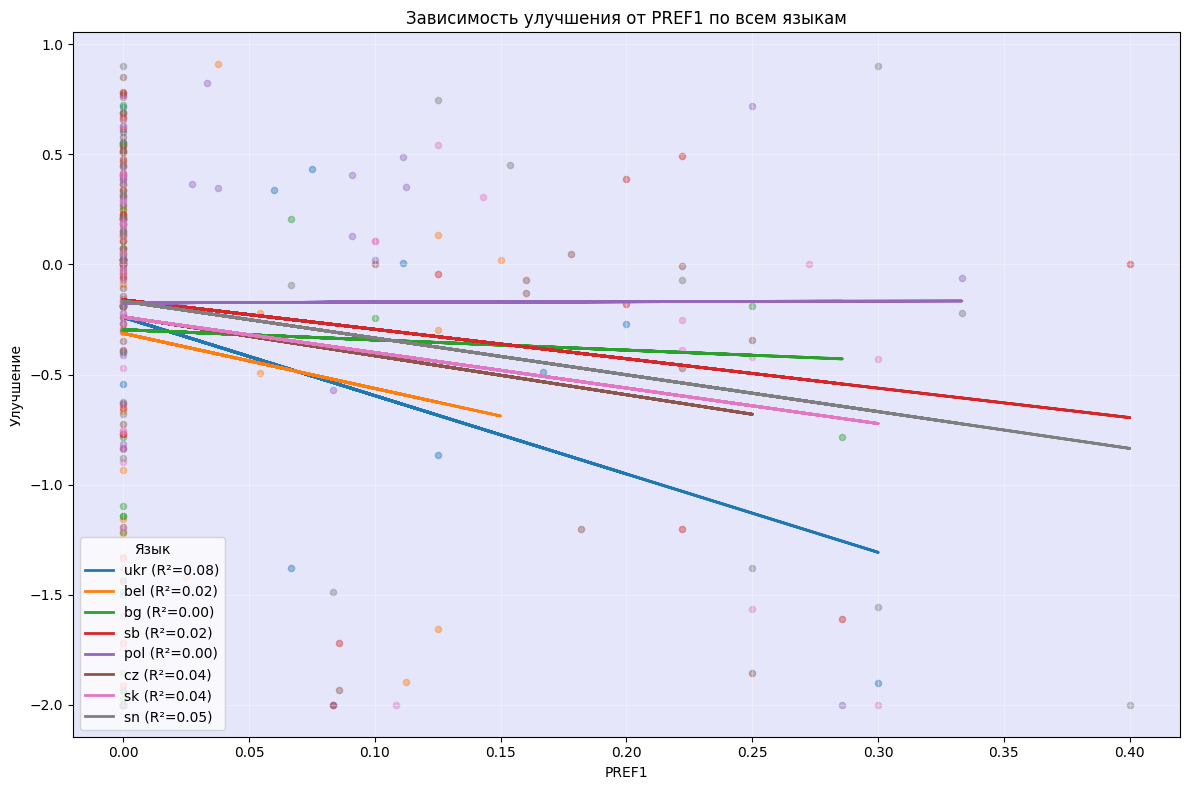

In [246]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('lavender')

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'PREF1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs1_n[cols_for_plot].copy()

for lang, color in lang_colors.items():
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        ax.scatter(x, y, alpha=0.4, color=color, s=20)
        ax.plot(x, y_pred, '-', color=color, lw=2, label=f'{lang} (R²={r2:.2f})')

ax.set_xlabel(predictor)
ax.set_ylabel('Улучшение')
ax.legend(title='Язык', loc='lower left')
ax.grid(True, alpha=0.3, color='white')
plt.title(f'Зависимость улучшения от {predictor} по всем языкам')
plt.tight_layout()
plt.show()

## Все языки all norm + 1.0 на язык

In [250]:
df = df_all_langs2_n.drop('pair', axis=1)

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_indices = train.index
test_indices = test.index

X_train, y_train = train.loc[:, :'POSTFIX'].to_numpy(), \
    train['explained_mistakes'].to_numpy()
    
X_test, y_test = test.loc[:, :'POSTFIX'].to_numpy(), \
    test['explained_mistakes'].to_numpy()

scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

reg = LinearRegression()
reg.fit(x_train, y_train)

pred = reg.predict(x_test)

y_test_bin = (y_test < 0).astype(int)
y_pred_bin = (pred < 0).astype(int)

dff_all_langs2_n = df_all_langs2_n.copy()
dff_all_langs2_n = dff_all_langs2_n.drop(test_indices)

df_all_langs2_n['pred'] = np.nan
df_all_langs2_n.loc[test_indices, 'pred'] = pred
df_all_langs2_n = df_all_langs2_n.drop(train_indices)

lin_acc = accuracy_score(y_test_bin, y_pred_bin)
lin_prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
lin_rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)
lin_f1 = f1_score(y_test_bin, y_pred_bin, zero_division=0)
lin_mae = mean_absolute_error(y_test, pred)
lin_r2 = r2_score(y_test, pred)
lin_acc, lin_prec, lin_rec, lin_f1, lin_mae, lin_r2, df_all_langs2_n

(0.5665236051502146,
 0.5266272189349113,
 0.8090909090909091,
 0.6379928315412187,
 0.7532384520705941,
 0.15288101793355258,
                                       pair  ukr  bel   bg   sb  pol   cz   sk  \
 3                   14, 'финики', 'фініки'  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
 10                 117, 'весело', 'весело'  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
 23                 140, 'морща', 'морщачи'  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
 30         210, 'обдумывать', 'обдумувати'  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
 31      214, 'сегодняшний', 'сьогоднішній'  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
 ...                                    ...  ...  ...  ...  ...  ...  ...  ...   
 1138   420, 'ранено', 'ranjema', 'ранйема'  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 1146    514, 'грозной', 'grozna', 'грозна'  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 1152        66, 'люди', 'ljudje', 'лйудйе'  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
 1153  618, 'ответил', 'odvrnil', 'одврнил'  0.0  0.0

In [251]:
df_all_langs2_n.to_csv(
    'linreg_ana/both_norm/all_langs_res.csv',
    index=False,
    encoding='utf-8',
    sep=',',
    header=True
)

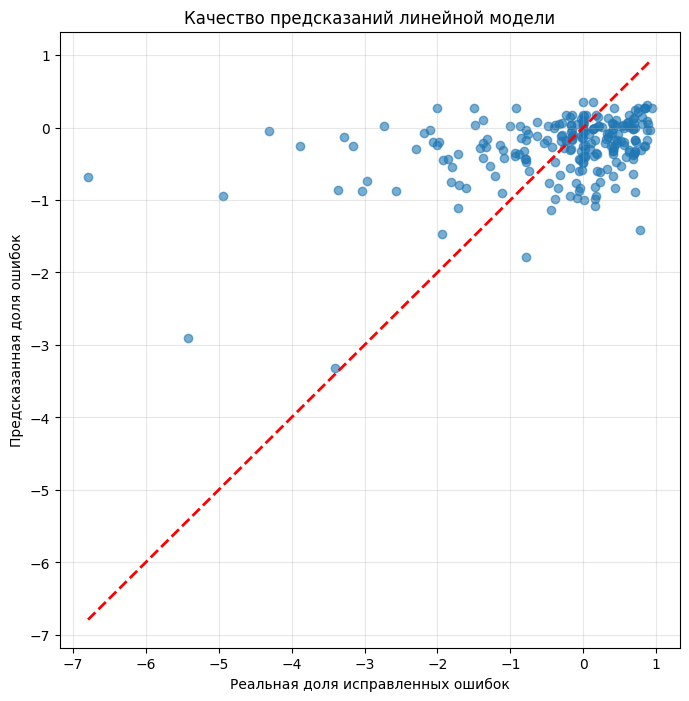

In [252]:
plt.figure(figsize=(8, 8))
plt.scatter(df_all_langs2_n['explained_mistakes'], df_all_langs2_n['pred'], alpha=0.6)
opop = df_all_langs2_n['explained_mistakes']
plt.plot([opop.min(), opop.max()], [opop.min(), opop.max()], 'r--', lw=2) # Идеальная линия
plt.xlabel('Реальная доля исправленных ошибок')
plt.ylabel('Предсказанная доля ошибок')
plt.title('Качество предсказаний линейной модели')
plt.grid(True, alpha=0.3)
plt.show()

In [253]:
for col, coef in zip(df_all_langs2_n.columns[1:-2], reg.coef_):
    print(f'{col}: {round(coef, 3)}')

ukr: 0.077
bel: 0.016
bg: -0.02
sb: -0.015
pol: -0.005
cz: -0.086
sk: -0.002
sn: 0.022
postfix_position: 0.067
different_agreement: -0.028
PREF1: -0.204
PREF2: -0.03
ROOT1: -0.088
ROOT2: 0.282
LINK: -0.444
SUFF1: -0.138
SUFF2: -0.118
SUFF3: 0.042
END: 0.038
POSTFIX: -0.085


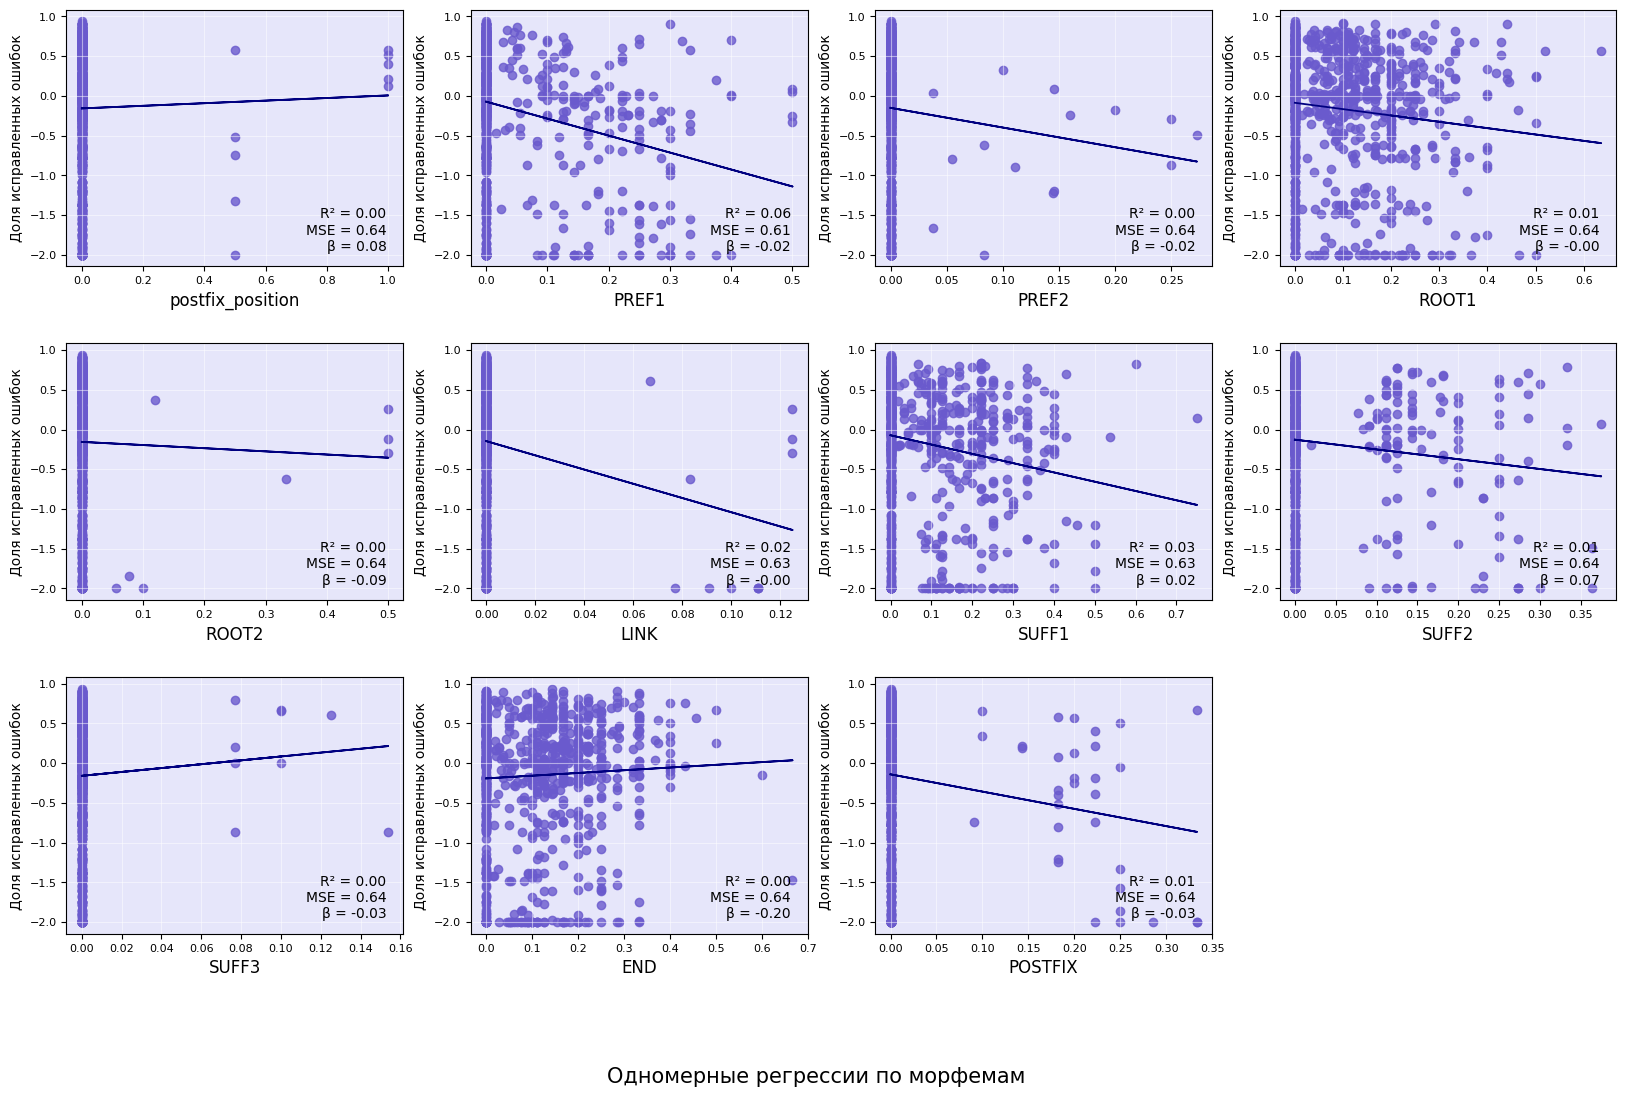

In [254]:
coef_dict = dict(zip(morpheme_cols, reg.coef_))  # или model.coef_[0] для Lasso

cols_for_plot = morpheme_cols + ['explained_mistakes']

plot_df = dff_all_langs2_n[cols_for_plot].copy()
good_cols = []
for col in morpheme_cols:
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    if len(set(x)) > 2:
        good_cols.append(col)

# Строим сетку только для них
n = len(good_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(good_cols):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    mask = plot_df[col].notna() & plot_df['explained_mistakes'].notna()
    x = plot_df.loc[mask, col]
    y = plot_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    b, m = polyfit(x, y, 1)
    y_pred = b + m * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    mse = np.mean((y - y_pred) ** 2)
    
    ax.scatter(x, y, alpha=0.8, color='slateblue')
    ax.plot(x, y_pred, '-', color='navy', lw=1.3)
    
    # Текст с R², MSE и коэффициентом из модели
    beta = coef_dict.get(col, 0)
    ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nβ = {beta:.2f}', 
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right')
    
    ax.grid(True, alpha=0.5, color='white')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Доля исправленных ошибок', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

# Скрываем оставшиеся пустые ячейки
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Название внизу с отступом
fig.suptitle('Одномерные регрессии по морфемам', fontsize=15, y=-0.001)

# Увеличиваем расстояние между рядами графиков
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

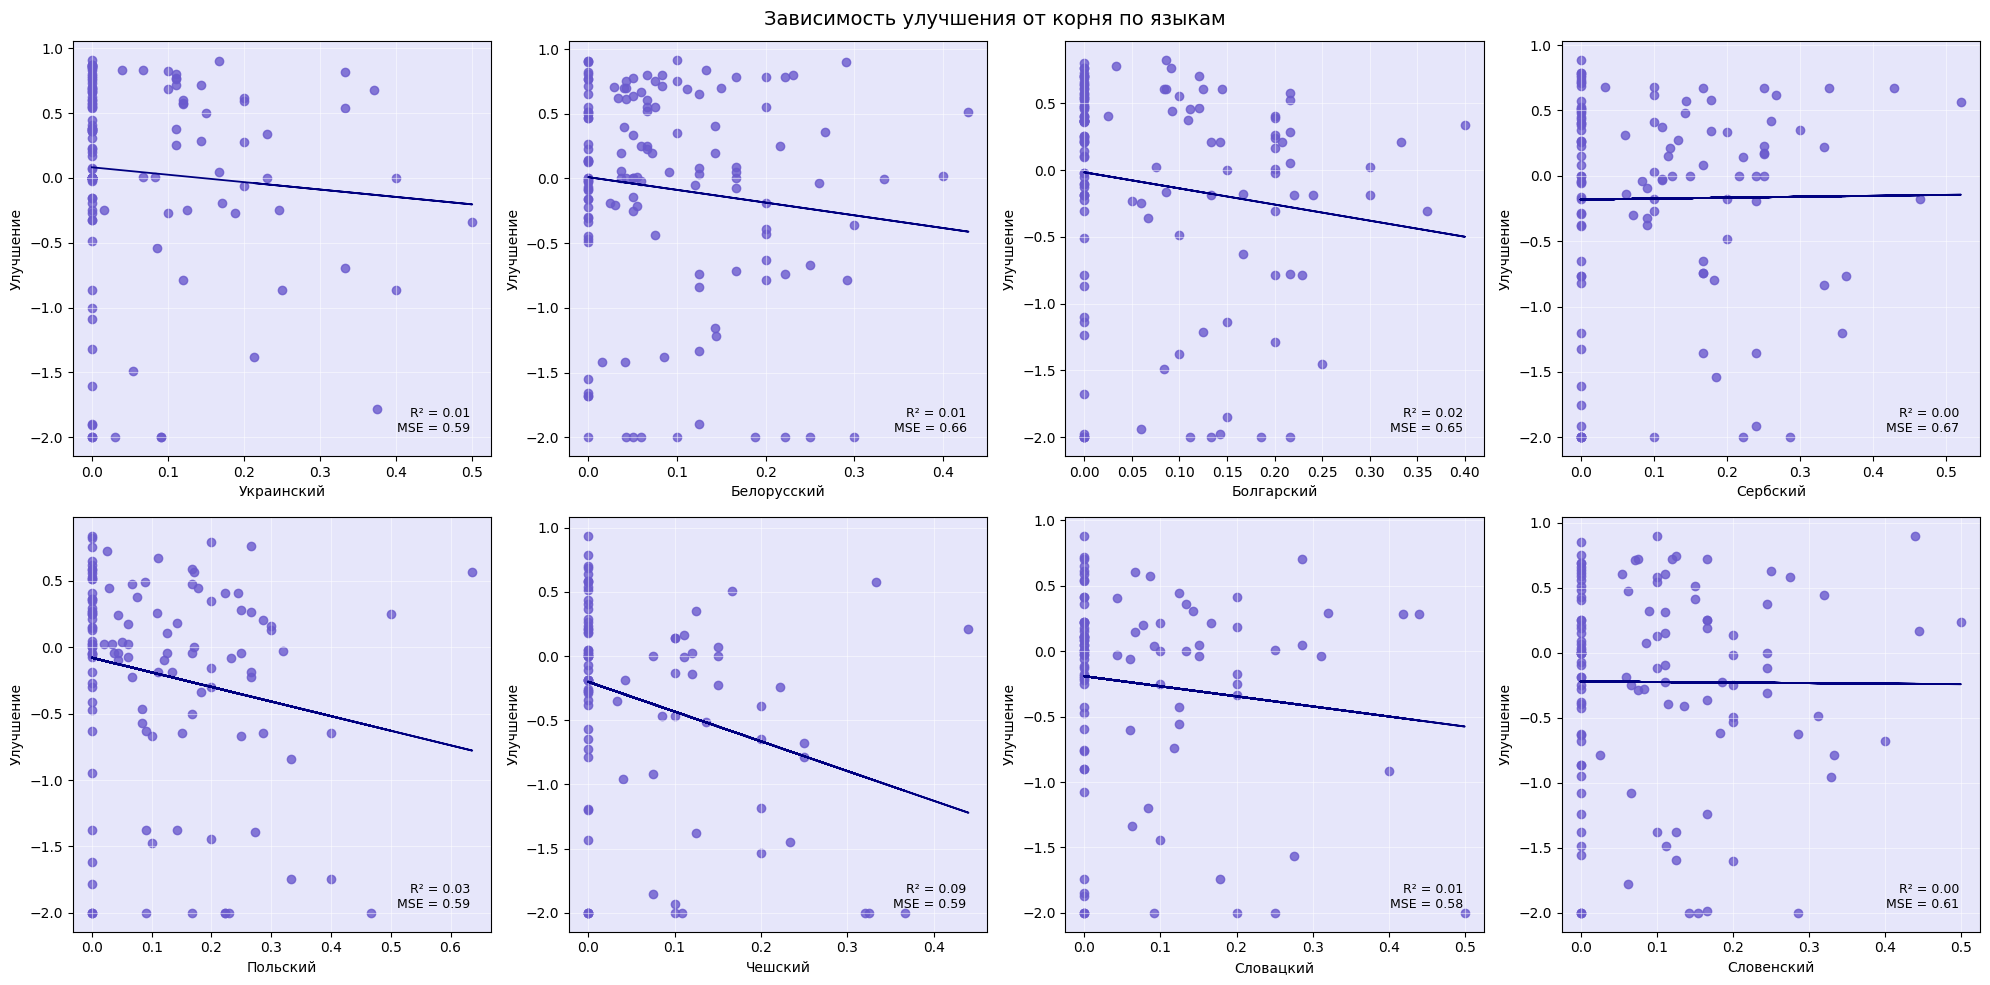

In [255]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'ROOT1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs2_n[cols_for_plot].copy()

for i, lang in enumerate(languages):
    ax = axes[i]
    ax.set_facecolor('lavender')
    
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        mse = np.mean((y - y_pred) ** 2)
        
        ax.scatter(x, y, alpha=0.8, color='slateblue')
        ax.plot(x, y_pred, '-', color='navy', lw=1.3)
        ax.text(0.95, 0.05, f'R² = {r2:.2f}\nMSE = {mse:.2f}', 
                transform=ax.transAxes, fontsize=9, va='bottom', ha='right')
    
    ax.set_xlabel(f'{lang_dict[lang]}')
    ax.set_ylabel('Улучшение')
    ax.grid(True, alpha=0.5, color='white')

plt.suptitle(f'Зависимость улучшения от корня по языкам', fontsize=14)
plt.tight_layout()
plt.show()

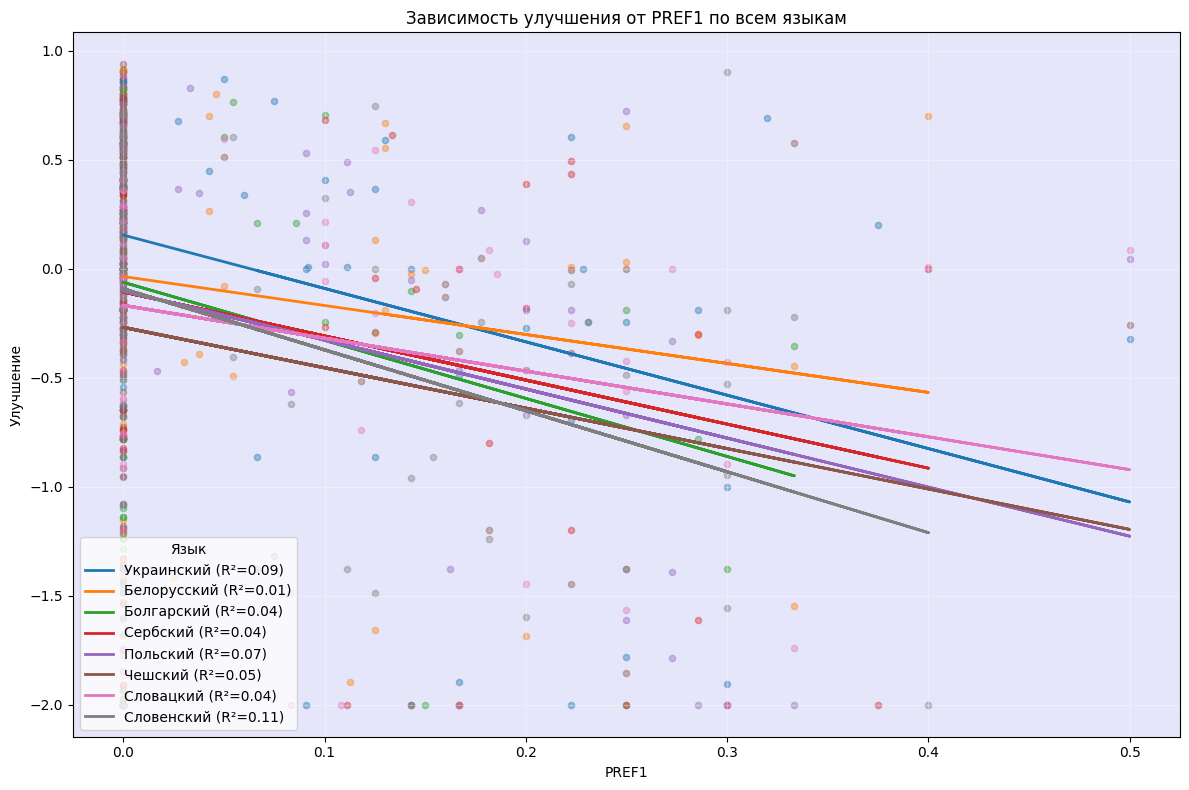

In [256]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('lavender')

languages = ['ukr', 'bel', 'bg', 'sb', 'pol', 'cz', 'sk', 'sn']
lang_dict = {'ukr': 'Украинский',
             'bel': 'Белорусский',
             'bg': 'Болгарский',
             'sb': 'Сербский',
             'pol': 'Польский',
             'cz': 'Чешский',
             'sk': 'Словацкий',
             'sn': 'Словенский'}
predictor = 'PREF1'

cols_for_plot = languages + morpheme_cols + ['explained_mistakes']
plot_df = dff_all_langs2_n[cols_for_plot].copy()

for lang, color in lang_colors.items():
    lang_df = plot_df[plot_df[lang] == 1.0]
    
    mask = lang_df[predictor].notna() & lang_df['explained_mistakes'].notna()
    x = lang_df.loc[mask, predictor]
    y = lang_df.loc[mask, 'explained_mistakes'].clip(lower=-2)
    
    if len(set(x)) > 2:
        b, m = polyfit(x, y, 1)
        y_pred = b + m * x
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        ax.scatter(x, y, alpha=0.4, color=color, s=20)
        ax.plot(x, y_pred, '-', color=color, lw=2, label=f'{lang_dict[lang]} (R²={r2:.2f})')

ax.set_xlabel(predictor)
ax.set_ylabel('Улучшение')
ax.legend(title='Язык', loc='lower left')
ax.grid(True, alpha=0.3, color='white')
plt.title(f'Зависимость улучшения от {predictor} по всем языкам')
plt.tight_layout()
plt.show()